In [1]:
import sys
import os

print(sys.executable)
print(os.getcwd())

C:\Users\andre\anaconda3\envs\bpu_attempt3\python.exe
C:\Users\andre\OneDrive\Desktop\Project_Folder_AT\unmodified_code_for_paper_before_github_v1_2026_02_12\src


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import random
import math
import gseapy as gp
import os
import re
import xlsxwriter
import statsmodels.api as sm
import time
import warnings
import statistics
import scipy.cluster.hierarchy as sch
import umap.umap_ as umap
import GEOparse
import openpyxl

from lifelines import KaplanMeierFitter
from lifelines.utils import median_survival_times
from lifelines.statistics import pairwise_logrank_test
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
from adjustText import adjust_text
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import MinMaxScaler
from matplotlib_venn import venn2
from matplotlib_venn import venn3
from sklearn.decomposition import PCA
from lifelines import CoxPHFitter
from lifelines.utils import k_fold_cross_validation
from lifelines.statistics import proportional_hazard_test
from joblib import Parallel, delayed
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from GEOparse.GEOTypes import GSE
import pickle
import gseapy
from gseapy import barplot
import PyComplexHeatmap
from PyComplexHeatmap import *
from scipy.stats import fisher_exact

In [3]:
plt.rcParams['svg.fonttype'] = 'none' #Need this for higher quality figures

# Probe --> Ensembl and Ensembl --> HGNC Mappings 
Our lab's bulkseq experiments are already mapped to ENSG IDs

AMLCG Cohort Data is done on Microarrays and will need to be mapped to ENSG IDs

ENSG IDs will be mapped to human readable HGNC nomenclature for the creation of figures and purposes of more human readable gene names

For averaging probe expression values, many to one mappings will be perimtted (not just 1:1)

Mapping info is retreived from BioMart and converted to dict

In [4]:
def one_to_one_gene_dict(df,key_column,value_column):
    df = df.loc[:,[key_column,value_column]]
    df=df.drop_duplicates()
    df = df.dropna()
    key_column_unique = df[key_column].value_counts() == 1
    value_column_unique = df[value_column].value_counts() == 1
    df_filtered = df[df[key_column].map(key_column_unique) & df[value_column].map(value_column_unique)]
    return dict(zip(df_filtered[key_column], df_filtered[value_column]))

#many probes to one gene, provided each probe only maps to one gene
def many_to_one_gene_dict(df,key_column,value_column):
    df = df.loc[:,[key_column,value_column]]
    df=df.drop_duplicates()
    df = df.dropna()
    key_column_unique = df[key_column].value_counts() == 1
    df_filtered = df[df[key_column].map(key_column_unique)]
    return dict(zip(df_filtered[key_column], df_filtered[value_column]))

In [5]:
#create gene mapping dicts
df = pd.read_csv(r'..\data\biomart_gene_annotations\biomart_export.txt',delimiter = '\t')
ensembl_to_hgnc_dict = one_to_one_gene_dict(df,'Gene stable ID','HGNC symbol')

df = pd.read_csv(r'..\data\biomart_gene_annotations\u133a2_to_ensg.txt',delimiter = '\t')
u133a_to_ensembl_dict = many_to_one_gene_dict(df,'AFFY HG U133A 2 probe','Gene stable ID')

df = pd.read_csv(r'..\data\biomart_gene_annotations\u133b_to_ensg.txt',delimiter = '\t')
u133b_to_ensembl_dict = many_to_one_gene_dict(df,'AFFY HG U133B probe','Gene stable ID')

df = pd.read_csv(r'..\data\biomart_gene_annotations\u133plus2_to_ensg.txt',delimiter = '\t')
u133plus2_to_ensembl_dict = many_to_one_gene_dict(df,'AFFY HG U133 Plus 2 probe','Gene stable ID')

In [6]:
# use this for human readable gene name in any capacity regardless of uniqueness, it will just pick a synonym
df = pd.read_csv(r'..\data\biomart_gene_annotations\biomart_export.txt',delimiter = '\t')
df = df[['Gene stable ID','HGNC symbol']]
df = df.dropna()
df = df.drop_duplicates()
ensembl_to_hgnc_non_unique_dict= dict(zip(df['Gene stable ID'],df['HGNC symbol']))

# Importing and cleaning cohort data for Cox Proportional Hazards Regression
Different cohort datasets will be 1) imported 2) cleaned and filtered 3) stored in cox_fit_ready_dict

In [7]:
cox_fit_ready_df_dict={} #this where we will store everything that's cleaned prior to fitting/ regression

## Importing and Preparing AMLCG1999 Cohort (GSE37642) for cox ph

In [8]:
#Getting Metdata from SOFT files found at GSE37642 accession
#We're going to label the 3v FAB subclass as M3 for simplicity, they are both instances of M3/ APL with t(15;17)

soft_file_path = r'..\data\cohort_data\amlcg\GSE37642_family.soft'
gse = GEOparse.get_GEO(filepath=soft_file_path)

metadata = []
for gsm_name, gsm in gse.gsms.items():
    # Extract all metadata for each sample
    sample_metadata = gsm.metadata
    metadata.append(sample_metadata)

df = pd.DataFrame(metadata)
df = df[['title','geo_accession','characteristics_ch1']]
df.iloc[:,0:2] = df.iloc[:,0:2].map(lambda x : x[0])
df['tissue'] = df['characteristics_ch1'].apply(lambda x: x[0].split(':')[1] if len(x) > 0 else None)
df['FAB'] = df['characteristics_ch1'].apply(lambda x: x[1].split(':')[1] if len(x) > 1 else None)
df['age'] = df['characteristics_ch1'].apply(lambda x: x[2].split(':')[1] if len(x) > 2 else None)
df['age'] = pd.to_numeric(df['age'],errors = 'coerce')
df['FAB'] = df['FAB'].apply(lambda x:x.strip()) #remove whitespace
df['FAB'] = df['FAB'].astype(str) 
df = df.drop(columns = 'characteristics_ch1')
gse37642_accession_to_patient_dict = dict(zip(df['geo_accession'],df['title'])) #sometimes different accession numbers point to the same patient, storing info

df = df.drop(columns = 'geo_accession')
df = df.drop_duplicates()
df = df.rename(columns = {'title':'patient_id'})

metadata_df = df.copy()
display(metadata_df)

25-Feb-2026 19:12:09 INFO GEOparse - Parsing ..\data\cohort_data\amlcg\GSE37642_family.soft: 
25-Feb-2026 19:12:09 DEBUG GEOparse - DATABASE: GeoMiame
25-Feb-2026 19:12:09 DEBUG GEOparse - SERIES: GSE37642
25-Feb-2026 19:12:09 DEBUG GEOparse - PLATFORM: GPL96
25-Feb-2026 19:12:10 DEBUG GEOparse - PLATFORM: GPL97
25-Feb-2026 19:12:10 DEBUG GEOparse - PLATFORM: GPL570
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
25-Feb-2026 19:12:12 DEBUG GEOparse - SAMPLE: GSM923596
25-Feb-2026 19:12:12 DEBUG GEOparse - SAMPLE: GSM923597
25-Feb-2026 19:12:12 DEBUG GEOparse - SAMPLE: GSM923598
25-Feb-2026 19:12:12 DEBUG GEOparse - SAMPLE: GSM923599
25-Feb-2026 19:12:12 DEBUG GEOparse - SAMPLE: GSM923600
25-Feb-2026 19:12:12 DEBUG GEOparse - SAMPLE: GSM923601
25-Feb-2026 19:12:12 DEBUG GEOparse - SAMPLE: GS

,patient_id,tissue,FAB,age
0,AML_patient_1,bone marrow mononuclear cells,1,67
1,AML_patient_2,bone marrow mononuclear cells,1,45
2,AML_patient_3,bone marrow mononuclear cells,1,51
3,AML_patient_4,bone marrow mononuclear cells,1,42
4,AML_patient_5,bone marrow mononuclear cells,1,56
...,...,...,...,...
979,AML_patient_558,bone marrow mononuclear cells,1,43
980,AML_patient_559,bone marrow mononuclear cells,2,23
981,AML_patient_560,bone marrow mononuclear cells,1,33
982,AML_patient_561,bone marrow mononuclear cells,0,61


In [9]:
#Getting survival data found at GEO 37642 accession page, named -> "GSE37642_Survival_data.txt.gz"
df = pd.read_csv(r'..\data\cohort_data\amlcg\GSE37642_Survival_data.txt', delimiter='\t', encoding='ISO-8859-1')
df = df.rename(columns = {'overall survival (days)':'days','life status':'event'})
df['event'] = df['event'].apply(lambda x: 1 if x == 'dead' else 0 if x=='alive' else np.nan)
df = df.dropna() #drop the 9 patients missing survival info
df = df.rename(columns = {'SAMPLE\xa0':'SAMPLE'})
df = df.drop(columns = 'SAMPLE')
df = df.rename(columns = {'GEO_ID':'patient_id'})
surv_df = df.copy()
display(surv_df)

,patient_id,days,event
0,AML_patient_1,186.0,1.0
1,AML_patient_2,3537.0,0.0
2,AML_patient_3,123.0,1.0
3,AML_patient_4,3395.0,0.0
4,AML_patient_5,30.0,1.0
...,...,...,...
557,AML_patient_558,136.0,1.0
558,AML_patient_559,96.0,1.0
559,AML_patient_560,47.0,1.0
560,AML_patient_561,342.0,1.0


In [10]:
#getting probe measurment data from already preprocessed and RMA normalized probe expression deposited in GEO database
#some patients were sequenced on both GPL96 and 97, this is accounted for by merging probesets in next code cell

gpl96_gsms = {gsm_name: gsm for gsm_name, gsm in gse.gsms.items() if gsm.metadata['platform_id'][0] == 'GPL96'}
gse_gpl96 = GSE(name=gse.name, metadata=gse.metadata, gsms=gpl96_gsms, gpls={k: v for k, v in gse.gpls.items() if k == 'GPL96'})
pivoted_control_samples = gse_gpl96.pivot_samples('VALUE')
df = pivoted_control_samples.rename(index = u133a_to_ensembl_dict,errors= 'ignore')
df = df[df.index.str.startswith('ENSG')]
df =df.T
df.columns.name='ENSG'
df = df.rename(index =gse37642_accession_to_patient_dict)
df = df.groupby(df.columns, axis=1).mean() #average probes for the same ENSG
probe_data_133a_df = df.copy()
display(probe_data_133a_df.head(5))

gpl97_gsms = {gsm_name: gsm for gsm_name, gsm in gse.gsms.items() if gsm.metadata['platform_id'][0] == 'GPL97'}
gse_gpl97 = GSE(name=gse.name, metadata=gse.metadata, gsms=gpl97_gsms, gpls={k: v for k, v in gse.gpls.items() if k == 'GPL97'})
pivoted_control_samples = gse_gpl97.pivot_samples('VALUE')
df = pivoted_control_samples.rename(index = u133b_to_ensembl_dict,errors= 'ignore')
df = df[df.index.str.startswith('ENSG')]
df =df.T
df.columns.name='ENSG'
df = df.rename(index =gse37642_accession_to_patient_dict)
df = df.groupby(df.columns, axis=1).mean() #average probes for the same ENSG
probe_data_133b_df = df.copy()
display(probe_data_133b_df.head(5))

gpl570_gsms = {gsm_name: gsm for gsm_name, gsm in gse.gsms.items() if gsm.metadata['platform_id'][0] == 'GPL570'}
gse_gpl570 = GSE(name=gse.name, metadata=gse.metadata, gsms=gpl570_gsms, gpls={k: v for k, v in gse.gpls.items() if k == 'GPL570'})
pivoted_control_samples = gse_gpl570.pivot_samples('VALUE')
df = pivoted_control_samples.rename(index = u133plus2_to_ensembl_dict,errors= 'ignore')
df = df[df.index.str.startswith('ENSG')]
df =df.T
df.columns.name='ENSG'
df = df.rename(index =gse37642_accession_to_patient_dict)
df = df.groupby(df.columns, axis=1).mean() #average probes for the same ENSG
probe_data_133plus2_df = df.copy()
display(probe_data_133plus2_df.head(5))

C:\Users\andre\AppData\Local\Temp\ipykernel_764\1464506038.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df = df.groupby(df.columns, axis=1).mean() #average probes for the same ENSG


ENSG,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001084,ENSG00000001167,ENSG00000001461,...,ENSG00000291211,ENSG00000291237,ENSG00000291259,ENSG00000291283,ENSG00000293115,ENSG00000293226,ENSG00000293412,ENSG00000293434,ENSG00000293442,ENSG00000293478
name,,,,,,,,,,,,,,,,,,,,,
AML_patient_1,6.210,5.65,11.17,7.525,5.93,9.32,7.36,9.770,7.3125,5.875,...,6.01,9.4700,6.01,5.12,7.59,4.71,6.17,6.95,5.70,5.65
AML_patient_2,6.190,5.51,10.45,7.140,6.74,8.56,6.22,9.365,7.3375,5.955,...,5.94,8.1600,5.66,5.28,8.13,4.72,6.19,9.19,6.22,6.29
AML_patient_3,6.125,5.43,10.62,6.630,7.06,9.68,7.36,8.975,7.1000,5.810,...,5.47,9.2825,5.77,5.18,7.31,4.57,6.31,8.07,6.61,5.97
AML_patient_4,6.065,5.26,10.85,8.675,7.62,9.29,8.85,9.335,7.6625,5.905,...,5.59,7.9925,5.53,4.81,7.63,4.56,5.88,8.60,6.41,5.96
AML_patient_5,6.245,5.19,11.24,6.890,5.74,9.70,6.69,9.155,7.4525,6.035,...,5.52,8.6750,5.69,5.30,7.75,4.43,6.00,7.32,6.56,6.13


C:\Users\andre\AppData\Local\Temp\ipykernel_764\1464506038.py:24: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df = df.groupby(df.columns, axis=1).mean() #average probes for the same ENSG


ENSG,ENSG00000000457,ENSG00000001036,ENSG00000001167,ENSG00000001460,ENSG00000001461,ENSG00000001497,ENSG00000001626,ENSG00000001629,ENSG00000002745,ENSG00000002746,...,ENSG00000293377,ENSG00000293405,ENSG00000293434,ENSG00000293437,ENSG00000293447,ENSG00000293487,ENSG00000293489,ENSG00000293514,ENSG00000293516,ENSG00000293550
name,,,,,,,,,,,,,,,,,,,,,
AML_patient_1,4.54,8.77,5.615,6.450,6.725,6.84,4.21,6.796667,4.10,4.75,...,5.89,6.62,7.67,4.67,5.29,6.81,7.06,6.550000,3.80,7.89
AML_patient_2,5.01,9.28,5.760,6.625,7.215,7.30,4.11,7.060000,4.08,4.95,...,5.78,6.46,6.86,4.73,5.08,6.79,7.38,6.686667,3.98,8.00
AML_patient_3,4.26,9.96,5.665,6.435,7.450,7.28,3.75,7.140000,4.09,4.41,...,5.66,6.56,7.11,4.41,4.70,6.80,8.52,6.730000,4.00,7.82
AML_patient_4,5.57,9.34,6.010,6.705,8.585,7.18,4.00,7.616667,3.97,4.52,...,5.60,6.43,7.55,4.49,4.87,6.35,7.32,7.513333,4.20,7.83
AML_patient_5,4.86,9.07,6.160,6.530,8.175,7.34,4.18,7.546667,3.87,4.19,...,5.66,6.22,6.87,4.57,4.75,6.50,6.48,6.793333,4.23,7.85


C:\Users\andre\AppData\Local\Temp\ipykernel_764\1464506038.py:36: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df = df.groupby(df.columns, axis=1).mean() #average probes for the same ENSG


ENSG,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000293434,ENSG00000293437,ENSG00000293442,ENSG00000293447,ENSG00000293478,ENSG00000293487,ENSG00000293489,ENSG00000293514,ENSG00000293516,ENSG00000293550
name,,,,,,,,,,,,,,,,,,,,,
AML_patient_423,5.910,5.21,11.56,6.110000,5.46,11.62,6.61,9.45,9.290,6.815000,...,7.730,4.42,6.69,4.57,6.07,6.46,7.67,6.430000,4.25,8.00
AML_patient_424,6.060,5.56,11.04,7.206667,6.25,10.05,6.39,8.91,8.690,6.733333,...,7.835,4.34,6.01,4.69,6.57,6.71,8.98,6.733333,4.63,7.68
AML_patient_425,6.090,5.46,10.12,5.373333,5.99,7.19,6.06,8.86,8.925,7.361667,...,6.985,4.62,5.79,4.88,6.49,6.57,5.73,6.496667,4.17,7.80
AML_patient_426,6.310,5.36,10.91,6.916667,6.81,11.32,6.97,8.64,9.195,7.168333,...,8.020,4.36,6.68,4.41,6.52,6.22,6.59,7.333333,4.14,7.55
AML_patient_427,5.955,5.32,11.01,6.806667,7.03,12.03,8.55,9.91,8.845,6.775000,...,7.455,4.64,6.34,4.70,6.28,6.09,7.92,7.246667,4.38,7.90


### combining GPL96 (A) and GPL97 (B) Micorarray chips that were used in parallel to sequence the same patients
they are meant to be complementary, genes (ENSGS) that overlap are kept from A and not B. This will become be our "AMLCG Cohort1"

The probeset plus2 is fine as is. Patients sequenced on this probest will become our "AMLCG Cohort2" 

In [11]:
a = probe_data_133a_df.copy()
b = probe_data_133b_df.copy()
print(a.shape)
print(b.shape)

genes_to_remove_from_b = [x for x in probe_data_133b_df.columns if x in probe_data_133a_df.columns]
b = b.drop(columns =genes_to_remove_from_b)
print(b.shape)

probe_data_133a_and_133b_df = pd.concat(objs=[a,b],join ='inner',axis =1, verify_integrity=True)
display(probe_data_133a_and_133b_df)

(422, 11297)
(422, 9821)
(422, 6151)


ENSG,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001084,ENSG00000001167,ENSG00000001461,...,ENSG00000293375,ENSG00000293377,ENSG00000293405,ENSG00000293437,ENSG00000293447,ENSG00000293487,ENSG00000293489,ENSG00000293514,ENSG00000293516,ENSG00000293550
name,,,,,,,,,,,,,,,,,,,,,
AML_patient_1,6.210,5.65,11.17,7.525,5.93,9.32,7.36,9.770,7.3125,5.875,...,4.34,5.89,6.62,4.67,5.29,6.81,7.06,6.550000,3.80,7.89
AML_patient_2,6.190,5.51,10.45,7.140,6.74,8.56,6.22,9.365,7.3375,5.955,...,4.43,5.78,6.46,4.73,5.08,6.79,7.38,6.686667,3.98,8.00
AML_patient_3,6.125,5.43,10.62,6.630,7.06,9.68,7.36,8.975,7.1000,5.810,...,4.34,5.66,6.56,4.41,4.70,6.80,8.52,6.730000,4.00,7.82
AML_patient_4,6.065,5.26,10.85,8.675,7.62,9.29,8.85,9.335,7.6625,5.905,...,4.28,5.60,6.43,4.49,4.87,6.35,7.32,7.513333,4.20,7.83
AML_patient_5,6.245,5.19,11.24,6.890,5.74,9.70,6.69,9.155,7.4525,6.035,...,4.23,5.66,6.22,4.57,4.75,6.50,6.48,6.793333,4.23,7.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AML_patient_418,6.795,5.25,11.08,7.160,7.04,10.39,6.77,11.655,7.5125,5.935,...,4.33,5.41,6.29,4.30,4.82,6.51,7.22,6.603333,4.10,7.52
AML_patient_419,6.685,5.53,10.83,7.030,6.09,10.25,7.60,8.775,7.1225,6.065,...,4.48,5.57,6.13,4.36,4.68,6.45,6.59,7.120000,4.21,8.35
AML_patient_420,6.280,5.35,11.31,6.930,6.08,10.25,6.49,11.540,7.0800,5.880,...,4.32,5.78,6.30,4.55,4.72,6.54,7.17,6.606667,4.11,7.70


In [12]:
#storing fully cleaned data (and z-scored in following code) in dictionary for cox ph fitting
non_gene_covariates = ['Age']

for item in [['AMLCG Cohort 1',probe_data_133a_and_133b_df],['AMLCG Cohort 2',probe_data_133plus2_df]]:
    probe_df = item[1].copy()
    probe_df = (probe_df - probe_df.mean()) / probe_df.std() #z score normalize genes
    label = item[0]
    df = pd.merge(left = surv_df, right = probe_df,right_index=True,left_on='patient_id',how = 'inner')
    df = pd.merge(left = df, right = metadata_df,right_on='patient_id',left_on='patient_id',how = 'left')
    
    df = df.drop(columns = ['tissue'])
    df = df.set_index('patient_id')
    df = df[~df['FAB'].isin(['3', '3v'])]
    df = df.drop(columns = 'FAB')
    df = df.rename(columns = {'age':'Age'})
    df= df[df['days']>0]
    df = df[df['Age'] >= 18]

    #copying the cleaned 'df' twice with additional filters depending on instance for deposition in cox_fit_ready_df
    #univariate will just have each gene used as a covaraite
    #multivariate includes age as another covariate in addition to gene (WBC count not available)
    
    dict_df = df.copy()
    dict_df = dict_df.drop(columns = non_gene_covariates)
    cox_fit_ready_df_dict[f'{label} / Univariate'] = dict_df.copy()

    dict_df = df.copy()
    dict_df = dict_df.dropna(subset = non_gene_covariates)
    cox_fit_ready_df_dict[f'{label} / Multivariate'] = dict_df.copy()

## Importing and Preparing TCGA Cohort for cox ph (NEW)

The Metadata for the TCGA cohort will come from the "Supplemental Data from NEJM paper" Header at the following website https://gdc.cancer.gov/about-data/publications/laml_2012 (upated info) 

The Survival data for the TCGA cohort will come from the "clinical" header, since it's in days here (rather than months in 'clinical section')

Bulkseq was downloaded from GDC data portal

In [13]:
#Wrangle TCGA Metadata
df = pd.read_excel(r'..\data\cohort_data\tcga\TCGA_NEJM_clinical(updated).xlsx')
df = df.iloc[0:200] #getting rid of empty final row that gets read in 
df = df[['TCGA Patient ID','FAB','Age','WBC','Induction','Trnsplt','Molecular Classification']]
columns_to_convert = ['Age','WBC']
df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric, errors='coerce')
df['TCGA Patient ID'] = df['TCGA Patient ID'].astype(int)
df['TCGA Patient ID'] = df['TCGA Patient ID'].astype(str)
df['TCGA Patient ID'] = 'TCGA-AB-'+ df['TCGA Patient ID']
df = df.rename(columns = {'TCGA Patient ID':'Patient ID','Molecular Classification':'major_cytogenetics'})
metadata_df=df.copy()

#import survival data from another file, carefully annotating censorship info and removing any 0 values to be safe
df = pd.read_csv(r'..\data\cohort_data\tcga\TCGA_clinical_data_from_gdc.cancer.gov.tsv',delimiter = '\t')
df = df[['bcr_patient_barcode','days_to_death','days_to_last_followup']]
columns_to_convert = ['days_to_death', 'days_to_last_followup']
df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric, errors='coerce')
df =df[(df['days_to_death'] >0)|(df['days_to_last_followup']>0)] #any instance of days == 0 might be a misplaced NaN
df['event'] = df['days_to_death'].apply(lambda x: 1 if pd.notna(x) else 0)
df['days'] = df['days_to_death'].combine_first(df['days_to_last_followup']) #getting days (stored in different column depending on whether event recorded)
df = df.drop(columns=['days_to_death', 'days_to_last_followup'])
df = df.rename(columns = {'bcr_patient_barcode':'Patient ID'})
survival_df = df.copy()

#Do an outer merge
survival_and_metadata_df = pd.merge(left =survival_df, right =metadata_df,how = 'outer',on='Patient ID')

#adding additional metadata categories
survival_and_metadata_df.insert(loc=1,column = 'RNAseq Sample',value=np.nan) #to be filled in

display(survival_and_metadata_df)

C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\openpyxl\worksheet\_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,Patient ID,RNAseq Sample,event,days,FAB,Age,WBC,Induction,Trnsplt,major_cytogenetics
0,TCGA-AB-2802,NaN,1.0,365.0,M4,50.0,16.9,7+3,0,Normal Karyotype
1,TCGA-AB-2803,NaN,1.0,792.0,M3,61.0,1.0,7+3+ATRA,0,PML-RARA
2,TCGA-AB-2804,NaN,0.0,2556.0,M3,30.0,5.7,7+3+ATRA,"Auto, sib Allo",PML-RARA
3,TCGA-AB-2805,NaN,1.0,576.0,M0,77.0,92.0,7+3+3,0,Normal Karyotype
4,TCGA-AB-2806,NaN,1.0,944.0,M1,46.0,29.4,7+3+3+PSC,MUD,RUNX1-RUNX1T1
...,...,...,...,...,...,...,...,...,...,...
195,TCGA-AB-3007,NaN,0.0,1581.0,M3,35.0,1.5,7+3+ATRA,0,PML-RARA
196,TCGA-AB-3008,NaN,1.0,822.0,M1,22.0,1.2,7+3+3,"MUD, MUD",Normal Karyotype
197,TCGA-AB-3009,NaN,1.0,576.0,M4,23.0,27.1,7+3+3,"Auto, sib Allo",Normal Karyotype
198,TCGA-AB-3011,NaN,0.0,1885.0,M1,21.0,8.2,7+3+3,sib Allo,Normal Karyotype


In [14]:
filepath = r'..\data\cohort_data\tcga\gdc_sample_sheet.2024-04-30.tsv'
df= pd.read_csv(filepath,sep = '\t')
df = df.loc[:,['File Name','Sample ID']]
sample_id_dict = dict(zip(df['File Name'], df['Sample ID']))

#create bulk df
bulk_df =pd.DataFrame()
filepath = r'..\data\cohort_data\tcga\Bulk'
for root, dirs, files in os.walk(filepath):
    for filename in files:
        if filename.endswith('.tsv'):
            # Read the TSV file
            filepath = os.path.join(root, filename)
            df= pd.read_csv(filepath,sep = '\t',skiprows = 1)
            df = df.rename(columns = {'gene_id':'ensg'})
            df['ensg'] = df['ensg'].str.split('.').str[0]
            df = df.drop_duplicates(subset=['ensg'], keep=False, inplace=False)
            df=df[df['gene_type'] == 'protein_coding']
            df =df.loc[4:,['ensg','tpm_unstranded']]
            df = df.set_index(keys = 'ensg',drop = True)
            df.index.name = None
            df = df.rename(columns = {'tpm_unstranded':sample_id_dict[filename]})
            df = df.T
            df= df.reset_index()
            df=df.rename(columns ={'index':'sample'})
            bulk_df = pd.concat([bulk_df, df])
            
bulk_df = bulk_df.sort_values(by = 'sample')
bulk_df = bulk_df.reset_index(drop = True)
bulk_df = bulk_df.rename(columns ={'sample':'RNAseq Sample'})

cohort_genes_list = [x for x in bulk_df.columns if 'ENSG' in x]
bulk_df[cohort_genes_list] = bulk_df[cohort_genes_list].map(lambda x: np.log2(x + 1))
bulk_df[cohort_genes_list] = (bulk_df[cohort_genes_list] - bulk_df[cohort_genes_list].mean()) / bulk_df[cohort_genes_list].std() #standard (zscore) scale all genes

display(bulk_df)

,RNAseq Sample,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000288649,ENSG00000288654,ENSG00000288656,ENSG00000288658,ENSG00000288660,ENSG00000288661,ENSG00000288669,ENSG00000288671,ENSG00000288674,ENSG00000288675
0,TCGA-AB-2805-03A,-0.770334,1.318563,1.624695,0.707446,0.017128,1.261027,-0.782591,-0.503711,-0.767308,...,NaN,NaN,-0.236099,-0.503598,-0.964876,NaN,-0.014665,NaN,1.296470,0.014881
1,TCGA-AB-2806-03A,-0.667076,2.528070,0.980290,0.615450,2.110135,-1.195590,-1.003110,0.394113,0.679904,...,NaN,NaN,-0.019050,-0.682605,-0.640126,NaN,-0.774534,NaN,-0.670849,-0.066077
2,TCGA-AB-2808-03A,-0.331012,-0.440469,-0.028022,-0.091614,0.273833,0.408683,0.054656,0.504955,0.632840,...,NaN,NaN,-0.010973,1.164702,0.161378,NaN,0.539068,NaN,-0.656016,-1.009126
3,TCGA-AB-2810-03A,-0.690214,-0.440469,0.766924,-2.863796,-1.823921,-0.154242,-1.147619,0.052979,-1.167005,...,NaN,NaN,-0.484254,-0.218904,-0.964876,NaN,-0.774534,NaN,0.331941,0.450681
4,TCGA-AB-2811-03B,-0.534530,-0.440469,-1.640895,-2.766706,-3.345198,1.335241,-0.922678,0.168062,-1.979702,...,NaN,NaN,-0.769345,0.097944,-0.743425,NaN,-0.774534,NaN,-0.203247,-0.086210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,TCGA-AB-3007-03A,-0.709180,-0.440469,-0.211859,-0.041406,-0.220599,-1.717152,-0.121371,-0.630421,-1.074050,...,NaN,NaN,0.503193,-0.325807,0.777558,NaN,-0.774534,NaN,1.452607,-0.938144
147,TCGA-AB-3008-03A,0.204076,4.367077,-0.431309,0.214873,1.468646,-1.329287,0.216961,0.649128,1.271287,...,NaN,NaN,-0.992329,-0.509565,1.449615,NaN,-0.037490,NaN,-1.337234,1.357103
148,TCGA-AB-3009-03A,-0.332795,-0.440469,0.154332,1.203633,1.920228,-0.401199,-0.462161,0.255897,1.211500,...,NaN,NaN,0.449858,-0.450695,-0.083704,NaN,0.212615,NaN,1.835900,0.613476
149,TCGA-AB-3011-03A,-0.678238,-0.440469,0.217544,0.625961,0.682345,-0.959150,0.862352,0.665639,0.255077,...,NaN,NaN,1.721386,-0.682605,0.050077,NaN,2.581849,NaN,1.212754,2.200016


In [15]:
#mapping the patient IDs in the metadata/surv df to their bulk seq samples we are using
tcga_patient_to_sample_dict = dict(zip(bulk_df['RNAseq Sample'].apply(lambda s: '-'.join(s.split('-')[:-1])),bulk_df['RNAseq Sample']))
survival_and_metadata_df['RNAseq Sample'] = survival_and_metadata_df.apply(
    lambda row: tcga_patient_to_sample_dict.get(row['Patient ID'], row['RNAseq Sample']),
    axis=1)

In [16]:
combined_bulk_and_metadata_df = pd.merge(left = survival_and_metadata_df,right = bulk_df,how = 'right',right_on='RNAseq Sample',left_on='RNAseq Sample')
display(combined_bulk_and_metadata_df)

,Patient ID,RNAseq Sample,event,days,FAB,Age,WBC,Induction,Trnsplt,major_cytogenetics,...,ENSG00000288649,ENSG00000288654,ENSG00000288656,ENSG00000288658,ENSG00000288660,ENSG00000288661,ENSG00000288669,ENSG00000288671,ENSG00000288674,ENSG00000288675
0,TCGA-AB-2805,TCGA-AB-2805-03A,1.0,576.0,M0,77.0,92.0,7+3+3,0,Normal Karyotype,...,NaN,NaN,-0.236099,-0.503598,-0.964876,NaN,-0.014665,NaN,1.296470,0.014881
1,TCGA-AB-2806,TCGA-AB-2806-03A,1.0,944.0,M1,46.0,29.4,7+3+3+PSC,MUD,RUNX1-RUNX1T1,...,NaN,NaN,-0.019050,-0.682605,-0.640126,NaN,-0.774534,NaN,-0.670849,-0.066077
2,TCGA-AB-2808,TCGA-AB-2808-03A,0.0,2861.0,M2,23.0,32.4,7+3,"sib Allo, sib Allo",Intermediate Risk Cytogenetic Abnormality,...,NaN,NaN,-0.010973,1.164702,0.161378,NaN,0.539068,NaN,-0.656016,-1.009126
3,TCGA-AB-2810,TCGA-AB-2810-03A,1.0,31.0,M2,76.0,61.6,no treatment,0,N.D.,...,NaN,NaN,-0.484254,-0.218904,-0.964876,NaN,-0.774534,NaN,0.331941,0.450681
4,TCGA-AB-2811,TCGA-AB-2811-03B,1.0,243.0,M4,81.0,90.6,7+3,0,Normal Karyotype,...,NaN,NaN,-0.769345,0.097944,-0.743425,NaN,-0.774534,NaN,-0.203247,-0.086210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,TCGA-AB-3007,TCGA-AB-3007-03A,0.0,1581.0,M3,35.0,1.5,7+3+ATRA,0,PML-RARA,...,NaN,NaN,0.503193,-0.325807,0.777558,NaN,-0.774534,NaN,1.452607,-0.938144
147,TCGA-AB-3008,TCGA-AB-3008-03A,1.0,822.0,M1,22.0,1.2,7+3+3,"MUD, MUD",Normal Karyotype,...,NaN,NaN,-0.992329,-0.509565,1.449615,NaN,-0.037490,NaN,-1.337234,1.357103
148,TCGA-AB-3009,TCGA-AB-3009-03A,1.0,576.0,M4,23.0,27.1,7+3+3,"Auto, sib Allo",Normal Karyotype,...,NaN,NaN,0.449858,-0.450695,-0.083704,NaN,0.212615,NaN,1.835900,0.613476
149,TCGA-AB-3011,TCGA-AB-3011-03A,0.0,1885.0,M1,21.0,8.2,7+3+3,sib Allo,Normal Karyotype,...,NaN,NaN,1.721386,-0.682605,0.050077,NaN,2.581849,NaN,1.212754,2.200016


In [17]:
non_gene_covariates = ['Age','WBC']

df = combined_bulk_and_metadata_df.copy()

df= df[df['FAB']!='M3']
df= df[df['Age']>=18]
df= df[df['days']>0]
df= df[df['Induction']!='no treatment']
df= df[df['Trnsplt']==0]
df = df.set_index('RNAseq Sample',drop = True)

#making cox ph dfs
dict_df = df.copy()
dict_df = dict_df[['event','days'] + cohort_genes_list]
cox_fit_ready_df_dict['TCGA / Univariate']=dict_df

dict_df = df.copy()
dict_df= dict_df.dropna(subset = non_gene_covariates)
dict_df = dict_df[['event','days'] + non_gene_covariates + cohort_genes_list]
cox_fit_ready_df_dict['TCGA / Multivariate']=dict_df


In [18]:
combined_bulk_and_metadata_df = pd.merge(left = survival_and_metadata_df,right = bulk_df,how = 'right',right_on='RNAseq Sample',left_on='RNAseq Sample')
display(combined_bulk_and_metadata_df)

,Patient ID,RNAseq Sample,event,days,FAB,Age,WBC,Induction,Trnsplt,major_cytogenetics,...,ENSG00000288649,ENSG00000288654,ENSG00000288656,ENSG00000288658,ENSG00000288660,ENSG00000288661,ENSG00000288669,ENSG00000288671,ENSG00000288674,ENSG00000288675
0,TCGA-AB-2805,TCGA-AB-2805-03A,1.0,576.0,M0,77.0,92.0,7+3+3,0,Normal Karyotype,...,NaN,NaN,-0.236099,-0.503598,-0.964876,NaN,-0.014665,NaN,1.296470,0.014881
1,TCGA-AB-2806,TCGA-AB-2806-03A,1.0,944.0,M1,46.0,29.4,7+3+3+PSC,MUD,RUNX1-RUNX1T1,...,NaN,NaN,-0.019050,-0.682605,-0.640126,NaN,-0.774534,NaN,-0.670849,-0.066077
2,TCGA-AB-2808,TCGA-AB-2808-03A,0.0,2861.0,M2,23.0,32.4,7+3,"sib Allo, sib Allo",Intermediate Risk Cytogenetic Abnormality,...,NaN,NaN,-0.010973,1.164702,0.161378,NaN,0.539068,NaN,-0.656016,-1.009126
3,TCGA-AB-2810,TCGA-AB-2810-03A,1.0,31.0,M2,76.0,61.6,no treatment,0,N.D.,...,NaN,NaN,-0.484254,-0.218904,-0.964876,NaN,-0.774534,NaN,0.331941,0.450681
4,TCGA-AB-2811,TCGA-AB-2811-03B,1.0,243.0,M4,81.0,90.6,7+3,0,Normal Karyotype,...,NaN,NaN,-0.769345,0.097944,-0.743425,NaN,-0.774534,NaN,-0.203247,-0.086210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,TCGA-AB-3007,TCGA-AB-3007-03A,0.0,1581.0,M3,35.0,1.5,7+3+ATRA,0,PML-RARA,...,NaN,NaN,0.503193,-0.325807,0.777558,NaN,-0.774534,NaN,1.452607,-0.938144
147,TCGA-AB-3008,TCGA-AB-3008-03A,1.0,822.0,M1,22.0,1.2,7+3+3,"MUD, MUD",Normal Karyotype,...,NaN,NaN,-0.992329,-0.509565,1.449615,NaN,-0.037490,NaN,-1.337234,1.357103
148,TCGA-AB-3009,TCGA-AB-3009-03A,1.0,576.0,M4,23.0,27.1,7+3+3,"Auto, sib Allo",Normal Karyotype,...,NaN,NaN,0.449858,-0.450695,-0.083704,NaN,0.212615,NaN,1.835900,0.613476
149,TCGA-AB-3011,TCGA-AB-3011-03A,0.0,1885.0,M1,21.0,8.2,7+3+3,sib Allo,Normal Karyotype,...,NaN,NaN,1.721386,-0.682605,0.050077,NaN,2.581849,NaN,1.212754,2.200016


## Importing and Preparing Beat Cohort for cox ph (NEW)
metadata (survival info as well) from vizome 2.0 website

bulk data from GDC portal

In [19]:
#Wrangle BEAT Metadata, note here that early on we will filter to only keep patients with RNA seq samples, otherwise the
#patient data becomes very hard to keep track of after dropping DNA seq sample info
filepath = r'..\data\cohort_data\beat\beataml_wv1to4_clinical.xlsx'
df = pd.read_excel(filepath,sheet_name = 'summary')
df = df.dropna(subset = 'dbgap_rnaseq_sample')
df['event'] = df['vitalStatus'].apply(lambda x: 0 if x == 'Alive' else (np.nan if x == 'Unknown' else 1))
df['days'] = df['overallSurvival']
df =df.drop(columns =['vitalStatus','overallSurvival'] )
df =df[['dbgap_subject_id','dbgap_rnaseq_sample','event','days','fabBlastMorphology','ageAtDiagnosis','wbcCount','specimenType','isDenovo','cumulativeTreatmentTypes','consensusAMLFusions']]
df = df.rename(columns ={'dbgap_subject_id':'Patient ID',
                                                                     'dbgap_rnaseq_sample':'RNAseq Sample',
                                                                     'ageAtDiagnosis':'Age',
                                                                     'fabBlastMorphology':'FAB',
                                                                      'wbcCount':'WBC',
                                                                     'consensusAMLFusions':'major_cytogenetics'
                                                                     })
df['Patient ID'] = df['Patient ID'].astype(str)
columns_to_convert = ['Age','WBC']
df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric, errors='coerce')
df['isDenovo'] = df['isDenovo'].apply(lambda x: x if x in ['TRUE', 'FALSE'] else np.nan)

survival_and_metadata_df = df.copy()
display(survival_and_metadata_df)


,Patient ID,RNAseq Sample,event,days,FAB,Age,WBC,specimenType,isDenovo,cumulativeTreatmentTypes,major_cytogenetics
0,2398,BA2172R,NaN,0,NaN,NaN,NaN,Peripheral Blood,NaN,NaN,KMT2A_re
3,2553,BA2656R,NaN,0,NaN,NaN,NaN,Peripheral Blood,NaN,NaN,NaN
5,2713,BA3110R,1.0,121,NaN,51.0,NaN,Bone Marrow Aspirate,NaN,NaN,NaN
6,2820,BA3214R,NaN,0,NaN,NaN,NaN,Bone Marrow Aspirate,NaN,NaN,NaN
7,2831,BA3141R,NaN,0,NaN,NaN,21.70,Bone Marrow Aspirate,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
934,2620,BA3208R,1.0,84,M1,70.0,27.26,Bone Marrow Aspirate,FALSE,Standard Chemotherapy,NaN
935,2782,BA3325R,1.0,568,NaN,56.0,26.10,Peripheral Blood,FALSE,Standard Chemotherapy|Targeted Therapy - Other...,NaN
936,2697,BA3211R,1.0,76,M0,69.0,5.79,Bone Marrow Aspirate,FALSE,Standard Chemotherapy|Targeted Therapy - Other,NaN
937,2610,BA3130R,1.0,110,M2,61.0,69.09,Bone Marrow Aspirate,FALSE,Standard Chemotherapy|Bone Marrow Transplant,NaN


In [20]:
filepath = r'..\data\cohort_data\beat\gdc_sample_sheet.2024-05-28.tsv'
df= pd.read_csv(filepath,sep = '\t')
df = df.loc[:,['File Name','Sample ID']]
sample_id_dict = dict(zip(df['File Name'], df['Sample ID']))

#create bulk df
bulk_df =pd.DataFrame()
filepath = r'..\data\cohort_data\beat\Bulk'
for root, dirs, files in os.walk(filepath):
    for filename in files:
        if filename.endswith('.tsv'):
            # Read the TSV file
            filepath = os.path.join(root, filename)
            df= pd.read_csv(filepath,sep = '\t',skiprows = 1)
            df = df.rename(columns = {'gene_id':'ensg'})
            df['ensg'] = df['ensg'].str.split('.').str[0]
            df = df.drop_duplicates(subset=['ensg'], keep=False, inplace=False)
            df=df[df['gene_type'] == 'protein_coding']
            df =df.loc[4:,['ensg','tpm_unstranded']]
            df = df.set_index(keys = 'ensg',drop = True)
            df.index.name = None
            df = df.rename(columns = {'tpm_unstranded':sample_id_dict[filename]})
            df = df.T
            df= df.reset_index()
            df=df.rename(columns ={'index':'sample'})
            bulk_df = pd.concat([bulk_df, df])
            
bulk_df = bulk_df.sort_values(by = 'sample')
bulk_df = bulk_df.reset_index(drop = True)
bulk_df = bulk_df.rename(columns ={'sample':'RNAseq Sample'})

cohort_genes_list = [x for x in bulk_df.columns if 'ENSG' in x]
bulk_df[cohort_genes_list] = bulk_df[cohort_genes_list].map(lambda x: np.log2(x + 1))
bulk_df[cohort_genes_list] = (bulk_df[cohort_genes_list] - bulk_df[cohort_genes_list].mean()) / bulk_df[cohort_genes_list].std() #standard (zscore) scale all genes

display(bulk_df)

,RNAseq Sample,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000288649,ENSG00000288654,ENSG00000288656,ENSG00000288658,ENSG00000288660,ENSG00000288661,ENSG00000288669,ENSG00000288671,ENSG00000288674,ENSG00000288675
0,BA2000R,-0.674625,-0.150376,1.116388,1.380419,2.416742,0.530132,-0.285629,0.873761,1.433146,...,NaN,NaN,-0.861967,1.317934,1.499631,NaN,-0.483425,NaN,1.454420,0.716059
1,BA2003R,0.765745,-0.150376,0.709219,-0.057326,-0.492788,-0.261108,1.235558,0.011427,-1.874582,...,NaN,NaN,-0.090537,0.695712,0.364053,NaN,-0.483425,NaN,-1.186133,0.379399
2,BA2004R,0.017113,-0.150376,-0.520405,0.911894,0.045185,0.901665,0.411980,-1.015282,-0.350790,...,NaN,NaN,0.999628,-0.589035,3.651517,NaN,1.396497,NaN,-0.447243,-1.403353
3,BA2006R,-0.551224,-0.150376,-3.386212,-3.462469,-3.046201,0.177616,-0.894510,-2.877723,-4.050364,...,NaN,NaN,-0.861967,-0.622571,-0.922171,NaN,-0.483425,NaN,-1.940489,-1.886891
4,BA2011R,0.720638,-0.150376,0.372779,-0.507599,-0.948228,0.868387,0.067202,0.022119,-1.213533,...,NaN,NaN,0.647474,-0.183571,2.301753,NaN,-0.483425,NaN,0.011757,-0.553943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,BA3450R,0.333866,-0.150376,1.019023,-1.566271,-0.645426,-0.454208,-0.681043,-0.213692,-0.582498,...,NaN,NaN,1.886924,-0.659805,0.061611,NaN,-0.483425,NaN,-0.604728,-0.337741
731,BA3451R,-0.571984,-0.150376,-0.109717,-0.239596,-0.166023,1.366616,-0.573737,1.437802,0.090127,...,NaN,NaN,-0.861967,-0.121509,-0.556868,NaN,-0.483425,NaN,1.155671,-0.614480
732,BA3452R,-0.654090,-0.150376,-0.155560,0.524263,-0.483598,0.239642,-0.655169,-1.231470,0.473932,...,NaN,NaN,0.272876,-0.411715,-0.563238,NaN,-0.483425,NaN,-0.205219,-0.890106
733,BA3453R,-0.463724,-0.150376,0.613100,-0.092034,-0.745065,-0.004093,-0.871858,0.356457,-0.325939,...,NaN,NaN,1.449329,1.389772,-0.922171,NaN,-0.483425,NaN,0.642907,-0.201350


In [21]:
combined_bulk_and_metadata_df = pd.merge(left = survival_and_metadata_df,right = bulk_df,how = 'right',right_on='RNAseq Sample',left_on='RNAseq Sample')
display(combined_bulk_and_metadata_df)

,Patient ID,RNAseq Sample,event,days,FAB,Age,WBC,specimenType,isDenovo,cumulativeTreatmentTypes,...,ENSG00000288649,ENSG00000288654,ENSG00000288656,ENSG00000288658,ENSG00000288660,ENSG00000288661,ENSG00000288669,ENSG00000288671,ENSG00000288674,ENSG00000288675
0,2304,BA2000R,1.0,633.0,NaN,24.0,NaN,Leukapheresis,TRUE,Standard Chemotherapy|Bone Marrow Transplant,...,NaN,NaN,-0.861967,1.317934,1.499631,NaN,-0.483425,NaN,1.454420,0.716059
1,2491,BA2003R,1.0,257.0,NaN,57.0,NaN,Peripheral Blood,FALSE,Standard Chemotherapy,...,NaN,NaN,-0.090537,0.695712,0.364053,NaN,-0.483425,NaN,-1.186133,0.379399
2,2136,BA2004R,1.0,341.0,M2,77.0,8.29,Peripheral Blood,FALSE,Standard Chemotherapy,...,NaN,NaN,0.999628,-0.589035,3.651517,NaN,1.396497,NaN,-0.447243,-1.403353
3,2020,BA2006R,1.0,37.0,NaN,78.0,51.64,Peripheral Blood,TRUE,NaN,...,NaN,NaN,-0.861967,-0.622571,-0.922171,NaN,-0.483425,NaN,-1.940489,-1.886891
4,2280,BA2011R,0.0,306.0,NaN,63.0,NaN,Peripheral Blood,TRUE,Standard Chemotherapy|Bone Marrow Transplant,...,NaN,NaN,0.647474,-0.183571,2.301753,NaN,-0.483425,NaN,0.011757,-0.553943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,2627,BA3450R,1.0,22.0,NaN,68.0,NaN,Bone Marrow Aspirate,FALSE,NaN,...,NaN,NaN,1.886924,-0.659805,0.061611,NaN,-0.483425,NaN,-0.604728,-0.337741
731,2780,BA3451R,0.0,1181.0,M5,47.0,58.66,Bone Marrow Aspirate,TRUE,Standard Chemotherapy,...,NaN,NaN,-0.861967,-0.121509,-0.556868,NaN,-0.483425,NaN,1.155671,-0.614480
732,2835,BA3452R,0.0,2929.0,NaN,56.0,NaN,Peripheral Blood,FALSE,Standard Chemotherapy,...,NaN,NaN,0.272876,-0.411715,-0.563238,NaN,-0.483425,NaN,-0.205219,-0.890106
733,2764,BA3453R,0.0,19.0,NaN,76.0,44.40,Bone Marrow Aspirate,TRUE,Targeted Therapy - Kinase Inhibitor(s),...,NaN,NaN,1.449329,1.389772,-0.922171,NaN,-0.483425,NaN,0.642907,-0.201350


In [22]:
non_gene_covariates = ['Age','WBC']

df = combined_bulk_and_metadata_df.copy()

#If it's not EXPLICITLY labeled M3, above UMAP, PCA and clustering suggests it is indeed NOT M3, even if unlabelled
df= df[df['FAB']!='M3']
df= df[df['Age']>=18]
df= df[df['days']>0]
df = df[df['specimenType']!='Leukapheresis']
df= df[df['isDenovo']=='TRUE']
df = df.drop_duplicates(subset = 'Patient ID',keep = 'first') #there are one or two patients that had an extra sample (e.g. bm and blood)
df = df[df['cumulativeTreatmentTypes'].notna()]
df = df[
    df['cumulativeTreatmentTypes'].str.contains('Standard Chemotherapy') &  # Contains 'Standard Chemotherapy'
    ~df['cumulativeTreatmentTypes'].str.contains('Targeted') &              # Does not contain 'Targeted'
    ~df['cumulativeTreatmentTypes'].str.contains('Bone')                    # Does not contain 'Bone'
]

df = df.set_index('RNAseq Sample',drop = True)

#making univariate training dfs
dict_df = df.copy()
dict_df = dict_df[['event','days'] + cohort_genes_list]
cox_fit_ready_df_dict['Beat / Univariate']=dict_df


dict_df = df.copy()
dict_df = dict_df[['event','days'] + non_gene_covariates + cohort_genes_list]
dict_df = dict_df.dropna(subset = non_gene_covariates)
cox_fit_ready_df_dict['Beat / Multivariate']=dict_df



In [23]:
for key,value in cox_fit_ready_df_dict.items():
    print(key)
    print(value.shape)
    display(value.head(5))

AMLCG Cohort 1 / Univariate
(398, 17450)


,days,event,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001084,...,ENSG00000293375,ENSG00000293377,ENSG00000293405,ENSG00000293437,ENSG00000293447,ENSG00000293487,ENSG00000293489,ENSG00000293514,ENSG00000293516,ENSG00000293550
patient_id,,,,,,,,,,,,,,,,,,,,,
AML_patient_1,186.0,1.0,-0.142680,0.684828,0.536234,0.911718,-0.308551,-0.553358,0.593309,0.632978,...,0.234764,1.402609,0.231510,0.789547,3.016042,1.085646,-0.443920,-1.273458,-1.466533,0.244764
AML_patient_2,3537.0,0.0,-0.207843,0.086490,-0.788288,0.127148,0.976400,-1.101723,-0.661489,0.074055,...,0.714911,0.904757,-0.435365,1.144760,1.782055,0.996686,-0.046868,-0.774977,-0.631905,0.691557
AML_patient_3,123.0,1.0,-0.419623,-0.255418,-0.475553,-0.912153,1.484035,-0.293606,0.593309,-0.464167,...,0.234764,0.361645,-0.018568,-0.749705,-0.450875,1.041166,1.367631,-0.616922,-0.539168,-0.039559
AML_patient_4,3395.0,0.0,-0.615113,-0.981972,-0.052442,3.255239,2.372397,-0.575004,2.233352,0.032654,...,-0.085334,0.090090,-0.560404,-0.276089,0.548067,-0.960428,-0.121315,2.240227,0.388197,0.001059
AML_patient_5,30.0,1.0,-0.028644,-1.281141,0.665007,-0.382313,-0.609959,-0.279175,-0.144160,-0.215757,...,-0.352082,0.361645,-1.435678,0.197527,-0.157068,-0.293230,-1.163577,-0.385918,0.527302,0.082294


AMLCG Cohort 1 / Multivariate
(398, 17451)


,days,event,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001084,...,ENSG00000293377,ENSG00000293405,ENSG00000293437,ENSG00000293447,ENSG00000293487,ENSG00000293489,ENSG00000293514,ENSG00000293516,ENSG00000293550,Age
patient_id,,,,,,,,,,,,,,,,,,,,,
AML_patient_1,186.0,1.0,-0.142680,0.684828,0.536234,0.911718,-0.308551,-0.553358,0.593309,0.632978,...,1.402609,0.231510,0.789547,3.016042,1.085646,-0.443920,-1.273458,-1.466533,0.244764,67
AML_patient_2,3537.0,0.0,-0.207843,0.086490,-0.788288,0.127148,0.976400,-1.101723,-0.661489,0.074055,...,0.904757,-0.435365,1.144760,1.782055,0.996686,-0.046868,-0.774977,-0.631905,0.691557,45
AML_patient_3,123.0,1.0,-0.419623,-0.255418,-0.475553,-0.912153,1.484035,-0.293606,0.593309,-0.464167,...,0.361645,-0.018568,-0.749705,-0.450875,1.041166,1.367631,-0.616922,-0.539168,-0.039559,51
AML_patient_4,3395.0,0.0,-0.615113,-0.981972,-0.052442,3.255239,2.372397,-0.575004,2.233352,0.032654,...,0.090090,-0.560404,-0.276089,0.548067,-0.960428,-0.121315,2.240227,0.388197,0.001059,42
AML_patient_5,30.0,1.0,-0.028644,-1.281141,0.665007,-0.382313,-0.609959,-0.279175,-0.144160,-0.215757,...,0.361645,-1.435678,0.197527,-0.157068,-0.293230,-1.163577,-0.385918,0.527302,0.082294,56


AMLCG Cohort 2 / Univariate
(129, 17450)


...

,event,days,Age,WBC,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,...,ENSG00000288649,ENSG00000288654,ENSG00000288656,ENSG00000288658,ENSG00000288660,ENSG00000288661,ENSG00000288669,ENSG00000288671,ENSG00000288674,ENSG00000288675
RNAseq Sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AB-2805-03A,1.0,576.0,77.0,92.0,-0.770334,1.318563,1.624695,0.707446,0.017128,1.261027,...,NaN,NaN,-0.236099,-0.503598,-0.964876,NaN,-0.014665,NaN,1.296470,0.014881
TCGA-AB-2811-03B,1.0,243.0,81.0,90.6,-0.534530,-0.440469,-1.640895,-2.766706,-3.345198,1.335241,...,NaN,NaN,-0.769345,0.097944,-0.743425,NaN,-0.774534,NaN,-0.203247,-0.086210
TCGA-AB-2813-03A,1.0,31.0,78.0,9.9,-0.088932,-0.440469,-0.239651,-0.664168,-0.460514,1.353981,...,NaN,NaN,0.478501,-0.539505,0.485885,NaN,1.586377,NaN,-0.694847,-1.114877
TCGA-AB-2818-03A,1.0,303.0,62.0,75.2,-0.417301,-0.440469,0.413062,0.903770,-0.057288,1.288779,...,NaN,NaN,4.862811,4.464612,0.056952,NaN,0.775989,NaN,1.513577,-0.022247
TCGA-AB-2819-03A,0.0,2496.0,52.0,4.1,-0.063046,0.947680,2.190963,-0.950198,0.363541,-1.410923,...,NaN,NaN,-0.396913,-0.682605,-0.401780,NaN,0.407237,NaN,-1.121538,0.209409


Beat / Univariate
(141, 19928)


,event,days,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000288649,ENSG00000288654,ENSG00000288656,ENSG00000288658,ENSG00000288660,ENSG00000288661,ENSG00000288669,ENSG00000288671,ENSG00000288674,ENSG00000288675
RNAseq Sample,,,,,,,,,,,,,,,,,,,,,
BA2024R,1.0,33.0,-0.520505,1.909277,-1.081121,-0.334983,-0.899602,1.166071,-0.737239,-1.038131,...,NaN,NaN,-0.861967,-0.374482,3.172424,NaN,-0.483425,NaN,-0.140173,-0.085734
BA2036R,1.0,21.0,-0.275226,-0.150376,0.196380,1.215324,1.479265,-0.344585,0.285616,0.911052,...,NaN,NaN,0.845279,0.645906,-0.922171,NaN,-0.483425,NaN,1.017175,2.090962
BA2046R,0.0,496.0,1.119061,-0.150376,0.164942,-1.082992,-1.679466,-2.120914,-0.651233,-2.100678,...,NaN,NaN,-0.325684,-0.659805,0.012754,NaN,-0.483425,NaN,0.659120,-0.079705
BA2053R,0.0,595.0,-0.684821,-0.150376,0.822551,-1.481538,-1.295800,-0.330245,-0.892116,-0.566498,...,NaN,NaN,-0.861967,-0.428260,-0.922171,NaN,-0.483425,NaN,-0.464778,-1.197171
BA2055R,1.0,1287.0,-0.710352,-0.150376,-5.552873,-3.067554,-2.632013,-0.066888,-1.070367,-2.792420,...,NaN,NaN,-0.861967,-0.659805,-0.699114,NaN,-0.483425,NaN,-1.969225,-0.566072


Beat / Multivariate
(121, 19930)


,event,days,Age,WBC,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,...,ENSG00000288649,ENSG00000288654,ENSG00000288656,ENSG00000288658,ENSG00000288660,ENSG00000288661,ENSG00000288669,ENSG00000288671,ENSG00000288674,ENSG00000288675
RNAseq Sample,,,,,,,,,,,,,,,,,,,,,
BA2024R,1.0,33.0,48.0,6.30,-0.520505,1.909277,-1.081121,-0.334983,-0.899602,1.166071,...,NaN,NaN,-0.861967,-0.374482,3.172424,NaN,-0.483425,NaN,-0.140173,-0.085734
BA2046R,0.0,496.0,61.0,1.39,1.119061,-0.150376,0.164942,-1.082992,-1.679466,-2.120914,...,NaN,NaN,-0.325684,-0.659805,0.012754,NaN,-0.483425,NaN,0.659120,-0.079705
BA2053R,0.0,595.0,31.0,41.35,-0.684821,-0.150376,0.822551,-1.481538,-1.295800,-0.330245,...,NaN,NaN,-0.861967,-0.428260,-0.922171,NaN,-0.483425,NaN,-0.464778,-1.197171
BA2055R,1.0,1287.0,65.0,20.70,-0.710352,-0.150376,-5.552873,-3.067554,-2.632013,-0.066888,...,NaN,NaN,-0.861967,-0.659805,-0.699114,NaN,-0.483425,NaN,-1.969225,-0.566072
BA2068R,0.0,1112.0,64.0,1.50,-0.735595,-0.150376,1.018525,0.199463,1.709344,-2.054027,...,NaN,NaN,0.034171,4.695675,-0.371815,NaN,0.863943,NaN,0.965755,-0.005688


In [24]:
for key,df in cox_fit_ready_df_dict.items():
    for meta_col in ['event','days','Age','WBC']:
        if meta_col in df.columns:
            if df[meta_col].isna().any():
                print(key, meta_col)

## Cox PH Fitting

In [25]:
def process_gene_univariate(gene, cox_fit_ready_df):
    cph = CoxPHFitter()
    df = cox_fit_ready_df[['event', 'days', gene]]
    
    with warnings.catch_warnings(record=True) as w_fit:
        warnings.simplefilter("always")
        warnings.filterwarnings("ignore", message='datetime.datetime.utcnow()')
        
        try:
            if df[gene].isna().sum() > 0 or df[gene].var() < 0.0001:
                results_df = pd.DataFrame({
                    'exp(coef)': [np.nan], 
                    'p': [np.nan],
                    'cox_ph_fit': 'skipped (low variance)'
                }, index=[gene])
            
            else:
                cph.fit(df, duration_col='days', event_col='event')
                results_df = cph.summary
                results_df['cox_ph_fit'] = 'passed'
                results_df['concordance_index_'] = cph.concordance_index_              
                    
            if len(w_fit) > 0:
                results_df['cox_ph_fit'] = 'warning'
                results_df['cox_ph_fit_warning'] = '; '.join([str(warning.message) for warning in w_fit])
        
        except Exception as e_fit:
            results_df = pd.DataFrame({
                'exp(coef)': [np.nan], 
                'p': [np.nan],
                'cox_ph_fit': 'error',
                'cox_ph_fit_error': [str(e_fit)]
            }, index=[gene])
    return gene, results_df


def process_gene_multivariate(gene, cox_fit_ready_df):
    non_gene_covariates = [x for x in cox_fit_ready_df.columns if x in ['Age','WBC']]
    print(non_gene_covariates)
    cph = CoxPHFitter()
    df = cox_fit_ready_df[['event', 'days', gene] + non_gene_covariates]

    with warnings.catch_warnings(record=True) as w_fit:
        warnings.simplefilter("always")
        warnings.filterwarnings("ignore", message='datetime.datetime.utcnow()')
        
        try:
            if df[gene].isna().sum() > 0 or df[gene].var() < 0.0001:
                results_df = pd.DataFrame({
                    'exp(coef)': [np.nan], 
                    'p': [np.nan],
                    'cox_ph_fit': 'skipped (low variance)'
                }, index=[gene])
            
            else:
                cph.fit(df, duration_col='days', event_col='event')
                results_df = cph.summary
                results_df['cox_ph_fit'] = 'passed'
                results_df['concordance_index_'] = cph.concordance_index_
                
            if len(w_fit) > 0:
                results_df['cox_ph_fit'] = 'warning'
                results_df['cox_ph_fit_warning'] = '; '.join([str(warning.message) for warning in w_fit])
        
        except Exception as e_fit:
            results_df = pd.DataFrame({
                'exp(coef)': [np.nan], 
                'p': [np.nan],
                'cox_ph_fit': 'error',
                'cox_ph_fit_error': [str(e_fit)]
            }, index=[gene])
    return gene, results_df

In [26]:
'''
cox_ph_fit_dict = {}

keys = sorted(cox_fit_ready_df_dict.keys()) 

for key in keys:
    print(key)    
    df = cox_fit_ready_df_dict[key].copy()
    cohort_genes_list = [x for x in df.columns if 'ENSG' in x]
    print(len(cohort_genes_list))
    if '/ Univariate' in key:
        start_time = time.time()
        results = Parallel(n_jobs=-2, backend='loky')(delayed(process_gene_univariate)(gene, df) for gene in cohort_genes_list)
    elif '/ Multivariate' in key:
        start_time = time.time()
        results = Parallel(n_jobs=-2, backend='loky')(delayed(process_gene_multivariate)(gene, df) for gene in cohort_genes_list)

    results_df_dict = {}

    for returned_items in results:
        gene, results_df = returned_items
        results_df_dict[gene]= (results_df)

    combined_results_df = pd.concat(results_df_dict)
    
    cox_ph_fit_dict[key] = {}
    cox_ph_fit_dict[key]['combined_results_df'] = combined_results_df.copy()
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f'{round(elapsed_time,3)} seconds / {round((elapsed_time/60),3)} minutes')
    print('\n')
'''

AMLCG Cohort 1 / Multivariate
17448
357.219 seconds / 5.954 minutes


AMLCG Cohort 1 / Univariate
17448
310.578 seconds / 5.176 minutes


AMLCG Cohort 2 / Multivariate
17448
261.556 seconds / 4.359 minutes


AMLCG Cohort 2 / Univariate
17448
230.083 seconds / 3.835 minutes


Beat / Multivariate
19926
303.415 seconds / 5.057 minutes


Beat / Univariate
19926


KeyboardInterrupt: 

In [ ]:
'''
#storing results IMMEDIATELY AFTER computing
path = r'..\intermediate_file_outputs\cox_ph_fit_dict_raw.pkl'
with open(path, 'wb') as f:
    pickle.dump(cox_ph_fit_dict, f)

print(f"Dictionary saved to {path}")
'''

In [ ]:
'''
#creating 'single-index' results dfs in the dict without redundant double-indeces

for key in cox_ph_fit_dict.keys():
    if '/ Multivariate' in key:
        df = cox_ph_fit_dict[key]['combined_results_df'].copy()
        display(df.head(1))
        print(len(df))
        mask = df.index.get_level_values(0) == df.index.get_level_values(1)
        filtered_df = df[mask].reset_index(level=0, drop=True)
        display(filtered_df.head(1))
        print(len(filtered_df))
        cox_ph_fit_dict[key]['combined_results_df(single-index)'] = filtered_df.copy()

for key in cox_ph_fit_dict.keys():
    if '/ Univariate' in key:
        df = cox_ph_fit_dict[key]['combined_results_df'].copy()
        display(df.head(1))
        df_dropped = df.droplevel(0)
        display(df_dropped.head(1))
        cox_ph_fit_dict[key]['combined_results_df'] = df_dropped.copy()
        cox_ph_fit_dict[key]['combined_results_df(single-index)'] = cox_ph_fit_dict[key]['combined_results_df'].copy() #this is redundant, doing anyway for labeling consistency
'''

In [ ]:
'''
#adding FDR values after Benjamini-Hochberg correction
for key in cox_ph_fit_dict.keys():
    df = cox_ph_fit_dict[key]['combined_results_df(single-index)'].copy()
    print(f"{df['p'].isna().sum()} nans found in pvals for {key} - dropping them for FDR and reappending dropped rows as not tested")
    df=df.dropna(subset = 'p')
    
    pvals = df['p']   
    alpha = 0.05
    method = 'fdr_bh'
    
    reject_null_decision, pvals_corrected, _, _ = multipletests(pvals, alpha=alpha, method=method)   
    # Add the results to the DataFrame
    df['reject_null_decision'] = reject_null_decision
    df['pval_bh_corrected'] = pvals_corrected
    df['tested'] = True
    missing_genes_df = cox_ph_fit_dict[key]['combined_results_df(single-index)'].copy()
    missing_genes_df = missing_genes_df[~missing_genes_df.index.isin(df.index)]
    missing_genes_df['tested'] = False
    df = pd.concat([df,missing_genes_df])
    
    cox_ph_fit_dict[key]['combined_results_df(single-index)(fdr_corrected_all_genes)'] = df.copy()
'''

In [ ]:
'''
#restoring results after cleaning indeces and adding FDR
path = r'..\intermediate_file_outputs\cox_ph_fit_dict.pkl'
with open(path, 'wb') as f:
    pickle.dump(cox_ph_fit_dict, f)

print(f"Dictionary saved to {path}")
'''

In [27]:

#if you want to read back in pickle instead
path = r'..\intermediate_file_outputs\cox_ph_fit_dict.pkl'
with open(path, 'rb') as f:
    cox_ph_fit_dict = pickle.load(f)


# Read in Bulkseq data

In [29]:
#Read in drug data
bulk_de_tables_dict ={}
bulk_de_tables_dict['cytarabine'] = pd.read_csv(r'..\data\in_vitro_chemo_rna_seq\genelevel_DESeq_deg_CYT_unfiltered.csv')
bulk_de_tables_dict['vincristine'] = pd.read_csv(r'..\data\in_vitro_chemo_rna_seq\genelevel_DESeq_deg_VINC_unfiltered.csv')
bulk_de_tables_dict['venetoclax'] = pd.read_csv(r'..\data\in_vitro_chemo_rna_seq\genelevel_DESeq_deg_VEN_unfiltered.csv')
#rename the ext_gene column to 'names', drop Nan, names, and trim to keep relevant info
for key in bulk_de_tables_dict.keys():
    df = bulk_de_tables_dict[key].copy()
    df = df.drop_duplicates(subset = ['gid'],keep = False) #there are some duplicate genes (not alot though)
    df = df.loc[:,['gid','log2FoldChange','pvalue','padj']] 
    df.rename(inplace = True, columns = {'gid':'ensg','log2FoldChange':'l2fc','pvalue':'p','padj':'pval_bh_corrected'})
    df = df.loc[:,['ensg','l2fc','p','pval_bh_corrected']]
    df.set_index(keys= 'ensg',inplace = True,drop = True)
    bulk_de_tables_dict[key] = df.copy()

## Analysis of Drug Data and Cohorts seperately, will look at overlap later

In [30]:
import logging
#some enrichr API calls can fail, setting this up just in case
logging.basicConfig(
    filename=r'..\results\poor_prog_upreg.log',  
    filemode='w',
    level=logging.ERROR,
    format ='%(asctime)s - %(levelname)s - %(message)s',
    force=True
)

### Supplemental Figure 1 (Drugs) : volcano plot + venn diagram and intersection + GO Analysis

#### Volcano Plots

9851  de genes


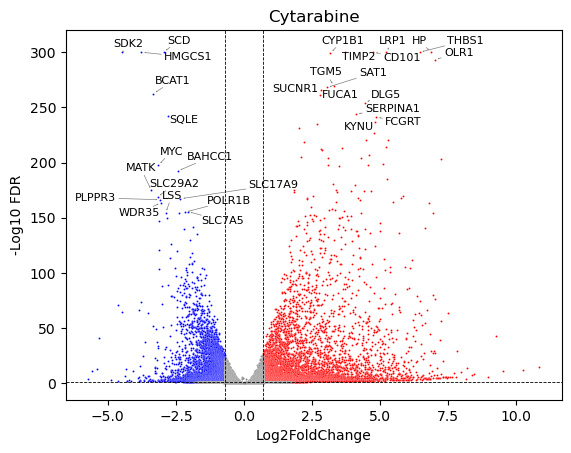

1510  de genes


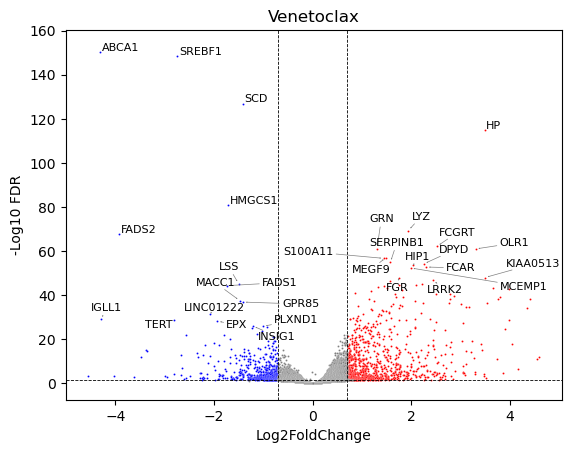

1182  de genes


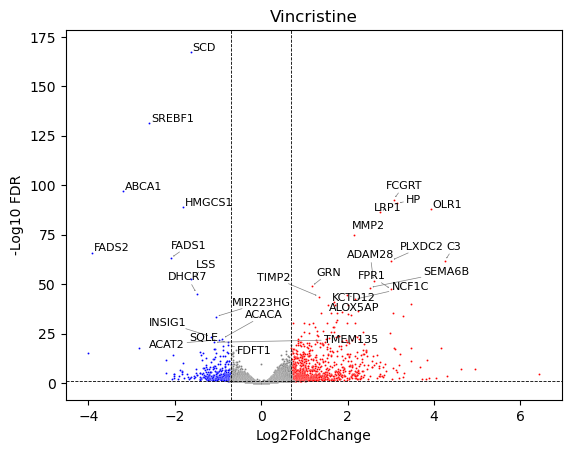

In [31]:
for drug in ['cytarabine','venetoclax','vincristine']:
    df = bulk_de_tables_dict[drug].copy()
    df['-log10pval_bh_corrected'] = df['pval_bh_corrected'].apply(lambda x: -np.log10(x+1e-300))
    df['hgnc'] = df.index
    df['hgnc'] = df['hgnc'].apply(lambda x: ensembl_to_hgnc_non_unique_dict.get(x,x))
    max_y_value = df['-log10pval_bh_corrected'].max()

    df_pos = df.copy()
    df_pos = df_pos[(df_pos['l2fc']>.7)&(df_pos['pval_bh_corrected']<.05)]
    df_neg = df.copy()
    df_neg = df_neg[(df_neg['l2fc']<-.7)&(df_neg['pval_bh_corrected']<.05)]
    df_not_de = df.copy()
    df_not_de = df_not_de[(df_not_de['l2fc'].abs()<.7)|~(df_not_de['pval_bh_corrected']<.05)]
    df_de = df.copy()
    df_de = df_de[(df_de['l2fc'].abs()>.7)&(df_de['pval_bh_corrected']<.05)]
    print(len(df_de),' de genes')
    
    top_pos = df_pos.sort_values(by=['pval_bh_corrected', 'l2fc'], ascending=[True, False]).head(15)
    top_neg = df_neg.sort_values(by=['pval_bh_corrected', 'l2fc'], ascending=[True, True]).head(15)
    
    s=2 #point size
    
    sns.scatterplot(df_pos,x='l2fc',y='-log10pval_bh_corrected',s=s,color = 'red',rasterized = True)
    sns.scatterplot(df_neg,x='l2fc',y='-log10pval_bh_corrected',s=s,color = 'blue',rasterized = True)
    sns.scatterplot(df_not_de,x='l2fc',y='-log10pval_bh_corrected',s=s,color = 'grey',rasterized = True)
    plt.title(drug.title())

    texts = []
    for _, row in top_pos.iterrows():
        texts.append(plt.text(row['l2fc'], row['-log10pval_bh_corrected'], row['hgnc'], 
                              fontsize=8, color='black'))
    
    for _, row in top_neg.iterrows():
        texts.append(plt.text(row['l2fc'], row['-log10pval_bh_corrected'], row['hgnc'], 
                              fontsize=8, color='black'))
    
    # Adjust text positions to avoid overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),force_text = (0.6, .6))
    
    # Remove axis labels
    plt.xlabel('Log2FoldChange')
    plt.ylabel('-Log10 FDR')
    # Remove the box (spines)
    
    # Set axis limits if needed
    #plt.xlim(-2,2)
    plt.ylim(None, max_y_value+(max_y_value/15))
    plt.axhline(1.3010,linestyle='--',color='black',linewidth=.6)
    plt.axvline(.7,linestyle='--',color='black',linewidth=.6)
    plt.axvline(-.7,linestyle='--',color='black',linewidth=.6)
    # Show the plot
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()

#### Venn Diagrams (for upregulated genes)

cytarabine 5723
vincristine 841
venetoclax 935


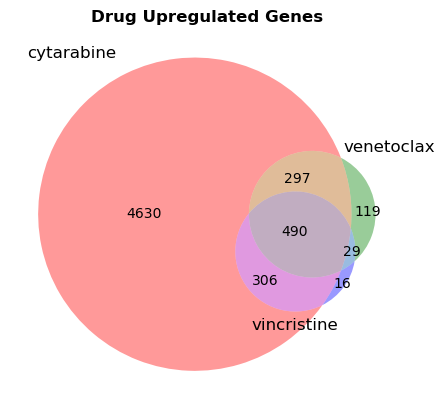

Intersection of All 3 : 490 total
ABCA6 ABCA7 ABCC3 ABHD6 ABTB1 ADA2 ADAM23 ADAMDEC1 ADAMTS5 ADAP2 ADGRE3 ADGRE4P ADGRG3 ADM ADORA3 ADRB2 ALOX5 ALOX5AP ANGPT4 ANTXR1 ANXA1 ANXA2 ANXA5 AOAH AP1S2 APOBR APOE AQP9 ARAP3 ARHGAP24 ARHGEF28 ARID3B ARSD ASAH1 ASGR2 ATOH8 ATOSB ATP2B1-AS1 BAIAP2 BATF BCL2A1 BCL6 BEST1 BHLHE40 BHLHE41 BIN2 BNC2 BRI3 BST1 BTG2-DT C1QC C3 C5AR1 CACFD1 CADM1 CAMK2D CAMSAP2 CAPG CAPN2 CARD14 CCSER1 CD101 CD14 CD1D CD300C CD36 CD58 CD63 CDA CDKN1A CDKN1C CEACAM1 CEACAM3 CEMIP2 CES1 CFP CHI3L1 CHIT1 CKAP4 CLEC2B CLEC4E CLEC6A COLEC12 CPED1 CPM CPQ CR1 CR1L CRACDL CRISPLD2 CSRNP1 CSRP2 CSTB CTSD CTSO CTSZ CXCL8 CYLD-AS1 CYP1B1-AS1 CYP2S1 CYP4F3 DAB2 DAPK1 DAPK2 DDIT4L DKK3 DNAJB2 DOCK10 DPYD DPYD-AS2 DUSP1 DYNLT4 DYSF EGR1 ENC1 ENG ENSG00000231964 ENSG00000234424 ENSG00000236525 ENSG00000236911 ENSG00000250893 ENSG00000258875 ENSG00000261596 ENSG00000262580 ENSG00000266865 ENSG00000268355 ENSG00000270911 ENSG00000273837 ENSG00000279138 ENSG00000279141 ENSG00000279917 

In [32]:
drugs = {}
for key,de_df in bulk_de_tables_dict.items():
    df = de_df.copy()
    df = df[(df['l2fc']>.7)&(df['pval_bh_corrected']<.05)]
    gene_list = df.index.to_list()
    gene_list = [ensembl_to_hgnc_non_unique_dict.get(x,x) for x in gene_list]
    drugs[key] = set(gene_list)

for key, gene_set in drugs.items():
    print(key,len(gene_set))

# Convert lists to sets
set_cytarabine = set(drugs['cytarabine'])
set_venetoclax = set(drugs['venetoclax'])
set_vincristine = set(drugs['vincristine'])

# Calculate intersections
intersection_cyt_ven = set_cytarabine & set_venetoclax
intersection_cyt_vin = set_cytarabine & set_vincristine
intersection_ven_vin = set_venetoclax & set_vincristine
intersection_all = set_cytarabine & set_venetoclax & set_vincristine

# Create the Venn diagram
venn3(
    subsets=(set_cytarabine, set_venetoclax, set_vincristine),
    set_labels=('cytarabine', 'venetoclax', 'vincristine'),
    #set_colors=('b', 'orange', 'g')
)
plt.title('Drug Upregulated Genes',fontweight='bold')
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

#print intersection of all 3
gene_list = sorted(list(intersection_all))
print('Intersection of All 3',':',len(gene_list),'total')
print(' '.join(gene_list))

#### Enrichr (for upregulated genes)

C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\gseapy\plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\gseapy\plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


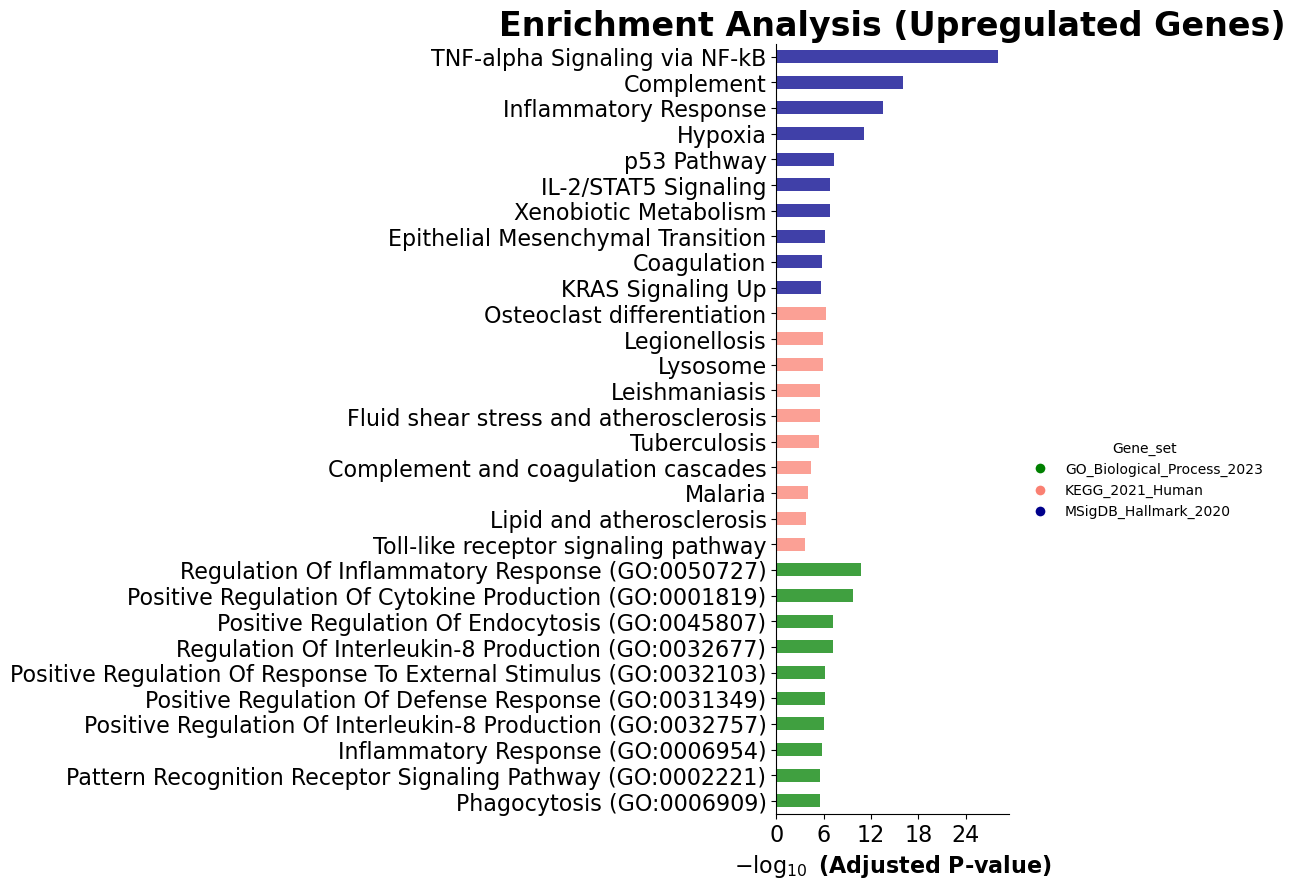

In [33]:
gene_sets=['MSigDB_Hallmark_2020','KEGG_2021_Human','GO_Biological_Process_2023']

try:
    enr = gp.enrichr(gene_list=gene_list, 
                     gene_sets=gene_sets,
                     organism='human', 
                     outdir=None, 
                    )
    ax = barplot(enr.results,
                  column="Adjusted P-value",
                  group='Gene_set', 
                  size=10,
                  top_term=10,
                  figsize=(3,10),
                 cutoff = .05,
                  color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue','GO_Biological_Process_2023':'green'},
                 title = "Enrichment Analysis (Upregulated Genes)",
                 rasterize = True
                 )
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
    
except:
    logging.error("enrichr API failed")

#### Venn Diagrams (for downregulated genes)

cytarabine 4128
vincristine 341
venetoclax 575


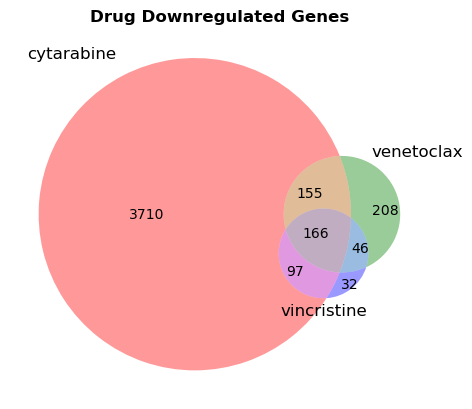

Intersection of All 3 : 166 total
ACACA ADM2 ALDH1L2 ALDOAP1 ASNS ATF4P4 ATP5F1AP2 B4GAT1-DT BTN3A3 CCDC26 CCND2 CEP70 CHAC1 CYP51A1P1 CYP51A1P2 DHCR7 ECE1 EEF1A1P11 EEF1A1P38 ENSG00000202357 ENSG00000207410 ENSG00000213867 ENSG00000213939 ENSG00000213956 ENSG00000218175 ENSG00000219928 ENSG00000220472 ENSG00000223559 ENSG00000223901 ENSG00000230291 ENSG00000232176 ENSG00000233287 ENSG00000233953 ENSG00000235111 ENSG00000237214 ENSG00000238085 ENSG00000240376 ENSG00000243445 ENSG00000243777 ENSG00000250568 ENSG00000253926 ENSG00000257270 ENSG00000260417 ENSG00000260949 ENSG00000262823 ENSG00000265490 ENSG00000267762 ENSG00000270071 ENSG00000270124 ENSG00000277654 ENSG00000278969 ENSG00000278983 FADS2 FASN FAUP1 FSD2 GPER1 GPT2 GRIN1 HMGA1P1 HMGA1P8 HMGCS1 HSD17B7 IGLL1 INSIG1 ITM2A LDLR LINC00235 LINC01355 LRRC14B LSS MEGF6 MIR3186 MIR3686 MIR99AHG MSMO1 MT-TC MTHFD2P7 MVK MYLK-AS1 MZB1 NECTIN1-AS1 NMNAT3 NPIPA9 NPM1P33 OLMALINC PABPC1P4 PCK2 PGK1P2 PHGDH PLEKHG4 PLXND1 PRG2 PRSS57 PSA

In [34]:
drugs = {}
for key,de_df in bulk_de_tables_dict.items():
    df = de_df.copy()
    df = df[(df['l2fc']<-.7)&(df['pval_bh_corrected']<.05)]
    gene_list = df.index.to_list()
    gene_list = [ensembl_to_hgnc_non_unique_dict.get(x,x) for x in gene_list]
    drugs[key] = set(gene_list)

for key, gene_set in drugs.items():
    print(key,len(gene_set))

# Convert lists to sets
set_cytarabine = set(drugs['cytarabine'])
set_venetoclax = set(drugs['venetoclax'])
set_vincristine = set(drugs['vincristine'])

# Calculate intersections
intersection_cyt_ven = set_cytarabine & set_venetoclax
intersection_cyt_vin = set_cytarabine & set_vincristine
intersection_ven_vin = set_venetoclax & set_vincristine
intersection_all = set_cytarabine & set_venetoclax & set_vincristine

# Create the Venn diagram
venn3(
    subsets=(set_cytarabine, set_venetoclax, set_vincristine),
    set_labels=('cytarabine', 'venetoclax', 'vincristine'),
    #set_colors=('b', 'orange', 'g')
)
plt.title('Drug Downregulated Genes',fontweight='bold')
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

#print intersection of all 3
gene_list = sorted(list(intersection_all))
print('Intersection of All 3',':',len(gene_list),'total')
print(' '.join(gene_list))

#### Enrichr (for downregulated genes)

C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\gseapy\plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\gseapy\plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


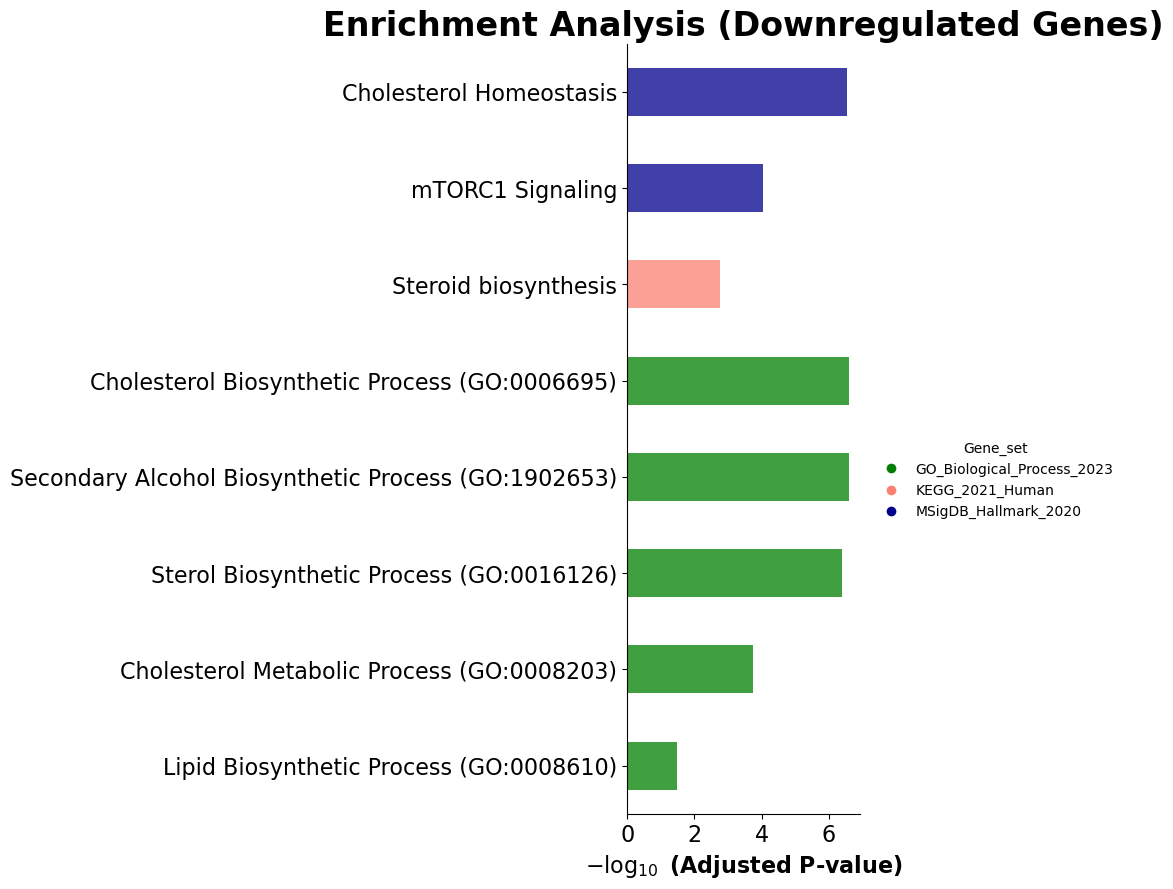

In [35]:
gene_sets=['MSigDB_Hallmark_2020','KEGG_2021_Human','GO_Biological_Process_2023']

try:
    enr = gp.enrichr(gene_list=gene_list, 
                     gene_sets=gene_sets,
                     organism='human', 
                     outdir=None, 
                    )
    ax = barplot(enr.results,
                  column="Adjusted P-value",
                  group='Gene_set', 
                  size=10,
                  top_term=10,
                  figsize=(3,10),
                 cutoff = .05,
                  color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue','GO_Biological_Process_2023':'green'},
                 title = "Enrichment Analysis (Downregulated Genes)",
                 rasterize = True
                 )
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")

except:
    logging.error("enrichr API failed")

### Supplemental Figure 2 (Cohorts) : volcano plot + venn diagram and intersection + GO Analysis

#### Volcano Plots

0  de genes


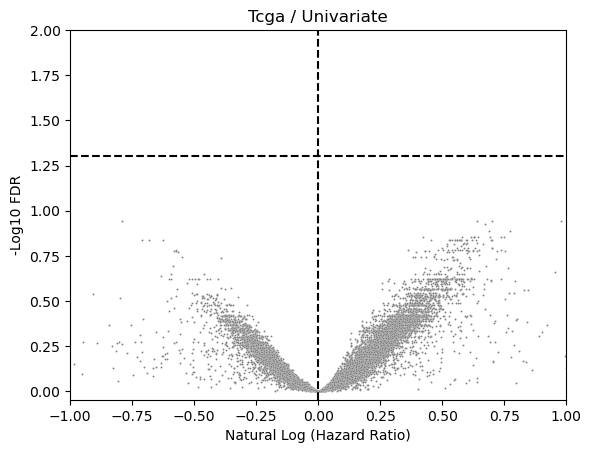

225  de genes


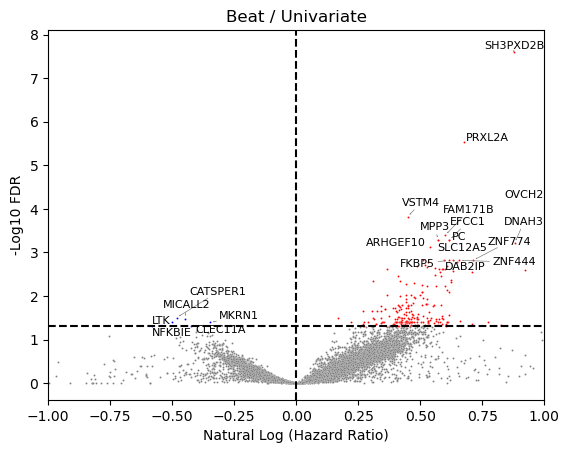

217  de genes


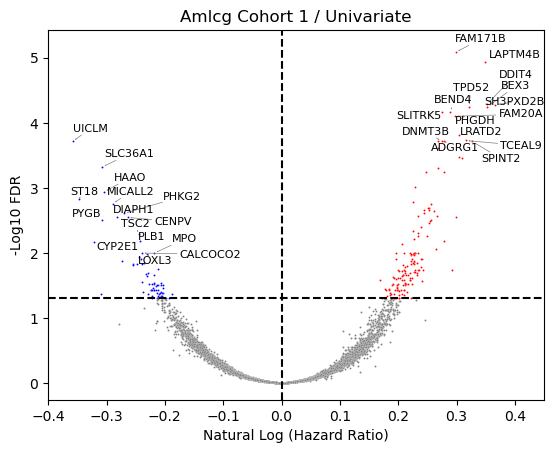

91  de genes


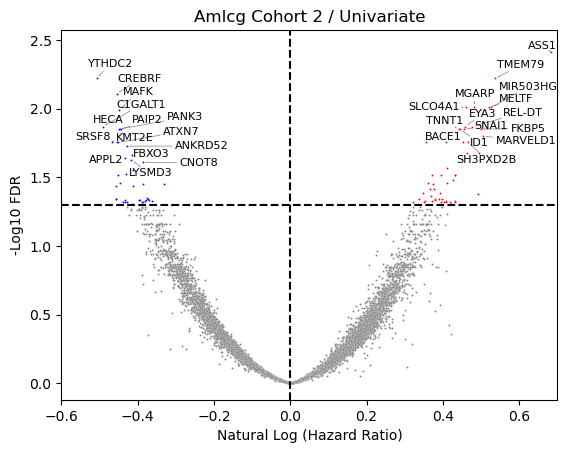

In [36]:
cohort_keys = ['TCGA / Univariate','Beat / Univariate','AMLCG Cohort 1 / Univariate','AMLCG Cohort 2 / Univariate']
for cohort in cohort_keys:
    df = cox_ph_fit_dict[cohort]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
    df['-log10pval_bh_corrected'] = df['pval_bh_corrected'].apply(lambda x: -np.log10(x+1e-300))
    max_y_value = df['-log10pval_bh_corrected'].max()
    df['hgnc'] = df.index
    df['hgnc'] = df['hgnc'].apply(lambda x: ensembl_to_hgnc_non_unique_dict.get(x,x))
    
    df_pos = df.copy()
    df_pos = df_pos[(df_pos['coef']>0)&(df_pos['pval_bh_corrected']<.05)]
    df_neg = df.copy()
    df_neg = df_neg[(df_neg['coef']<0)&(df_neg['pval_bh_corrected']<.05)]
    df_not_de = df.copy()
    df_not_de = df_not_de[(df_not_de['coef']==.7)|~(df_not_de['pval_bh_corrected']<.05)]
    df_de = df.copy()
    df_de = df_de[(df_de['coef'].abs()>0)&(df_de['pval_bh_corrected']<.05)]
    print(len(df_de),' de genes')

    top_pos = df_pos.sort_values(by=['pval_bh_corrected', 'coef'], ascending=[True, False]).head(15)
    top_neg = df_neg.sort_values(by=['pval_bh_corrected', 'coef'], ascending=[True, True]).head(15)
    
    s=2 #point size
    
    sns.scatterplot(df_pos,x='coef',y='-log10pval_bh_corrected',s=s,color = 'red', rasterized = True)
    sns.scatterplot(df_neg,x='coef',y='-log10pval_bh_corrected',s=s,color = 'blue',rasterized = True)
    sns.scatterplot(df_not_de,x='coef',y='-log10pval_bh_corrected',s=s,color = 'grey',rasterized = True)
    plt.xlim(-1,1)
    plt.ylim(None, max_y_value+(max_y_value/15))
    plt.title(cohort.split('(')[0].title())

    #makes the lack of DE easier to see for reader
    if 'TCGA' in cohort:
        plt.ylim(None,2)
    
    if 'AMLCG Cohort 1' in cohort:
        plt.xlim(-.4,.45)
    if 'AMLCG Cohort 2' in cohort:
        plt.xlim(-.6,.7)
    
    texts = []
    for _, row in top_pos.iterrows():
        texts.append(plt.text(row['coef'], row['-log10pval_bh_corrected'], row['hgnc'], 
                              fontsize=8, color='black'))
    
    for _, row in top_neg.iterrows():
        texts.append(plt.text(row['coef'], row['-log10pval_bh_corrected'], row['hgnc'], 
                              fontsize=8, color='black'))
    
    # Adjust text positions to avoid overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
    
    # Remove axis labels
    plt.xlabel('Natural Log (Hazard Ratio)')
    plt.ylabel('-Log10 FDR')


    plt.axhline(1.3010,linestyle='--',color='black')
    plt.axvline(0,linestyle='--',color='black')

    # Show the plot
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()

#### Venn Diagrams (for poor prognostic genes)

Tcga 0
Beat 219
Amlcg Cohort 1 150
Amlcg Cohort 2 51


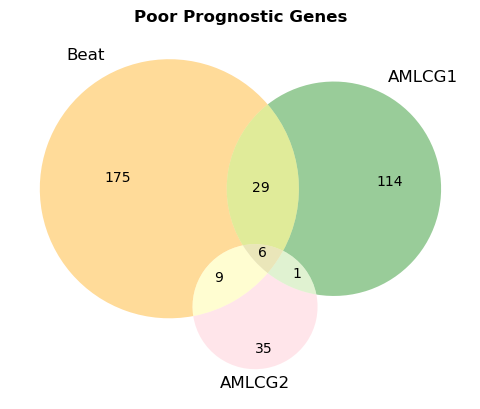

Intersection of All 3 : 6 total
LAMC1 PHGDH SCD SH3PXD2B SQLE TMEM273


In [37]:
cohorts = {}
cohort_keys = ['TCGA / Univariate','Beat / Univariate','AMLCG Cohort 1 / Univariate','AMLCG Cohort 2 / Univariate']
for cohort in cohort_keys:
    df = cox_ph_fit_dict[cohort]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
    df = df[(df['coef']>0)&(df['pval_bh_corrected']<.05)]
    gene_list = df.index.to_list()
    gene_list = [ensembl_to_hgnc_non_unique_dict.get(x,x) for x in gene_list]
    cohorts[cohort.split('/')[0].strip(' ').title()] = set(gene_list)

for key, gene_set in cohorts.items():
    print(key,len(gene_set))

# Convert lists to sets
set_beat = cohorts['Beat']
set_amlcg1 = cohorts['Amlcg Cohort 1']
set_amlcg2 = cohorts['Amlcg Cohort 2']

# Calculate intersections
intersection_all = set_beat & set_amlcg1 & set_amlcg2

# Create the Venn diagram
venn3(
    subsets=(set_beat, set_amlcg1, set_amlcg2),
    set_labels=('Beat', 'AMLCG1', 'AMLCG2'),
    set_colors=('orange', 'green', 'pink')
)
plt.title('Poor Prognostic Genes',fontweight='bold')
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

#print intersection of all 3
gene_list = sorted(list(intersection_all))
print('Intersection of All 3',':',len(gene_list),'total')
print(' '.join(gene_list))

#### Enrichr (for poor prognostic genes)

C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\gseapy\plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\gseapy\plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


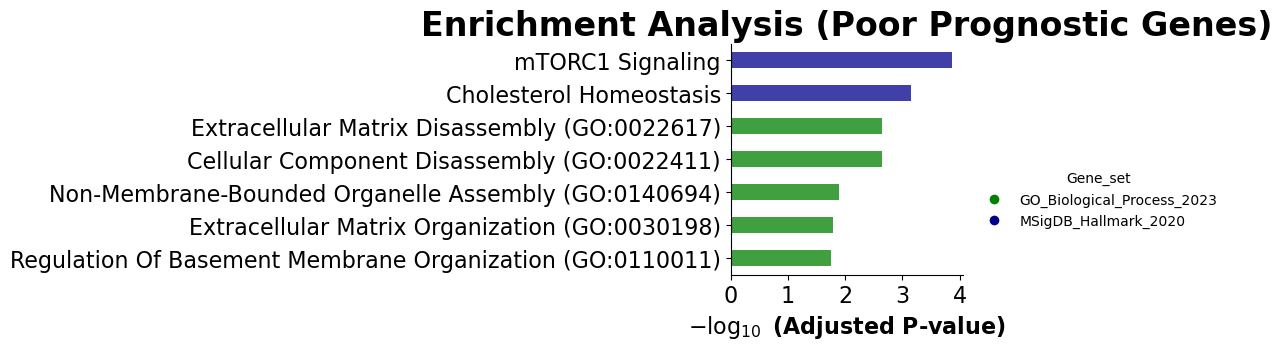

In [38]:
gene_sets=['MSigDB_Hallmark_2020','KEGG_2021_Human','GO_Biological_Process_2023']

try:
    enr = gp.enrichr(gene_list=gene_list,
                     gene_sets=gene_sets,
                     organism='human', 
                     outdir=None, 
                    )
    
    ax = barplot(enr.results,
                  column="Adjusted P-value",
                  group='Gene_set', 
                  size=10,
                  top_term=5,
                  figsize=(3,3),
                 cutoff = .05,
                  color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue','GO_Biological_Process_2023':'green'},
                 title = "Enrichment Analysis (Poor Prognostic Genes)"
                 )

    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")

except:
    logging.error('enrichr API failed')

#### Venn Diagrams (for Favorable prognostic genes)

Tcga 0
Beat 6
Amlcg Cohort 1 67
Amlcg Cohort 2 40


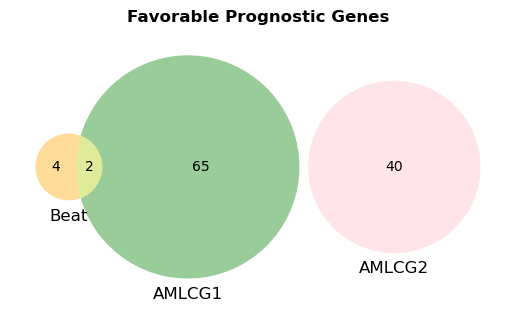

Intersection of All 3 : 0 total



In [39]:
cohorts = {}
cohort_keys = ['TCGA / Univariate','Beat / Univariate','AMLCG Cohort 1 / Univariate','AMLCG Cohort 2 / Univariate']
for cohort in cohort_keys:
    df = cox_ph_fit_dict[cohort]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
    df = df[(df['coef']<0)&(df['pval_bh_corrected']<.05)]
    gene_list = df.index.to_list()
    gene_list = [ensembl_to_hgnc_non_unique_dict.get(x,x) for x in gene_list]
    cohorts[cohort.split('/')[0].strip(' ').title()] = set(gene_list)

for key, gene_set in cohorts.items():
    print(key,len(gene_set))

# Convert lists to sets
set_beat = cohorts['Beat']
set_amlcg1 = cohorts['Amlcg Cohort 1']
set_amlcg2 = cohorts['Amlcg Cohort 2']

# Calculate intersections
intersection_all = set_beat & set_amlcg1 & set_amlcg2

# Create the Venn diagram
venn3(
    subsets=(set_beat, set_amlcg1, set_amlcg2),
    set_labels=('Beat', 'AMLCG1', 'AMLCG2'),
    set_colors=('orange', 'green', 'pink')
)
plt.title('Favorable Prognostic Genes',fontweight='bold')
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

#print intersection of all 3
gene_list = sorted(list(intersection_all))
print('Intersection of All 3',':',len(gene_list),'total')
print(' '.join(gene_list))

#### Same as above but for multivariate case

0  de genes


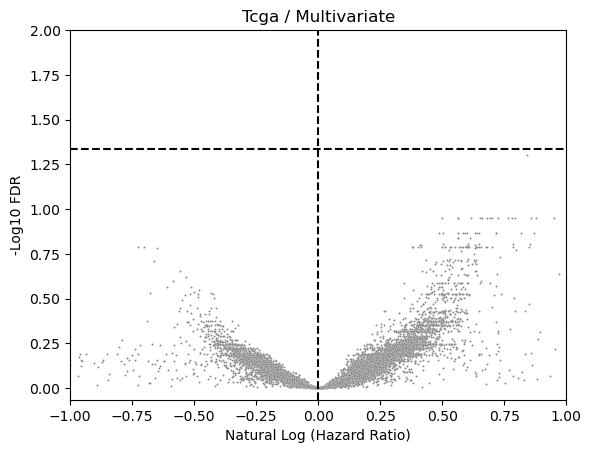

36  de genes


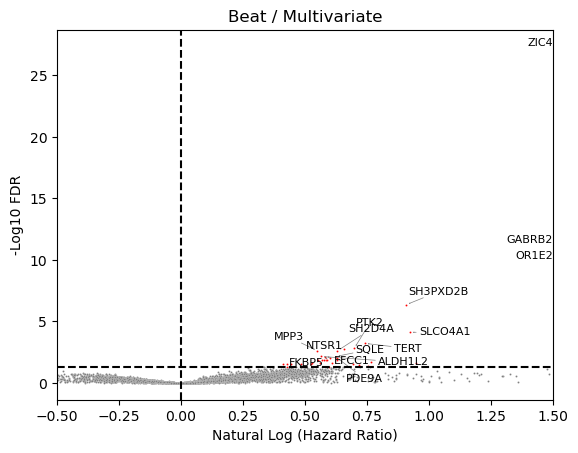

54  de genes


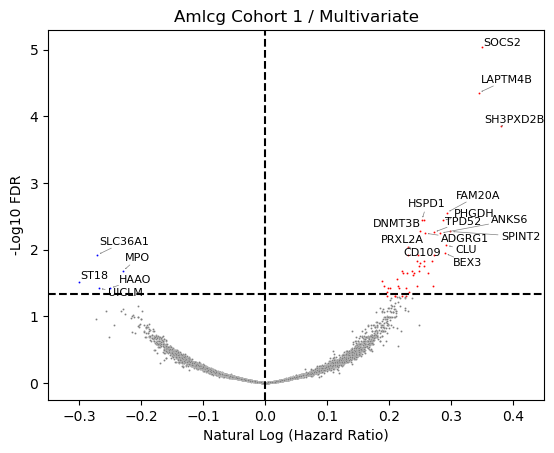

231  de genes


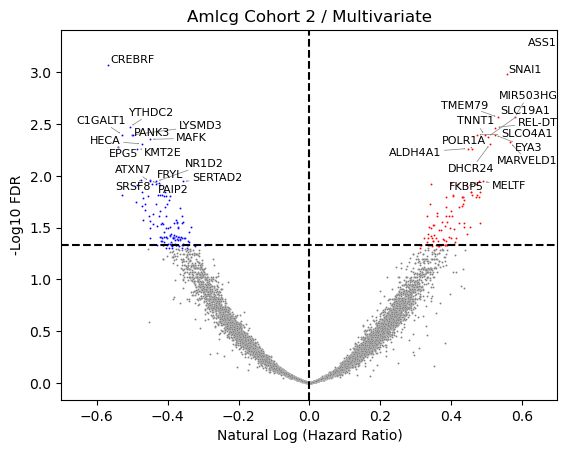

Tcga 0
Beat 36
Amlcg Cohort 1 49
Amlcg Cohort 2 101


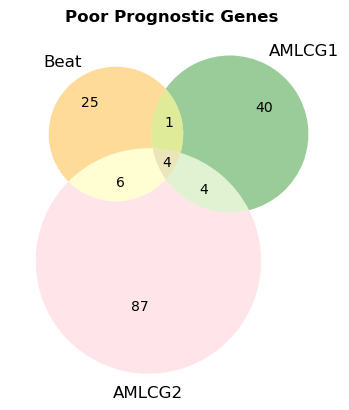

Intersection of All 3 : 4 total
ALDH1L2 PRXL2A SH3PXD2B SQLE


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\gseapy\plot.py:694: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\gseapy\plot.py:694: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[self.colname].replace(


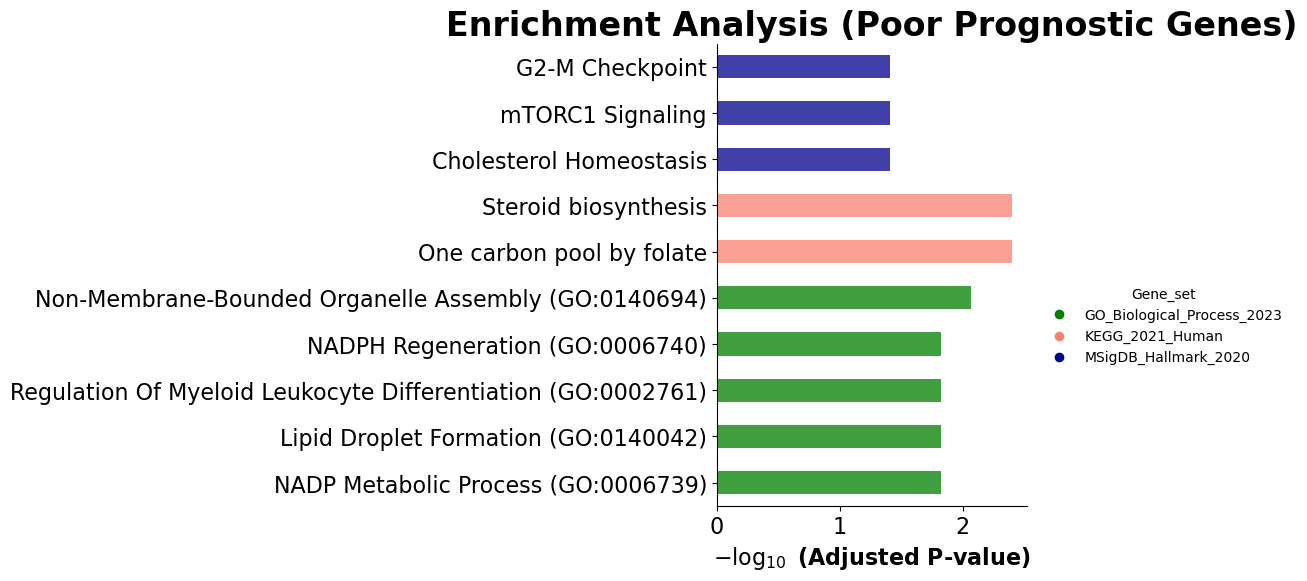

Tcga 0
Beat 6
Amlcg Cohort 1 67
Amlcg Cohort 2 40


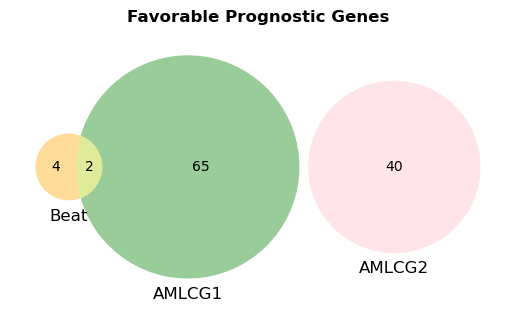

Intersection of All 3 : 0 total



In [40]:
cohort_keys = ['TCGA / Multivariate','Beat / Multivariate','AMLCG Cohort 1 / Multivariate','AMLCG Cohort 2 / Multivariate']
for cohort in cohort_keys:
    df = cox_ph_fit_dict[cohort]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
    df['-log10pval_bh_corrected'] = df['pval_bh_corrected'].apply(lambda x: -np.log10(x+1e-300))
    df['hgnc'] = df.index
    df['hgnc'] = df['hgnc'].apply(lambda x: ensembl_to_hgnc_non_unique_dict.get(x,x))
    
    df_pos = df.copy()
    df_pos = df_pos[(df_pos['coef']>0)&(df_pos['pval_bh_corrected']<.05)]
    df_neg = df.copy()
    df_neg = df_neg[(df_neg['coef']<0)&(df_neg['pval_bh_corrected']<.05)]
    df_not_de = df.copy()
    df_not_de = df_not_de[(df_not_de['coef']==.7)|~(df_not_de['pval_bh_corrected']<.05)]
    df_de = df.copy()
    df_de = df_de[(df_de['coef'].abs()>0)&(df_de['pval_bh_corrected']<.05)]
    print(len(df_de),' de genes')
    
    top_pos = df_pos.sort_values(by=['pval_bh_corrected', 'coef'], ascending=[True, False]).head(15)
    top_neg = df_neg.sort_values(by=['pval_bh_corrected', 'coef'], ascending=[True, True]).head(15)
    
    s=2 #point size
    
    sns.scatterplot(df_pos,x='coef',y='-log10pval_bh_corrected',s=s,color = 'red',rasterized = True)
    sns.scatterplot(df_neg,x='coef',y='-log10pval_bh_corrected',s=s,color = 'blue',rasterized = True)
    sns.scatterplot(df_not_de,x='coef',y='-log10pval_bh_corrected',s=s,color = 'grey',rasterized =True)
    plt.xlim(-1,1)
    plt.title(cohort.split('(')[0].title())
    
    #better display choices
    if 'TCGA' in cohort:
        plt.ylim(None,2)
    if 'Beat' in cohort:
        plt.xlim(-.5,1.5)
    if 'AMLCG Cohort 1' in cohort:
        plt.xlim(-.35,.45)
    if 'AMLCG Cohort 2' in cohort:
        plt.xlim(-.7,.7)

    texts = []
    for _, row in top_pos.iterrows():
        texts.append(plt.text(row['coef'], row['-log10pval_bh_corrected'], row['hgnc'], 
                              fontsize=8, color='black'))
    
    for _, row in top_neg.iterrows():
        texts.append(plt.text(row['coef'], row['-log10pval_bh_corrected'], row['hgnc'], 
                              fontsize=8, color='black'))
    
    # Adjust text positions to avoid overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
    
    # Remove axis labels
    plt.xlabel('Natural Log (Hazard Ratio)')
    plt.ylabel('-Log10 FDR')

    plt.axhline(1.33333,linestyle='--',color='black')
    plt.axvline(0,linestyle='--',color='black')

    # Show the plot
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg'  + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()

cohorts = {}
cohort_keys = ['TCGA / Multivariate','Beat / Multivariate','AMLCG Cohort 1 / Multivariate','AMLCG Cohort 2 / Multivariate']
for cohort in cohort_keys:
    df = cox_ph_fit_dict[cohort]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
    df = df[(df['coef']>0)&(df['pval_bh_corrected']<.05)]
    gene_list = df.index.to_list()
    gene_list = [ensembl_to_hgnc_non_unique_dict.get(x,x) for x in gene_list]
    cohorts[cohort.split('/')[0].strip(' ').title()] = set(gene_list)

for key, gene_set in cohorts.items():
    print(key,len(gene_set))

# Convert lists to sets
set_beat = cohorts['Beat']
set_amlcg1 = cohorts['Amlcg Cohort 1']
set_amlcg2 = cohorts['Amlcg Cohort 2']

# Calculate intersections
intersection_all = set_beat & set_amlcg1 & set_amlcg2

# Create the Venn diagram
venn3(
    subsets=(set_beat, set_amlcg1, set_amlcg2),
    set_labels=('Beat', 'AMLCG1', 'AMLCG2'),
    set_colors=('orange', 'green', 'pink')
)
plt.title('Poor Prognostic Genes',fontweight='bold')
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg'  + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

#print intersection of all 3
gene_list = sorted(list(intersection_all))
print('Intersection of All 3',':',len(gene_list),'total')
print(' '.join(gene_list))

gene_sets=['MSigDB_Hallmark_2020','KEGG_2021_Human','GO_Biological_Process_2023']

try:
    # if you are only intrested in dataframe that enrichr returned, please set outdir=None
    enr = gp.enrichr(gene_list=gene_list, # or "./tests/data/gene_list.txt",
                     gene_sets=gene_sets,
                     organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                     outdir=None, # don't write to disk
                     #background=[ensembl_to_hgnc_dict.get(x,x) for x in list(all_genes_assessed_set)]
                    )
    
    ax = barplot(enr.results,
                  column="Adjusted P-value",
                  group='Gene_set', # set group, so you could do a multi-sample/library comparsion
                  size=10,
                  top_term=5,
                  #figsize=(3,10),
                 cutoff = .05,
                  color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue','GO_Biological_Process_2023':'green'},
                 title = "Enrichment Analysis (Poor Prognostic Genes)"
                 )
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg'  + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()
    
except:
    logging.error('enrichr API failed')
#------------------------------------------------------------------
cohorts = {}
cohort_keys = ['TCGA / Univariate','Beat / Univariate','AMLCG Cohort 1 / Univariate','AMLCG Cohort 2 / Univariate']
for cohort in cohort_keys:
    df = cox_ph_fit_dict[cohort]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
    df = df[(df['coef']<0)&(df['pval_bh_corrected']<.05)]
    gene_list = df.index.to_list()
    gene_list = [ensembl_to_hgnc_non_unique_dict.get(x,x) for x in gene_list]
    cohorts[cohort.split('/')[0].strip(' ').title()] = set(gene_list)

for key, gene_set in cohorts.items():
    print(key,len(gene_set))

# Convert lists to sets
set_beat = cohorts['Beat']
set_amlcg1 = cohorts['Amlcg Cohort 1']
set_amlcg2 = cohorts['Amlcg Cohort 2']

# Calculate intersections
intersection_all = set_beat & set_amlcg1 & set_amlcg2

# Create the Venn diagram
venn3(
    subsets=(set_beat, set_amlcg1, set_amlcg2),
    set_labels=('Beat', 'AMLCG1', 'AMLCG2'),
    set_colors=('orange', 'green', 'pink')
)
plt.title('Favorable Prognostic Genes',fontweight='bold')
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg'  + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

#print intersection of all 3
gene_list = sorted(list(intersection_all))
print('Intersection of All 3',':',len(gene_list),'total')
print(' '.join(gene_list))


# Creating "Master" Drug/Cohort Info dicts
essentially just a reorganization of existing data for drug exps and cohort analyses

in master drug info dict, each key corresponds to a specific metric (e.g. 'Log2foldchange') for each gene and each HL-60 drug experiment

in master cohort info dict, each key corresponds to a specific metric (e.g. Hazard ratio) for each gene and each cohort analysis

In [41]:
# just defining a different key order for cohorts to be called below
cohort_keys = [x for x in cox_ph_fit_dict.keys()]
cohort_keys = cohort_keys[::-1]
cohort_keys

['TCGA / Univariate',
 'TCGA / Multivariate',
 'Beat / Univariate',
 'Beat / Multivariate',
 'AMLCG Cohort 2 / Univariate',
 'AMLCG Cohort 2 / Multivariate',
 'AMLCG Cohort 1 / Univariate',
 'AMLCG Cohort 1 / Multivariate']

In [42]:
#defining a function for when we only care about whether a value is positive or negative
def assign_sign(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return np.nan 

In [43]:
#take all the info from the drug and cohort dictionaries and insert into dataframes that will capture a given metric across experiments/cohorts
master_drug_info_dict = {}
for metric in ['l2fc','pval_bh_corrected']:
    dict_dfs = []
    for key in bulk_de_tables_dict.keys():
        dict_df = bulk_de_tables_dict[key].copy()
        dict_df = dict_df[[metric]]
        dict_df=dict_df.rename(columns = {metric:key})
        dict_df = dict_df.T
        dict_dfs.append(dict_df)
        master_drug_info_dict[metric] = pd.concat(dict_dfs)

master_drug_info_dict['l2fc_sign']= master_drug_info_dict['l2fc'].copy()
master_drug_info_dict['l2fc_sign'] = master_drug_info_dict['l2fc_sign'].applymap(assign_sign)

master_drug_info_dict['neg_log_10_pval_bh_corrected'] = master_drug_info_dict['pval_bh_corrected'].copy()
master_drug_info_dict['neg_log_10_pval_bh_corrected'] = master_drug_info_dict['neg_log_10_pval_bh_corrected'].apply(lambda x: -np.log10(x + 1e-300))

#seems bizarre but might need for certain visual displays
master_drug_info_dict['signed_neg_log_10_pval_bh_corrected'] = master_drug_info_dict['neg_log_10_pval_bh_corrected'] *master_drug_info_dict['l2fc_sign']

#---------------------------------------------------------------------------------------------------------------------------------

master_cohort_info_dict = {}
for metric in ['coef','exp(coef)','pval_bh_corrected','concordance_index_']:
    dict_dfs = []
    for key in cohort_keys:
        dict_df = cox_ph_fit_dict[key]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
        dict_df = dict_df[[metric]]
        dict_df=dict_df.rename(columns = {metric:key})
        dict_df = dict_df.T
        dict_dfs.append(dict_df)
        master_cohort_info_dict[metric] = pd.concat(dict_dfs)
        
#only really interested in the univariate case of concordance indeces, ignore others
master_cohort_info_dict['concordance_index_'].loc[master_cohort_info_dict['concordance_index_'].index.str.contains('Multi'), :] = np.nan

#this one just tells you the coeff sign for a prog marker
master_cohort_info_dict['coef_sign'] = master_cohort_info_dict['coef'].copy()
master_cohort_info_dict['coef_sign'] = master_cohort_info_dict['coef_sign'].applymap(assign_sign)
#these two are -log10 fdr value, and then the same thing but the sign is flipped for good prog markers (so it's negative)
master_cohort_info_dict['neg_log_10_pval_bh_corrected'] = master_cohort_info_dict['pval_bh_corrected'].copy()
master_cohort_info_dict['neg_log_10_pval_bh_corrected'] = master_cohort_info_dict['neg_log_10_pval_bh_corrected'].apply(lambda x: -np.log10(x))
master_cohort_info_dict['signed_neg_log_10_pval_bh_corrected'] = master_cohort_info_dict['neg_log_10_pval_bh_corrected'] *master_cohort_info_dict['coef_sign']


#this retains existing concordance index for poor prognostic genes and recalculates good as (1-bad)
#this way you can just look at a gene and see the conocrdance index assuming it's bad. More generally this is the same as just asking:
# 'how often does the person with higher experssion die first' in every pairwise comparison
master_cohort_info_dict['modified_concordance_index_'] = pd.DataFrame(np.nan, 
                                                                  index=master_cohort_info_dict['concordance_index_'].index, 
                                                                  columns=master_cohort_info_dict['concordance_index_'].columns)
positive_mask = master_cohort_info_dict['coef_sign'] == 1
negative_mask = master_cohort_info_dict['coef_sign'] == -1
master_cohort_info_dict['modified_concordance_index_'][positive_mask] = master_cohort_info_dict['concordance_index_'][positive_mask]
master_cohort_info_dict['modified_concordance_index_'][negative_mask] = 1 - master_cohort_info_dict['concordance_index_'][negative_mask]

#---------------------------------------------------------------------
for key in master_drug_info_dict.keys():
    master_drug_info_dict[key] = master_drug_info_dict[key].astype(float)
    print('master_drug_info_dict:',key)

print('')

for key in master_cohort_info_dict.keys():
    master_cohort_info_dict[key] = master_cohort_info_dict[key].astype(float)
    print('master_cohort_info_dict:',key)

C:\Users\andre\AppData\Local\Temp\ipykernel_764\1226968951.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  master_drug_info_dict['l2fc_sign'] = master_drug_info_dict['l2fc_sign'].applymap(assign_sign)
C:\Users\andre\AppData\Local\Temp\ipykernel_764\1226968951.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  master_cohort_info_dict['coef_sign'] = master_cohort_info_dict['coef_sign'].applymap(assign_sign)


master_drug_info_dict: l2fc
master_drug_info_dict: pval_bh_corrected
master_drug_info_dict: l2fc_sign
master_drug_info_dict: neg_log_10_pval_bh_corrected
master_drug_info_dict: signed_neg_log_10_pval_bh_corrected

master_cohort_info_dict: coef
master_cohort_info_dict: exp(coef)
master_cohort_info_dict: pval_bh_corrected
master_cohort_info_dict: concordance_index_
master_cohort_info_dict: coef_sign
master_cohort_info_dict: neg_log_10_pval_bh_corrected
master_cohort_info_dict: signed_neg_log_10_pval_bh_corrected
master_cohort_info_dict: modified_concordance_index_


# Creating "gene counts dict" 
this will store genes that are DE and Prognostic in at least 1 cohort and 1 drug exp

keys will indicate a more specific overlap (e.g. bad prog and upregulated)

In [44]:
#create dicts storing metadata/broader assessment data 

#create drug induced(or supressed) genes dict from marlees bulk table and cmap df imported
drug_genes_dict = {}
for key in bulk_de_tables_dict.keys():
    drug_genes_dict[key] = {}
    df = bulk_de_tables_dict[key].copy()
    drug_genes_dict[key]['genes assessed'] = set(df.index)
    drug_genes_dict[key]['upregulated'] = set(df[(df['l2fc']>.7)&(df['pval_bh_corrected']<.05)].index)
    drug_genes_dict[key]['downregulated'] = set(df[(df['l2fc']<-.7)&(df['pval_bh_corrected']<.05)].index)

#create prognostic genes dict
prog_genes_dict = {}

for key in cohort_keys:
    prog_genes_dict[key] = {}
    df = cox_ph_fit_dict[key]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
    prog_genes_dict[key]['genes assessed'] = set(df.index)
    prog_genes_dict[key]['bad prognostic'] = set(df[(df['coef']>0)&(df['pval_bh_corrected']<.05)].index)
    prog_genes_dict[key]['good prognostic'] = set(df[(df['coef']<0)&(df['pval_bh_corrected']<.05)].index)

for key in drug_genes_dict.keys():
    print(key,len(drug_genes_dict[key]['genes assessed']))
        
for key in prog_genes_dict.keys():
    print(key,len(prog_genes_dict[key]['genes assessed']))
#---------------------------------------------------------------------------
#create dfs storing qualitative info

#create drug df
drug_df = pd.DataFrame(columns = ['label','upregulated','downregulated','genes assessed','drug'])
for key in drug_genes_dict.keys():
    if key not in drug_df['label'].to_list():
        df = pd.DataFrame(index =[1],columns = ['upregulated','downregulated','genes assessed'])
        df['label'] = key
        df['drug'] = key
        df.at[1, 'upregulated'] = drug_genes_dict[key]['upregulated']
        df.at[1, 'downregulated'] = drug_genes_dict[key]['downregulated']
        df.at[1, 'genes assessed'] = drug_genes_dict[key]['genes assessed']
        drug_df = pd.concat([drug_df,df])
drug_df = drug_df.reset_index(drop = True)
drug_df['upregulated'] = drug_df['upregulated'].apply(lambda x: set(x))
drug_df['downregulated'] = drug_df['downregulated'].apply(lambda x: set(x))
drug_df['genes assessed'] = drug_df['genes assessed'].apply(lambda x: set(x))

#create prog df
prog_df= pd.DataFrame()
for key in prog_genes_dict.keys():
    df = pd.DataFrame(index =[1],columns = ['bad prognostic','good prognostic','genes assessed'])
    df['label'] = key
    df.at[1, 'bad prognostic'] = prog_genes_dict[key]['bad prognostic']
    df.at[1, 'good prognostic'] = prog_genes_dict[key]['good prognostic']
    df.at[1, 'genes assessed'] = prog_genes_dict[key]['genes assessed']
    prog_df = pd.concat([prog_df,df])
prog_df = prog_df.reset_index(drop = True)
prog_df['var'] = prog_df['label'].apply(lambda x: x.split('/')[1].strip())
prog_df['cohort'] = prog_df['label'].apply(lambda x: x.split('/')[0].strip())

display(prog_df,drug_df)
#---------------------------------------------------------------------------
gene_counts_dict = {}
for prog in ['bad prognostic','good prognostic']:
    for de in ['upregulated','downregulated']:
        #create gene counts df for querying of gene meeting certain requirements
        prog_df_copy = prog_df.copy()
        prog_df_copy = prog_df_copy[[prog,'label','var','cohort']]
        prog_df_copy = prog_df_copy.explode(prog)
        prog_gene_counts_df = prog_df_copy.groupby(prog).nunique()
        prog_gene_counts_df.index.name = 'gene'
        prog_gene_counts_df = prog_gene_counts_df.rename(columns ={'label':'prognostic_instances','var':'unique_covariate_assessments','cohort':'unique_cohorts'})
        
        drug_df_copy = drug_df.copy()
        drug_df_copy = drug_df_copy[[de,'label','drug']]
        drug_df_copy = drug_df_copy.explode(de)
        drug_gene_counts_df = drug_df_copy.groupby(de).nunique()
        drug_gene_counts_df.index.name = 'gene'
        drug_gene_counts_df = drug_gene_counts_df.rename(columns ={'label':'drug_exp_instances','drug':'unique_drugs'})
        
        gene_counts_df = pd.merge(prog_gene_counts_df,drug_gene_counts_df,how = 'outer', on ='gene')
        gene_counts_df = gene_counts_df.fillna(0)
        gene_counts_df = gene_counts_df.astype(int)
        gene_counts_df = gene_counts_df.sort_values(by = ['unique_cohorts','unique_drugs'],ascending = [False,False])
        gene_counts_df = gene_counts_df[(gene_counts_df['unique_cohorts']>=1) & (gene_counts_df['unique_drugs']>=1)]
        gene_counts_dict[f'{prog} {de}'] = gene_counts_df.copy()


cytarabine 60572
vincristine 60572
venetoclax 60572
TCGA / Univariate 19926
TCGA / Multivariate 19926
Beat / Univariate 19926
Beat / Multivariate 19926
AMLCG Cohort 2 / Univariate 17448
AMLCG Cohort 2 / Multivariate 17448
AMLCG Cohort 1 / Univariate 17448
AMLCG Cohort 1 / Multivariate 17448


,bad prognostic,good prognostic,genes assessed,label,var,cohort
0,{},{},"{ENSG00000177272, ENSG00000136051, ENSG0000014...",TCGA / Univariate,Univariate,TCGA
1,{},{},"{ENSG00000177272, ENSG00000136051, ENSG0000014...",TCGA / Multivariate,Multivariate,TCGA
2,"{ENSG00000124767, ENSG00000198885, ENSG0000015...","{ENSG00000175294, ENSG00000146232, ENSG0000013...","{ENSG00000177272, ENSG00000136051, ENSG0000014...",Beat / Univariate,Univariate,Beat
3,"{ENSG00000107719, ENSG00000136160, ENSG0000017...",{},"{ENSG00000177272, ENSG00000136051, ENSG0000014...",Beat / Multivariate,Multivariate,Beat
4,"{ENSG00000163686, ENSG00000116133, ENSG0000015...","{ENSG00000157764, ENSG00000113141, ENSG0000027...","{ENSG00000013297, ENSG00000137460, ENSG0000000...",AMLCG Cohort 2 / Univariate,Univariate,AMLCG Cohort 2
5,"{ENSG00000155254, ENSG00000105048, ENSG0000013...","{ENSG00000100811, ENSG00000157764, ENSG0000011...","{ENSG00000013297, ENSG00000137460, ENSG0000000...",AMLCG Cohort 2 / Multivariate,Multivariate,AMLCG Cohort 2
6,"{ENSG00000198185, ENSG00000204116, ENSG0000010...","{ENSG00000161513, ENSG00000184730, ENSG0000013...","{ENSG00000013297, ENSG00000187481, ENSG0000000...",AMLCG Cohort 1 / Univariate,Univariate,AMLCG Cohort 1
7,"{ENSG00000166681, ENSG00000162836, ENSG0000019...","{ENSG00000005381, ENSG00000123643, ENSG0000023...","{ENSG00000013297, ENSG00000187481, ENSG0000000...",AMLCG Cohort 1 / Multivariate,Multivariate,AMLCG Cohort 1


,label,upregulated,downregulated,genes assessed,drug
0,cytarabine,"{ENSG00000013297, ENSG00000137460, ENSG0000017...","{ENSG00000264229, ENSG00000287997, ENSG0000010...","{ENSG00000267590, ENSG00000199248, ENSG0000017...",cytarabine
1,vincristine,"{ENSG00000133048, ENSG00000137460, ENSG0000026...","{ENSG00000235492, ENSG00000251333, ENSG0000020...","{ENSG00000267590, ENSG00000199248, ENSG0000017...",vincristine
2,venetoclax,"{ENSG00000240143, ENSG00000133048, ENSG0000013...","{ENSG00000196411, ENSG00000207142, ENSG0000026...","{ENSG00000267590, ENSG00000199248, ENSG0000017...",venetoclax


## Creating Displays of Genes that are prognostic and DE

In [45]:
import PyComplexHeatmap
from PyComplexHeatmap import *


bad prognostic upregulated (drugs)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 300
Plotting legends..
Estimated legend width: 58.03333333333333 mm


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..
Incresing ncol


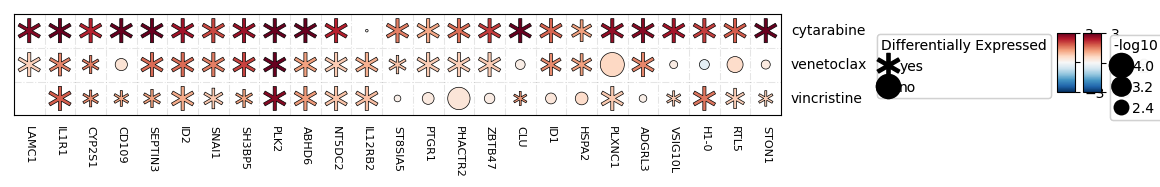


bad prognostic upregulated (cohorts)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 170


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Plotting legends..
Estimated legend width: 25.930555555555557 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


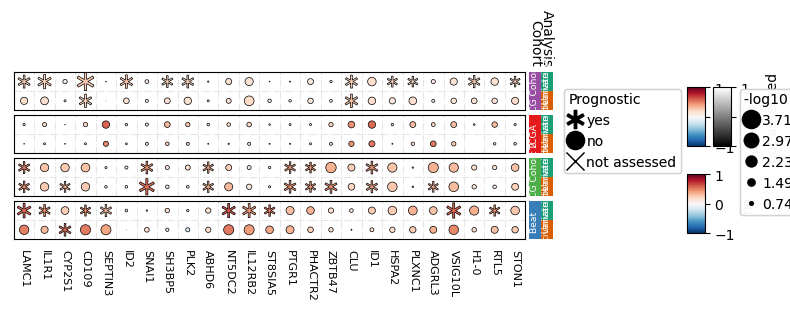


bad prognostic downregulated (drugs)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 300
Plotting legends..
Estimated legend width: 58.03333333333333 mm


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..
Incresing ncol


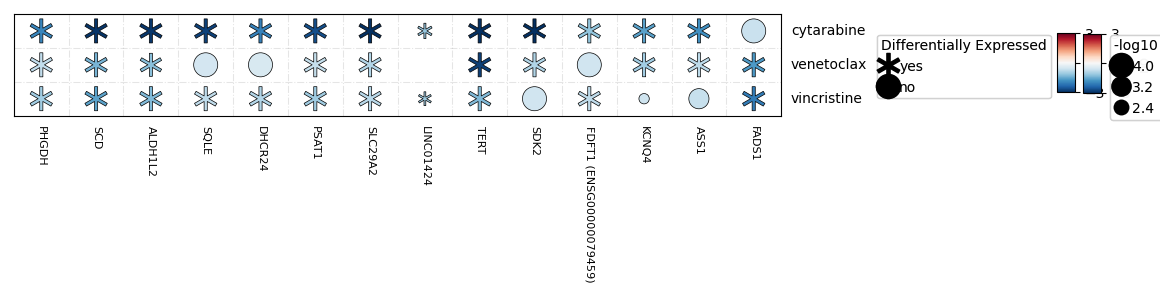


bad prognostic downregulated (cohorts)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 170


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Plotting legends..
Estimated legend width: 25.930555555555557 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


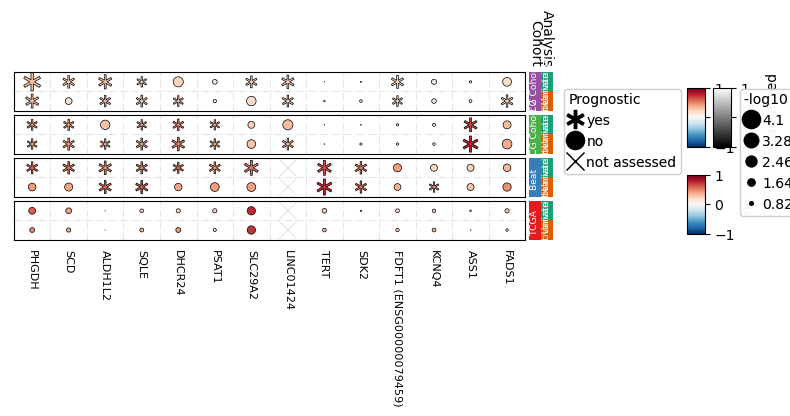


good prognostic upregulated (drugs)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 300
Plotting legends..
Estimated legend width: 58.03333333333333 mm


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..
Incresing ncol


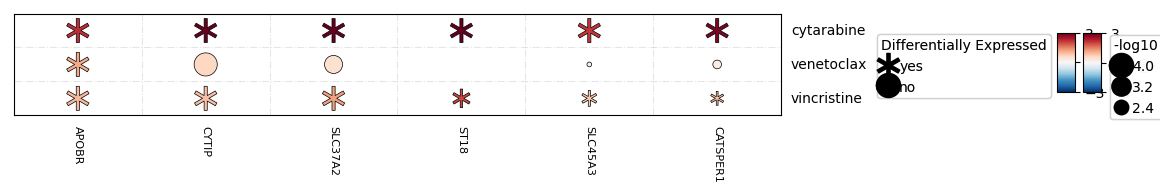


good prognostic upregulated (cohorts)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 170


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Plotting legends..
Estimated legend width: 25.930555555555557 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


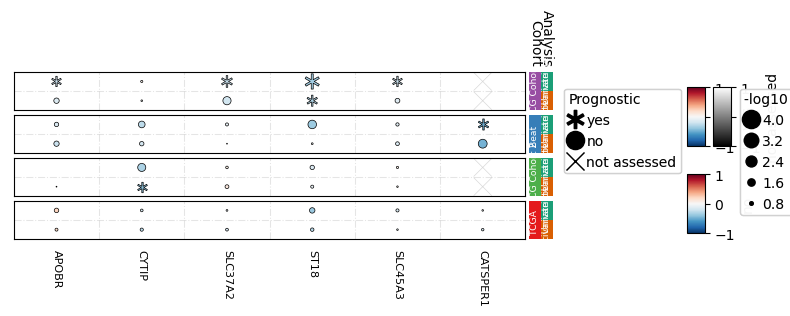


good prognostic downregulated (drugs)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 300
Plotting legends..
Estimated legend width: 58.03333333333333 mm


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..
Incresing ncol


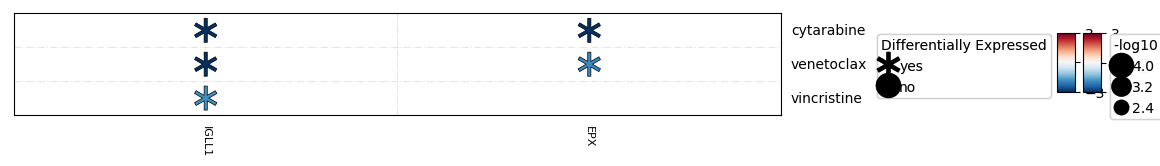


good prognostic downregulated (cohorts)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 170


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Plotting legends..
Estimated legend width: 25.930555555555557 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


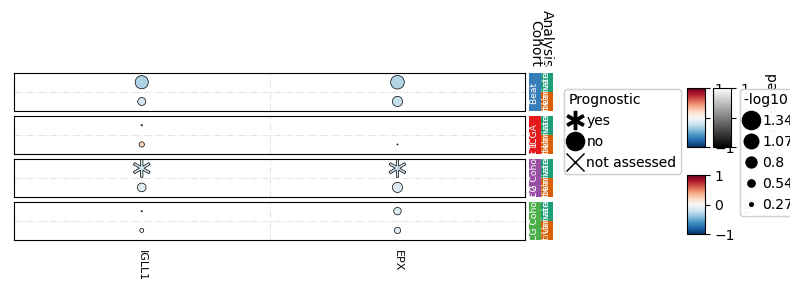

In [46]:
for key in gene_counts_dict.keys():
    df = gene_counts_dict[key].copy()
    gene_list = df[(df['unique_cohorts']>=1) & (df['unique_drugs']>=2)].index.to_list()
    
    gene_list_w_hgnc_info = [ensembl_to_hgnc_dict.get(x,x) for x in gene_list]
    gene_list_w_hgnc_info = [f"{ensembl_to_hgnc_non_unique_dict[x]} ({x})" if x in ensembl_to_hgnc_non_unique_dict else x for x in gene_list_w_hgnc_info]
    
    df1 = master_drug_info_dict['l2fc'].copy()
    df1 = df1[gene_list]
    df1 = df1.reset_index().melt(id_vars='index', var_name='Gene', value_name='Log 2 Fold Change')
    df1 = df1.rename(columns={'index': 'Drug'})
    df1
    
    df2 = master_drug_info_dict['neg_log_10_pval_bh_corrected'].copy()
    df2 = df2[gene_list]
    df2 = df2.reset_index().melt(id_vars='index', var_name='Gene', value_name='-log10 FDR')
    df2 = df2.rename(columns={'index': 'Drug'})
    df2
    
    df = pd.merge(df1,df2,on =['Drug','Gene'],how='inner')
    df['Gene'] = df['Gene'].apply(lambda x: ensembl_to_hgnc_dict.get(x,x))
    df['Gene'] = df['Gene'].apply(lambda x: f"{ensembl_to_hgnc_non_unique_dict[x]} ({x})" if x in ensembl_to_hgnc_non_unique_dict.keys() else x)
    df['-log10 FDR'] = df['-log10 FDR'].apply(lambda x: 4 if x>4 else x) #maximum size for FDR (for display purposes)
    df['Differentially Expressed'] = ((df['Log 2 Fold Change'].abs() > .7) & (df['-log10 FDR'] > 1.3010299566)).map({True: 'yes', False: 'no'})

    print('')
    print(key + ' (drugs)')
    print('')
    plt.figure(figsize=(10,1.25))
    cm = DotClustermapPlotter(df,x='Gene',y='Drug',value='Log 2 Fold Change', hue = 'Differentially Expressed',
                          s='-log10 FDR',c='Log 2 Fold Change',
                              cmap={'yes':'RdBu_r','no':'RdBu_r'},
                              linewidth=0.5,edgecolor='black',vmin =-3,vmax=3,alpha=1,
                             show_rownames=True,show_colnames=True,x_order= gene_list_w_hgnc_info,row_cluster = False,col_cluster=False,
                             max_s = 300,spines = True,marker={'yes':'$\\ast$','no':'o'},xticklabels_kws={'labelcolor':'black','labelsize':8},
                             rasterized = True)
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()
    
    df3 = master_cohort_info_dict['coef'].copy()
    df3 = df3[gene_list]
    df3 = df3.reset_index().melt(id_vars='index', var_name='Gene', value_name='log Hazard Ratio')
    df3 = df3.rename(columns={'index': 'Cohort and Analysis'})
    df3
    
    df4 = master_cohort_info_dict['neg_log_10_pval_bh_corrected'].copy()
    df4 = df4[gene_list]
    df4 = df4.reset_index().melt(id_vars='index', var_name='Gene', value_name='-log10 FDR')
    df4 = df4.rename(columns={'index': 'Cohort and Analysis'})
    df4
    
    df = pd.merge(df3,df4,on =['Cohort and Analysis','Gene'],how='inner')
    
    df['Gene'] = df['Gene'].apply(lambda x: ensembl_to_hgnc_dict.get(x,x))
    df['Gene'] = df['Gene'].apply(lambda x: f"{ensembl_to_hgnc_non_unique_dict[x]} ({x})" if x in ensembl_to_hgnc_non_unique_dict.keys() else x)
    
    annot_df = pd.DataFrame()
    annot_df['Cohort and Analysis'] = df['Cohort and Analysis']
    annot_df = annot_df.drop_duplicates()
    annot_df['Cohort'] = annot_df['Cohort and Analysis'].apply(lambda x: x.split('/')[0].strip(''))
    annot_df['Analysis'] = annot_df['Cohort and Analysis'].apply(lambda x: x.split('/')[1])
    annot_df.set_index(keys = 'Cohort and Analysis',drop = True,inplace= True)
    #display(annot_df.head(3))
    
    row_ha = HeatmapAnnotation(
                               Cohort=anno_simple(annot_df.Cohort,cmap='Set1',legend=False,add_text=True),
                               Analysis=anno_simple(annot_df.Analysis,cmap='Dark2',legend=False,add_text=True),
                               verbose=0,label_side='top',label_kws={'horizontalalignment':'right'},
                               axis = 0)
    
    #df['-log10 FDR'] = df['-log10 FDR'].apply(lambda x: 4 if x>4 else x) #maximum size for FDR
    df['Prognostic'] = np.where(
        df['-log10 FDR'].isna(), 
        'not assessed', 
        (df['-log10 FDR'] > 1.3010299566).map({True: 'yes', False: 'no'})
    )
    print('')
    print(key + ' (cohorts)')
    print('')
    plt.figure(figsize=(7,2))
    cm = DotClustermapPlotter(df,x='Gene',y='Cohort and Analysis',value='log Hazard Ratio', hue = 'Prognostic',
                              s='-log10 FDR',c='log Hazard Ratio',c_na=.7,s_na=4,
                              cmap={'yes':'RdBu_r','no':'RdBu_r','not assessed':'grey'},
                              linewidth=0.5,edgecolor='black',vmin =-1,vmax=1,
                             show_rownames=False,show_colnames=True,x_order= gene_list_w_hgnc_info,row_cluster = False,col_cluster=False,
                             max_s = 170,spines = True,marker={'yes':'$\\ast$','no':'o','not assessed':'x'},alpha = 1,row_split= annot_df.Cohort,
                            right_annotation=row_ha,row_split_gap = 1,xticklabels_kws={'labelcolor':'black','labelsize':8},rasterized = True
                             )
    
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()


bad prog upregulated - at least 2 drugs and 1 cohort (drugs)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 300
Plotting legends..
Estimated legend width: 58.03333333333333 mm


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..
Incresing ncol


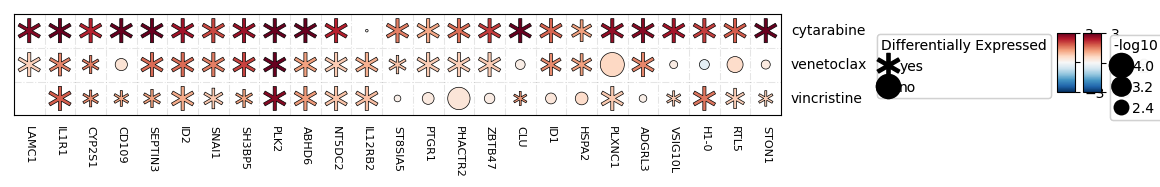


bad prog upregulated - at least 2 drugs and 1 cohort (cohorts)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Using user provided max_s: 170


C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:356: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:375: FutureWarning: The provided callable <function mean at 0x000001D49D8AD8A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\PyComplexHeatmap\dotHeatmap.py:391: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-se

Plotting legends..
Estimated legend width: 25.930555555555557 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


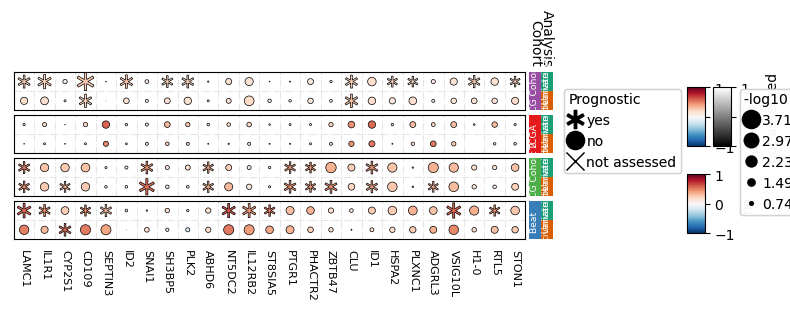

In [47]:

df = gene_counts_dict['bad prognostic upregulated'].copy()
gene_list = df[(df['unique_cohorts']>=1) & (df['unique_drugs']>=2)].index.to_list()

gene_list_w_hgnc_info = [ensembl_to_hgnc_dict.get(x,x) for x in gene_list]
gene_list_w_hgnc_info = [f"{ensembl_to_hgnc_non_unique_dict[x]} ({x})" if x in ensembl_to_hgnc_non_unique_dict else x for x in gene_list_w_hgnc_info]

df1 = master_drug_info_dict['l2fc'].copy()
df1 = df1[gene_list]
df1 = df1.reset_index().melt(id_vars='index', var_name='Gene', value_name='Log 2 Fold Change')
df1 = df1.rename(columns={'index': 'Drug'})
df1

df2 = master_drug_info_dict['neg_log_10_pval_bh_corrected'].copy()
df2 = df2[gene_list]
df2 = df2.reset_index().melt(id_vars='index', var_name='Gene', value_name='-log10 FDR')
df2 = df2.rename(columns={'index': 'Drug'})
df2

df = pd.merge(df1,df2,on =['Drug','Gene'],how='inner')
df['Gene'] = df['Gene'].apply(lambda x: ensembl_to_hgnc_dict.get(x,x))
df['Gene'] = df['Gene'].apply(lambda x: f"{ensembl_to_hgnc_non_unique_dict[x]} ({x})" if x in ensembl_to_hgnc_non_unique_dict.keys() else x)
df['-log10 FDR'] = df['-log10 FDR'].apply(lambda x: 4 if x>4 else x) #maximum size for FDR (for display purposes)
df['Differentially Expressed'] = ((df['Log 2 Fold Change'].abs() > .7) & (df['-log10 FDR'] > 1.3010299566)).map({True: 'yes', False: 'no'})

print('')
print('bad prog upregulated - at least 2 drugs and 1 cohort' + ' (drugs)')
print('')
plt.figure(figsize=(10,1.25))
cm = DotClustermapPlotter(df,x='Gene',y='Drug',value='Log 2 Fold Change', hue = 'Differentially Expressed',
                      s='-log10 FDR',c='Log 2 Fold Change',
                          cmap={'yes':'RdBu_r','no':'RdBu_r'},
                          linewidth=0.5,edgecolor='black',vmin =-3,vmax=3,alpha=1,
                         show_rownames=True,show_colnames=True,x_order= gene_list_w_hgnc_info,row_cluster = False,col_cluster=False,
                         max_s = 300,spines = True,marker={'yes':'$\\ast$','no':'o'},xticklabels_kws={'labelcolor':'black','labelsize':8},
                         rasterized = True)
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

df3 = master_cohort_info_dict['coef'].copy()
df3 = df3[gene_list]
df3 = df3.reset_index().melt(id_vars='index', var_name='Gene', value_name='log Hazard Ratio')
df3 = df3.rename(columns={'index': 'Cohort and Analysis'})
df3

df4 = master_cohort_info_dict['neg_log_10_pval_bh_corrected'].copy()
df4 = df4[gene_list]
df4 = df4.reset_index().melt(id_vars='index', var_name='Gene', value_name='-log10 FDR')
df4 = df4.rename(columns={'index': 'Cohort and Analysis'})
df4

df = pd.merge(df3,df4,on =['Cohort and Analysis','Gene'],how='inner')

df['Gene'] = df['Gene'].apply(lambda x: ensembl_to_hgnc_dict.get(x,x))
df['Gene'] = df['Gene'].apply(lambda x: f"{ensembl_to_hgnc_non_unique_dict[x]} ({x})" if x in ensembl_to_hgnc_non_unique_dict.keys() else x)

annot_df = pd.DataFrame()
annot_df['Cohort and Analysis'] = df['Cohort and Analysis']
annot_df = annot_df.drop_duplicates()
annot_df['Cohort'] = annot_df['Cohort and Analysis'].apply(lambda x: x.split('/')[0].strip(''))
annot_df['Analysis'] = annot_df['Cohort and Analysis'].apply(lambda x: x.split('/')[1])
annot_df.set_index(keys = 'Cohort and Analysis',drop = True,inplace= True)
#display(annot_df.head(3))

row_ha = HeatmapAnnotation(
                           Cohort=anno_simple(annot_df.Cohort,cmap='Set1',legend=False,add_text=True),
                           Analysis=anno_simple(annot_df.Analysis,cmap='Dark2',legend=False,add_text=True),
                           verbose=0,label_side='top',label_kws={'horizontalalignment':'right'},
                           axis = 0)

#df['-log10 FDR'] = df['-log10 FDR'].apply(lambda x: 4 if x>4 else x) #maximum size for FDR
df['Prognostic'] = np.where(
    df['-log10 FDR'].isna(), 
    'not assessed', 
    (df['-log10 FDR'] > 1.3010299566).map({True: 'yes', False: 'no'})
)
print('')
print('bad prog upregulated - at least 2 drugs and 1 cohort' + ' (cohorts)')
print('')
plt.figure(figsize=(7,2))
cm = DotClustermapPlotter(df,x='Gene',y='Cohort and Analysis',value='log Hazard Ratio', hue = 'Prognostic',
                          s='-log10 FDR',c='log Hazard Ratio',c_na=.7,s_na=4,
                          cmap={'yes':'RdBu_r','no':'RdBu_r','not assessed':'grey'},
                          linewidth=0.5,edgecolor='black',vmin =-1,vmax=1,
                         show_rownames=False,show_colnames=True,x_order= gene_list_w_hgnc_info,row_cluster = False,col_cluster=False,
                         max_s = 170,spines = True,marker={'yes':'$\\ast$','no':'o','not assessed':'x'},alpha = 1,row_split= annot_df.Cohort,
                        right_annotation=row_ha,row_split_gap = 1,xticklabels_kws={'labelcolor':'black','labelsize':8},rasterized = True
                         )

plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

In [48]:
#Can Copy Paste this into CHea3 TF inference and ENRICHR network analysis
for x in gene_list:
    print(ensembl_to_hgnc_dict.get(x,x))

LAMC1
IL1R1
CYP2S1
CD109
SEPTIN3
ID2
SNAI1
SH3BP5
PLK2
ABHD6
NT5DC2
IL12RB2
ST8SIA5
PTGR1
PHACTR2
ZBTB47
CLU
ID1
HSPA2
PLXNC1
ADGRL3
VSIG10L
H1-0
RTL5
STON1


storing genes that were de and prog in excel file

In [49]:
export_to_excel_dict ={}
for assoc_key in gene_counts_dict.keys():
    gene_list = gene_counts_dict[assoc_key].index.to_list()
    
    keys_list = ['AMLCG Cohort 1 / Univariate',
                 'AMLCG Cohort 1 / Multivariate',
                'AMLCG Cohort 2 / Univariate',
                'AMLCG Cohort 2 / Multivariate',
                 'Beat / Univariate',
                 'Beat / Multivariate',
                 'TCGA / Univariate',
                 'TCGA / Multivariate']
    
    dfs = []
    for key,bulk_df in bulk_de_tables_dict.items():
        df=bulk_df.copy()
        df=df.rename(columns = {'pval_bh_corrected':'FDR'})
        df=df.drop(columns = 'p')
        df.columns = df.columns +' '+ str.split(key,sep='(')[0]
        dfs.append(df)
        #display(df)
    df = pd.concat(dfs,axis=1)
    df = df[df.index.isin(gene_list)]
    bulk_df = df.copy()
    
    prognosis_dfs = []
    for key in keys_list:
        df = cox_ph_fit_dict[key]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
        df = df[['coef','pval_bh_corrected']]
        df = df.rename(columns = {'coef':'natural log (hazard ratio)','pval_bh_corrected':'FDR'})
        df= df[['natural log (hazard ratio)','FDR']]
        df=df[df.index.isin(gene_list)]
        df.columns = df.columns +' '+ str.split(key,sep=' ')[0] + ' ' + str.split(key,sep=' ')[-1] 
        prognosis_dfs.append(df)
    df = pd.concat(prognosis_dfs,axis=1)
    df = df[df.index.isin(gene_list)]
    prognosis_df = df.copy()
    prognosis_df
    
    df= pd.concat([bulk_df,prognosis_df],axis=1)
    
    df = df.reset_index(names = 'ENSG')
    df.insert(loc=1,column = 'HGNC',value = None)
    df['HGNC'] = df['ENSG'].apply(lambda x :ensembl_to_hgnc_non_unique_dict.get(x,None))

    assoc_key= assoc_key.replace('bad','poor')
    assoc_key= assoc_key.replace('good','favorable')
    assoc_key= assoc_key.replace('upregulated','up')
    assoc_key= assoc_key.replace('downregulated','down')
    
    export_to_excel_dict[assoc_key] = df

In [50]:
with pd.ExcelWriter(r'..\results\prog_and_de_table.xlsx', engine="xlsxwriter") as writer:
    for sheet_name, df in export_to_excel_dict.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

# Enrichment stability analysis

### Creation of 3x3 contingency tables at FDR = .05 for analysis in R (saving to desktop)

In [51]:
cont_tables_dict = {}

results_dict_lineplots = {}
results_dict_grids = {}

alphas = [.05]
for covariate in ['univariate','multivariate']:
    results_df_lineplot = pd.DataFrame(index=alphas, columns=['up/bad', 'down/bad', 'up/good', 'down/good'])
    results_df_lineplot = results_df_lineplot.fillna(0)
    results_dict_grids[covariate] = {}
    results_dict_grids[covariate]['list'] = []
    
    for alpha in alphas:  
        if covariate == 'univariate':
            acceptable_cohort_keys = [x for x in cox_ph_fit_dict.keys() if 'Univariate' in x]
        elif covariate == 'multivariate':
            acceptable_cohort_keys = [x for x in cox_ph_fit_dict.keys() if 'Multivariate' in x]
        results_dict_grids[covariate]['acceptable_cohort_keys'] = acceptable_cohort_keys
        #print(covariate)
        #print(acceptable_cohort_keys)
        # Cycle through dicts and get relevant genes
        for drug_key in bulk_de_tables_dict.keys():
            df = bulk_de_tables_dict[drug_key].copy()
            total1= len(df) #for sanity check exception raising at bottom of loop
            not_de_genes = set(df[(df['pval_bh_corrected'] >= alpha) | (df['l2fc'].abs() <= 0.7)| (df['pval_bh_corrected'].isna()) | (df['l2fc'].isna())].index)
            df = df[df['pval_bh_corrected'] < alpha]
            up_genes = set(df[df['l2fc'] > .7].index)
            down_genes = set(df[df['l2fc'] < -.7].index)
            total2 = len(not_de_genes)+len(up_genes)+len(down_genes)
            if total1 != total2:
                raise Exception('DE gene partitions not adding up')
            
            for cohort_key in cox_ph_fit_dict.keys():
                if cohort_key in acceptable_cohort_keys:
                    df = cox_ph_fit_dict[cohort_key]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
                    total1 = len(df) #for sanity checking
                    not_prog_genes = set(df[(df['pval_bh_corrected'] >= alpha) | (df['coef'] == 0) | (df['coef'].isna()) | (df['pval_bh_corrected']).isna()].index)
                    df = df[df['pval_bh_corrected'] < alpha]
                    bad_genes = set(df[df['coef'] > 0].index)
                    good_genes = set(df[df['coef'] < 0].index)
                    total2 = len(not_prog_genes)+len(bad_genes)+len(good_genes)
                    if total1 != total2:
                        raise Exception('prog gene partitions not adding up')

                    # Only do enrichment analysis on genes that have significant prognostic or DE value
                    de_genes_assessed = up_genes.union(down_genes.union(not_de_genes))
                    prog_genes_assessed = bad_genes.union(good_genes.union(not_prog_genes))
                    sample_space = de_genes_assessed.intersection(prog_genes_assessed)
   
                    # Create intersections without modifying the original sets
                    up_bad_intersection = up_genes.intersection(bad_genes).intersection(sample_space)
                    notde_bad_intersection = not_de_genes.intersection(bad_genes).intersection(sample_space) #v
                    down_bad_intersection = down_genes.intersection(bad_genes).intersection(sample_space)
                    
                    up_notprog_intersection =up_genes.intersection(not_prog_genes).intersection(sample_space) #w
                    notde_notprog_intersection =not_de_genes.intersection(not_prog_genes).intersection(sample_space) #x
                    down_notprog_intersection =down_genes.intersection(not_prog_genes).intersection(sample_space) #y
                    
                    up_good_intersection = up_genes.intersection(good_genes).intersection(sample_space)
                    notde_good_intersection = not_de_genes.intersection(good_genes).intersection(sample_space) #z
                    down_good_intersection = down_genes.intersection(good_genes).intersection(sample_space)
                    

                    a = len(up_bad_intersection)
                    b = len(down_bad_intersection)
                    c = len(up_good_intersection)
                    d = len(down_good_intersection)

                    v = len(notde_bad_intersection)
                    w = len(up_notprog_intersection)
                    x = len(notde_notprog_intersection)
                    y = len(down_notprog_intersection)
                    z = len(notde_good_intersection)
                    
                    df = pd.DataFrame(index = ['bad','not_prog','good'],columns = ['up','not_de','down'],data = [[a,v,b],[w,x,y],[c,z,d]])
                    key_name = f'{alpha}_{drug_key}_{cohort_key}'
                    key_name = key_name.replace(' ','')
                    key_name = key_name.replace('/','_')
                    cont_tables_dict[key_name] = df.copy()
                    

C:\Users\andre\AppData\Local\Temp\ipykernel_764\296472136.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df_lineplot = results_df_lineplot.fillna(0)
C:\Users\andre\AppData\Local\Temp\ipykernel_764\296472136.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df_lineplot = results_df_lineplot.fillna(0)


In [52]:
# Create the folder if it doesn't exist
path = r'..\intermediate_file_outputs\3x3_tables_for_R'
os.makedirs(path,exist_ok=True)

# Loop through the dictionary and save each DataFrame as a CSV file
for table_name, df in cont_tables_dict.items():
    full_path = os.path.join(path, f"{table_name}.csv")
    df.to_csv(full_path)
    print(f"Saved {table_name}")

Saved 0.05_cytarabine_AMLCGCohort1_Univariate
Saved 0.05_cytarabine_AMLCGCohort2_Univariate
Saved 0.05_cytarabine_Beat_Univariate
Saved 0.05_cytarabine_TCGA_Univariate
Saved 0.05_vincristine_AMLCGCohort1_Univariate
Saved 0.05_vincristine_AMLCGCohort2_Univariate
Saved 0.05_vincristine_Beat_Univariate
Saved 0.05_vincristine_TCGA_Univariate
Saved 0.05_venetoclax_AMLCGCohort1_Univariate
Saved 0.05_venetoclax_AMLCGCohort2_Univariate
Saved 0.05_venetoclax_Beat_Univariate
Saved 0.05_venetoclax_TCGA_Univariate
Saved 0.05_cytarabine_AMLCGCohort1_Multivariate
Saved 0.05_cytarabine_AMLCGCohort2_Multivariate
Saved 0.05_cytarabine_Beat_Multivariate
Saved 0.05_cytarabine_TCGA_Multivariate
Saved 0.05_vincristine_AMLCGCohort1_Multivariate
Saved 0.05_vincristine_AMLCGCohort2_Multivariate
Saved 0.05_vincristine_Beat_Multivariate
Saved 0.05_vincristine_TCGA_Multivariate
Saved 0.05_venetoclax_AMLCGCohort1_Multivariate
Saved 0.05_venetoclax_AMLCGCohort2_Multivariate
Saved 0.05_venetoclax_Beat_Multivariate


In [53]:
#the above 3x3 tables should be analyzed with an R script, the following is fisher's exact for 2x2 tables

## Fisher's Exact Test (for a range of FDR cutoffs)

computing univariate  0.01


C:\Users\andre\AppData\Local\Temp\ipykernel_764\1787255618.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df_lineplot = results_df_lineplot.fillna(0)


0.449  seconds elapsed
computing univariate  0.02
0.393  seconds elapsed
computing univariate  0.03
0.472  seconds elapsed
computing univariate  0.04
0.525  seconds elapsed
computing univariate  0.05
0.511  seconds elapsed
computing univariate  0.06
0.493  seconds elapsed
computing univariate  0.07
0.502  seconds elapsed
computing univariate  0.08
0.518  seconds elapsed
computing univariate  0.09
0.509  seconds elapsed
computing univariate  0.1
0.495  seconds elapsed
computing multivariate  0.01


C:\Users\andre\AppData\Local\Temp\ipykernel_764\1787255618.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df_lineplot = results_df_lineplot.fillna(0)


0.489  seconds elapsed
computing multivariate  0.02
0.496  seconds elapsed
computing multivariate  0.03
0.49  seconds elapsed
computing multivariate  0.04
0.503  seconds elapsed
computing multivariate  0.05
0.489  seconds elapsed
computing multivariate  0.06
0.503  seconds elapsed
computing multivariate  0.07
0.488  seconds elapsed
computing multivariate  0.08
0.506  seconds elapsed
computing multivariate  0.09
0.517  seconds elapsed
computing multivariate  0.1
0.512  seconds elapsed


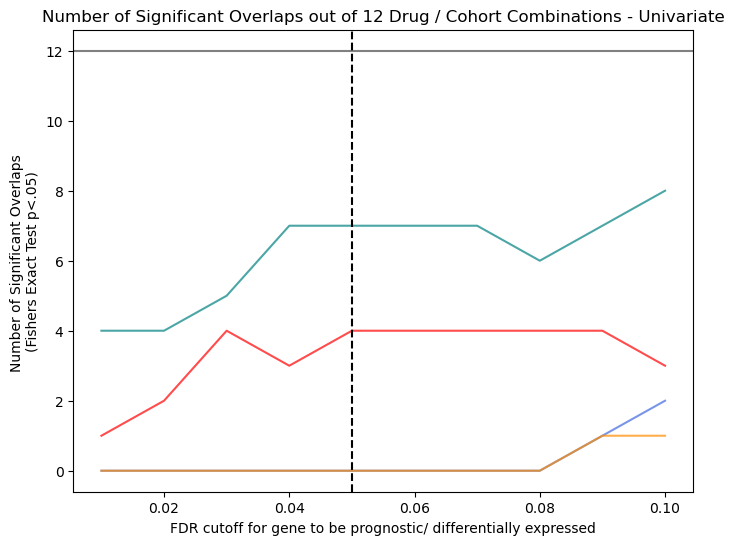

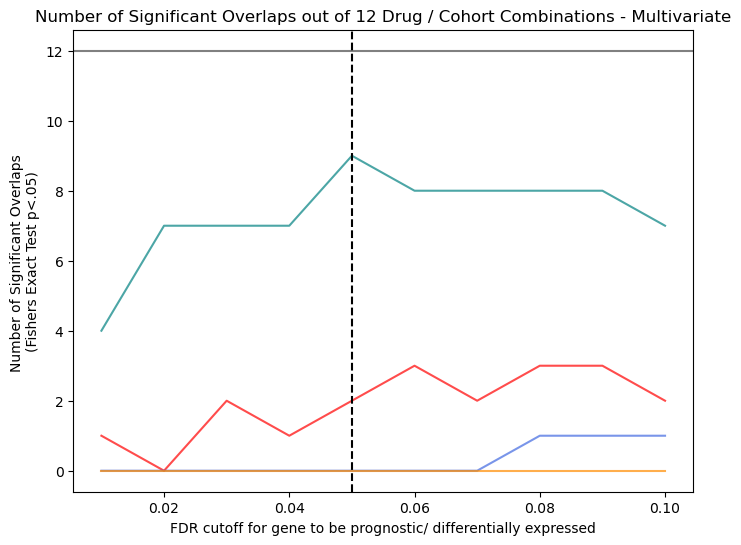

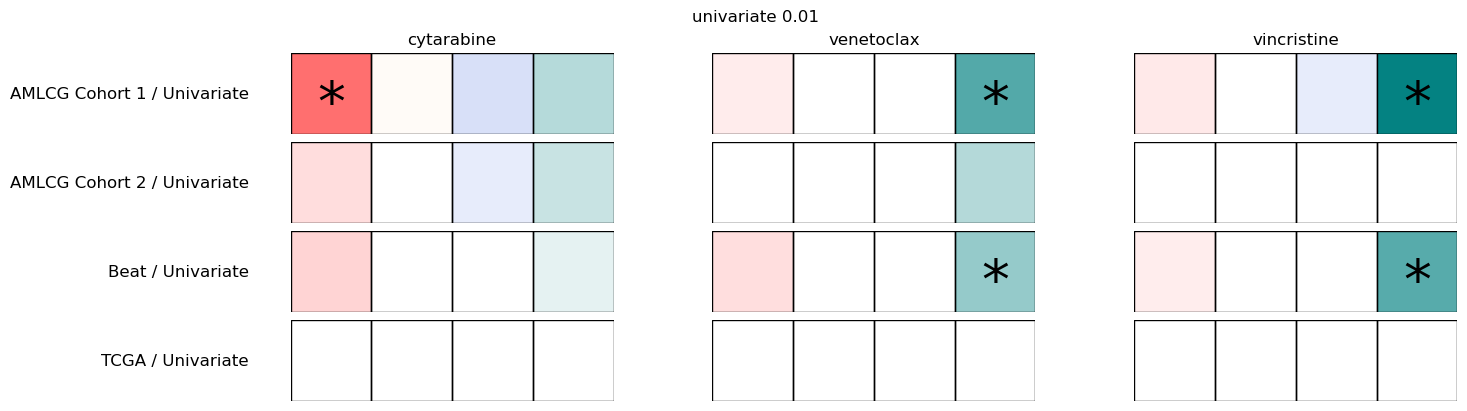

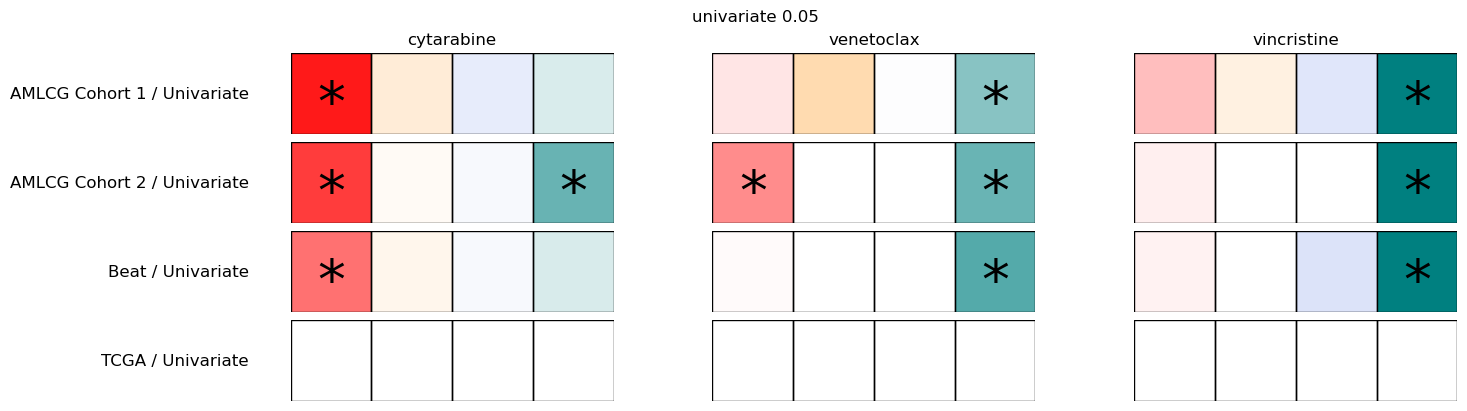

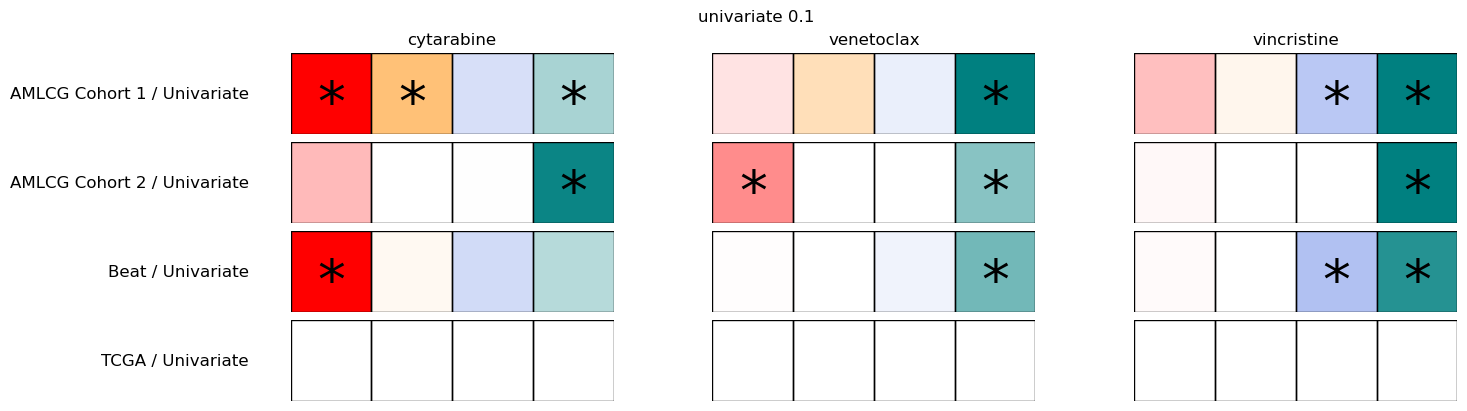

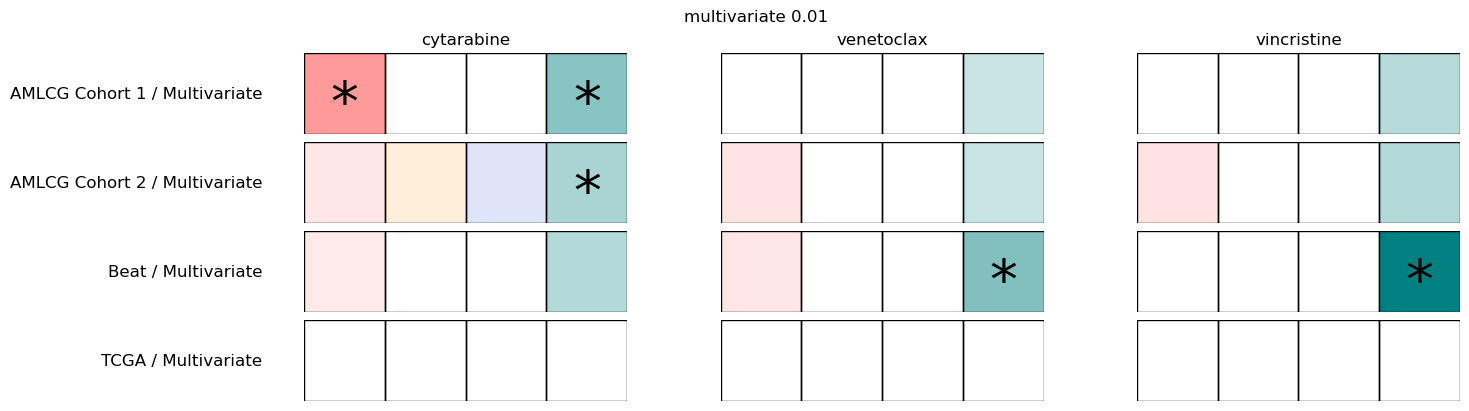

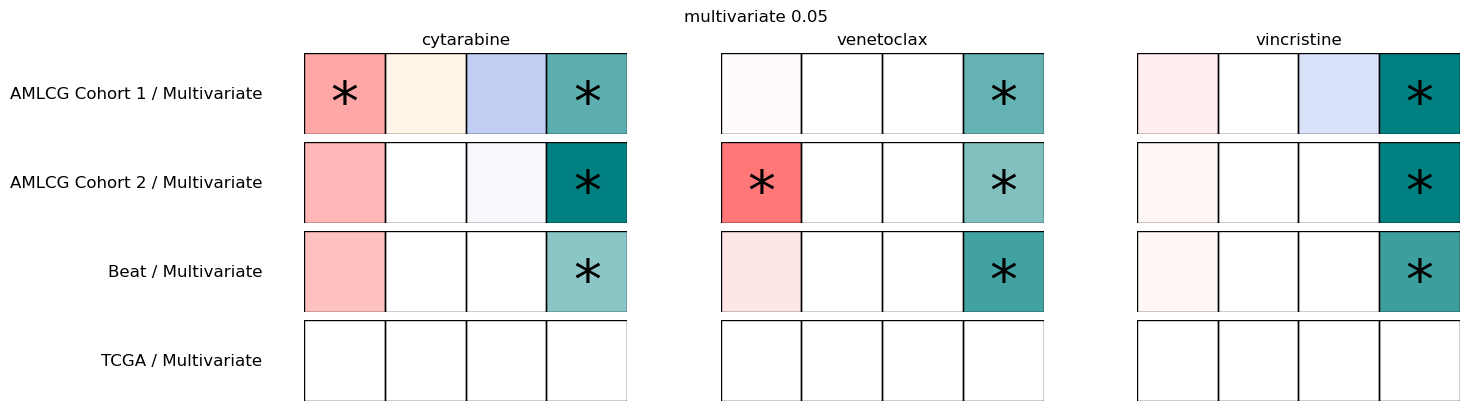

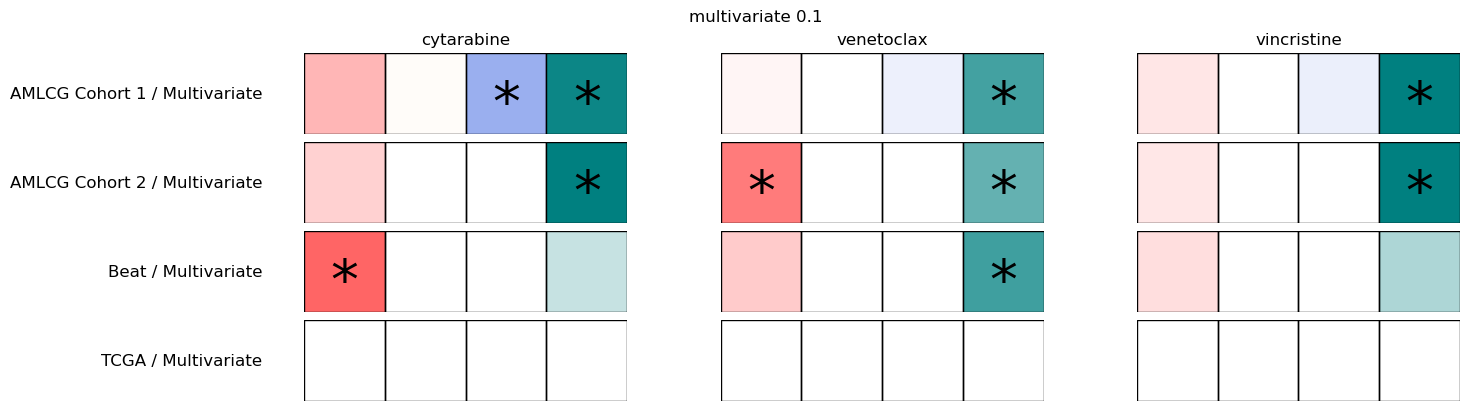

In [54]:
#calculating and storing

results_dict_lineplots = {}
results_dict_grids = {}

alphas = list(np.linspace(0.01,.1,10))
alphas = [round(x,5) for x in alphas]

for covariate in ['univariate','multivariate']:
    results_df_lineplot = pd.DataFrame(index=alphas, columns=['up/bad', 'down/bad', 'up/good', 'down/good'])
    results_df_lineplot = results_df_lineplot.fillna(0)
    results_dict_grids[covariate] = {}
    results_dict_grids[covariate] = {'list': {alpha: [] for alpha in alphas}}
    
    for alpha in alphas:  
        start_time = time.time()
        print('computing',covariate,'',alpha)
        if covariate == 'univariate':
            acceptable_cohort_keys = [x for x in cox_ph_fit_dict.keys() if 'Univariate' in x]
        elif covariate == 'multivariate':
            acceptable_cohort_keys = [x for x in cox_ph_fit_dict.keys() if 'Multivariate' in x]
        results_dict_grids[covariate]['acceptable_cohort_keys'] = acceptable_cohort_keys

        # Cycle through dicts and get relevant genes
        for drug_key in bulk_de_tables_dict.keys():
            df = bulk_de_tables_dict[drug_key].copy()
            total1= len(df) #for sanity check exception raising at bottom of loop
            not_de_genes = set(df[(df['pval_bh_corrected'] >= alpha) | (df['l2fc'].abs() <= 0.7)| (df['pval_bh_corrected'].isna()) | (df['l2fc'].isna())].index)
            df = df[df['pval_bh_corrected'] < alpha]
            up_genes = set(df[df['l2fc'] > .7].index)
            down_genes = set(df[df['l2fc'] < -.7].index)
            total2 = len(not_de_genes)+len(up_genes)+len(down_genes)
            if total1 != total2:
                raise Exception('DE gene partitions not adding up')
            
            for cohort_key in cox_ph_fit_dict.keys():
                if cohort_key in acceptable_cohort_keys:
                    df = cox_ph_fit_dict[cohort_key]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
                    total1 = len(df) #for sanity checking
                    not_prog_genes = set(df[(df['pval_bh_corrected'] >= alpha) | (df['coef'] == 0) | (df['coef'].isna()) | (df['pval_bh_corrected']).isna()].index)
                    df = df[df['pval_bh_corrected'] < alpha]
                    bad_genes = set(df[df['coef'] > 0].index)
                    good_genes = set(df[df['coef'] < 0].index)
                    total2 = len(not_prog_genes)+len(bad_genes)+len(good_genes)
                    if total1 != total2:
                        raise Exception('prog gene partitions not adding up')

                    # Only do enrichment analysis on genes actually measured in both disjoint analyses
                    de_genes_assessed = up_genes.union(down_genes.union(not_de_genes))
                    prog_genes_assessed = bad_genes.union(good_genes.union(not_prog_genes))
                    sample_space = de_genes_assessed.intersection(prog_genes_assessed)
   
                    # Create intersections without modifying the original sets
                    up_bad_intersection = up_genes.intersection(bad_genes).intersection(sample_space)
                    notde_bad_intersection = not_de_genes.intersection(bad_genes).intersection(sample_space) #v
                    down_bad_intersection = down_genes.intersection(bad_genes).intersection(sample_space)
                    
                    up_notprog_intersection =up_genes.intersection(not_prog_genes).intersection(sample_space) #w
                    notde_notprog_intersection =not_de_genes.intersection(not_prog_genes).intersection(sample_space) #x
                    down_notprog_intersection =down_genes.intersection(not_prog_genes).intersection(sample_space) #y
                    
                    up_good_intersection = up_genes.intersection(good_genes).intersection(sample_space)
                    notde_good_intersection = not_de_genes.intersection(good_genes).intersection(sample_space) #z
                    down_good_intersection = down_genes.intersection(good_genes).intersection(sample_space)
                    

                    a = len(up_bad_intersection)
                    b = len(down_bad_intersection)
                    c = len(up_good_intersection)
                    d = len(down_good_intersection)

                    v = len(notde_bad_intersection)
                    w = len(up_notprog_intersection)
                    x = len(notde_notprog_intersection)
                    y = len(down_notprog_intersection)
                    z = len(notde_good_intersection)
                    
                    #checking enrichment for every possibility
                    fishers_test_trials =[['up/bad',[[a,b+v],[c+w,d+x+y+z]]],['up/good',[[c,d+z],[a+w,b+x+y+v]]],['down/bad',[[b,a+v],[d+y,c+x+w+z]]],['down/good',[[d,c+z],[b+y,a+w+x+v]]]]
                    
                    for item in fishers_test_trials:
                        title = item[0]
                        order = item[1]
                        res = fisher_exact(order,alternative = 'greater')
                        pval = res.pvalue
                        
                        results_dict_grids[covariate]['list'][alpha].append([cohort_key,drug_key,title,pval])

                        if pval <.05: 
                            results_df_lineplot.at[alpha,title] += 1
        end_time = time.time()
        print(round((end_time - start_time),3), ' seconds elapsed')
    results_dict_lineplots[covariate] = results_df_lineplot

#---------------------------------------------------------------------
#plotting

total_assessments = len(bulk_de_tables_dict.keys())*4 #because there are 4 cohorts
for key in results_dict_lineplots.keys():
    df = results_dict_lineplots[key].copy()
    
    colors = ['red', 'teal', 'royalblue', 'darkorange']
    linestyles = ['-', '-', '-', '-']
    
    # Plot each column with specified color and linestyle
    plt.figure(figsize=(8, 6))
    for i, column in enumerate(df.columns):
        sns.lineplot(
            x=df.index, 
            y=df[column], 
            label=column, 
            color=colors[i], 
            linestyle=linestyles[i],
            alpha=.7
        )
    
    #plt.legend(title="Enrichment \n(Differential Expression / Prognosis)")
    plt.legend().set_visible(False) 
    plt.xlabel("FDR cutoff for gene to be prognostic/ differentially expressed")
    plt.ylabel(f'Number of Significant Overlaps \n(Fishers Exact Test p<.05)')
    plt.axhline(total_assessments,color ='grey',linestyle='solid')
    plt.axvline(.05,color ='black',linestyle = '--')
    plt.title(f'Number of Significant Overlaps out of {total_assessments} Drug / Cohort Combinations - {key.title()}')
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg'  + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()


for key in results_dict_grids.keys():
    for alpha in [.01,.05,.1]:
        subgrid_data = results_dict_grids[key]['list'][alpha].copy()
        acceptable_cohort_keys = results_dict_grids[key]['acceptable_cohort_keys'].copy()
    
        # Define the main grid labels
        columns = [drug_key for drug_key in sorted(bulk_de_tables_dict.keys())]
        rows = [cohort_key for cohort_key in acceptable_cohort_keys]
        
        # Define colors for each subgrid cell
        colors = {
            "up/bad": 'red',       # First (leftmost)
            "down/bad": 'teal',     # Second
            "up/good": 'royalblue',  # Third
            "down/good": 'darkorange'     # Fourth (rightmost)
        }
        
        # Create a dictionary to store the intensity values
        intensity_dict = { (row, col, quadrant): intensity for row, col, quadrant, intensity in subgrid_data }
        
        # Determine figure size dynamically to maintain square cells
    
        fig_width = 15
        fig_height = 4
        
        # Create the figure and axes grid
        fig, ax = plt.subplots(len(rows), len(columns), figsize=(fig_width, fig_height), constrained_layout=True)
        fig.suptitle(key +' ' +str(alpha))
    
        # Ensure ax is always a 2D array
        if len(rows) == 1 and len(columns) == 1:
            ax = [[ax]]
        elif len(rows) == 1:
            ax = [ax]
        elif len(columns) == 1:
            ax = [[a] for a in ax]
    
        # Loop over each cell in the main grid
        for i, row_label in enumerate(rows):
            for j, col_label in enumerate(columns):
                # Loop through the four categories for each cell, now in a 1×4 layout
                for quadrant, n in zip(["up/bad", "down/good", "up/good", "down/bad"], range(4)):
                    # Get the intensity for the specific (row, col, quadrant)
                    intensity = intensity_dict.get((row_label, col_label, quadrant), 1)
                    pval = intensity
                    
                    color = colors[quadrant]
                    
                    if intensity <1e-4:
                        intensity = 1e-4
    
                    intensity = -np.log10(intensity)
                    intensity = intensity/4
                    
                    # Add the colored subgrid rectangle (1 row, 4 columns)
                    ax[i][j].add_patch(plt.Rectangle((n * 0.25, 0), 0.25, 1, facecolor=color, alpha= intensity ))
                    ax[i][j].add_patch(plt.Rectangle((n * 0.25, 0), 0.25, 1, facecolor='none', edgecolor='black'))
    
                    # Add an "X" if intensity is below 0.05
                    if pval < 0.05:
                        ax[i][j].text(n * 0.25 + 0.125, 0.35, "*", ha='center', va='center', fontsize=40, color='black')
 
                # Ensure each subgrid is perfectly square
                ax[i][j].set_xlim(0, 1)
                ax[i][j].set_ylim(0, 1)
                ax[i][j].set_aspect(.25)  # Keep the main grid square
                
                # Remove ticks and labels for a clean look
                ax[i][j].set_xticks([])
                ax[i][j].set_yticks([])
                ax[i][j].spines[:].set_visible(False)
        
        # Set the row and column labels for the heatmap
        for i, row_label in enumerate(rows):
            ax[i][0].set_ylabel(row_label, rotation=0, size='large', labelpad=30, ha='right', va='center')
        for j, col_label in enumerate(columns):
            ax[0][j].set_title(col_label, size='large')
    
        # Save and display
        plt.savefig(r'..\results\figure_outputs_poor_prog_upreg'  + '\\' + str(time.time()) + '_figure.svg', format="svg")
        plt.show()

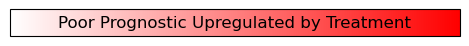

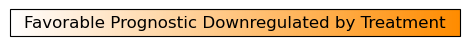

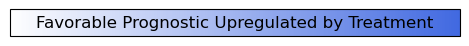

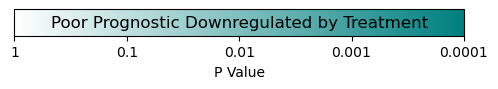

In [55]:
# Retrieve the color 'red' from Matplotlib's color dictionary
text_dict= {
        "red":"Poor Prognostic Upregulated by Treatment", 
        "darkorange": 'Favorable Prognostic Downregulated by Treatment', # First (leftmost)
        "teal": 'Poor Prognostic Downregulated by Treatment',     # Second
        "royalblue": 'Favorable Prognostic Upregulated by Treatment',  # Third
    }
for bc in ['red','darkorange','royalblue','teal']:
    base_color = mcolors.CSS4_COLORS[bc]
    
    # Create a colormap with different alpha values
    alpha_values = np.linspace(0, 1, 256)
    colors = [(mcolors.to_rgba(base_color, alpha=a)) for a in alpha_values]
    
    # Create a colormap and a normalization function
    cmap = mcolors.LinearSegmentedColormap.from_list("red_alpha", colors)
    norm = mcolors.Normalize(vmin=0, vmax=4)
    
    # Create the figure and colorbar
    fig, ax = plt.subplots(figsize=(5.8, .7))
    fig.subplots_adjust(bottom=0.5)
    
    cb = plt.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=cmap),
            cax=ax,
            orientation='horizontal',
            ticks=None
        )
    if bc != 'teal':  
        cb.set_ticks([])

    if bc == 'teal':  
        cb.set_label(f"P Value")
        ticks = [0,1,2,3,4]
        cb.set_ticks(ticks)
        cb.set_ticklabels([10**-x for x in ticks])
    ax.text(0.5, 0.5, text_dict[bc], 
            color='black', fontsize=12, 
            ha='center', va='center', transform=ax.transAxes)
    
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()

# Figure showing which drugs were taken in each cohort

In [56]:
beat_patients_assessed= cox_fit_ready_df_dict['Beat / Univariate'].index.to_list()
tcga_patients_assessed= cox_fit_ready_df_dict['TCGA / Univariate'].index.to_list()

In [57]:
beat= pd.read_excel(r'..\data\cohort_data\beat\beataml_wv1to4_clinical.xlsx',sheet_name = 'summary')
beat = beat[beat['dbgap_rnaseq_sample'].isin(beat_patients_assessed)]

tcga = pd.read_excel(r'..\data\cohort_data\tcga\TCGA_NEJM_clinical(updated).xlsx')
tcga = tcga.iloc[0:200] #getting rid of empty final row that gets read in 
tcga['TCGA Patient ID'] =tcga['TCGA Patient ID'].astype(int)
tcga['TCGA Patient ID'] =tcga['TCGA Patient ID'].astype(str)
tcga = tcga[tcga['TCGA Patient ID'].apply(lambda x: any(x in full_id for full_id in tcga_patients_assessed))]

C:\Users\andre\anaconda3\envs\bpu_attempt3\Lib\site-packages\openpyxl\worksheet\_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [58]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    print(beat['cumulativeTreatmentRegimens'].value_counts())
print(tcga['Induction'].value_counts())

cumulativeTreatmentRegimens
7+3 (Cytarabine, Idarubicin)|HiDAC                                                                                                                                                                                26
7+3 (Cytarabine, Idarubicin)                                                                                                                                                                                      21
Venetoclax (ABT-199), Azacitidine                                                                                                                                                                                  7
Decitabine                                                                                                                                                                                                         7
7+3 (Cytarabine, Idarubicin)|MiDAC                                                                                      

In [59]:
beat_cyt_only = (len(beat[beat['cumulativeTreatmentRegimens'].str.contains('Cyt')& ~beat['cumulativeTreatmentRegimens'].str.contains('Ven')])) #cyt only
beat_ven_only = (len(beat[~beat['cumulativeTreatmentRegimens'].str.contains('Cyt')& beat['cumulativeTreatmentRegimens'].str.contains('Ven')])) # ven only
beat_cyt_and_ven = (len(beat[beat['cumulativeTreatmentRegimens'].str.contains('Cyt')& beat['cumulativeTreatmentRegimens'].str.contains('Ven')])) # both
beat_total = (len(beat))

print([beat_cyt_only,beat_ven_only,beat_cyt_and_ven,beat_total])

[107, 7, 2, 141]


In [60]:
tcga_cyt_only = (len(tcga[tcga['Induction'].str.contains('7')])) # 7 as in 7 +3 or 7+ 3+3 indicates cytarabine was used
tcga_total = (len(tcga))

print([tcga_cyt_only,tcga_total])

[39, 58]


In [61]:
def absolute_value(val):
    total = sum(sizes)
    return f'{int(round(val * total / 100.0))}'

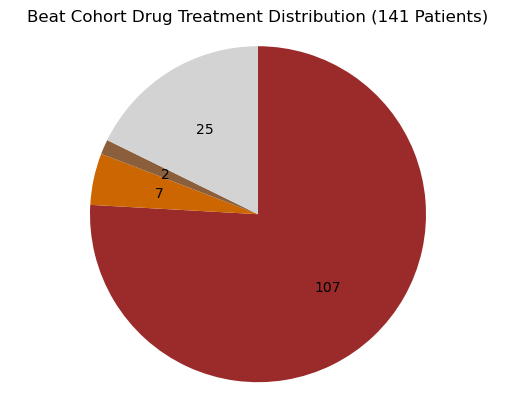

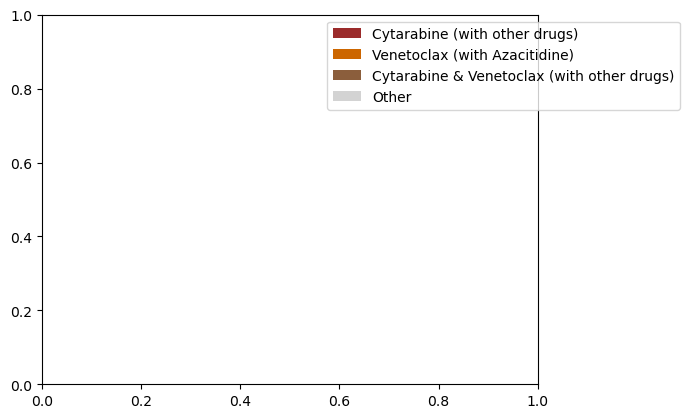

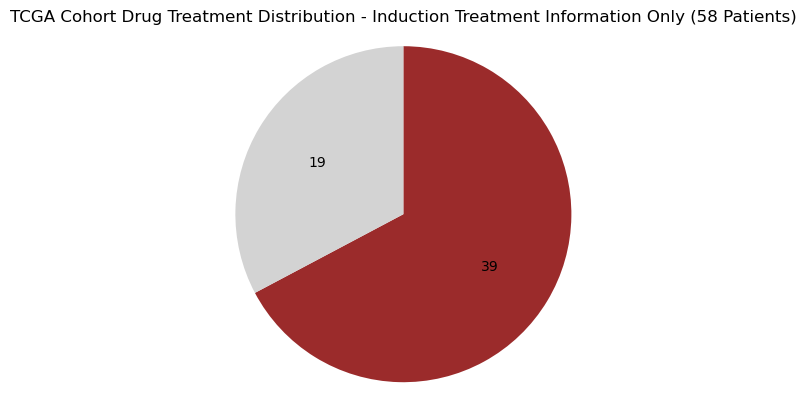

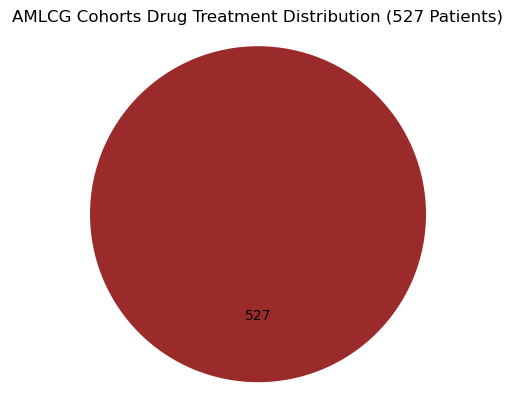

In [62]:
#beat
labels = ['Cytarabine (with other drugs)', 'Venetoclax (with Azacitidine)', 'Cytarabine & Venetoclax (with other drugs)', 'Other']
sizes = [beat_cyt_only, beat_ven_only, beat_cyt_and_ven, (beat_total-beat_cyt_only-beat_ven_only-beat_cyt_and_ven)]

colors = ['#9B2B2B', '#CC6600', '#8B5E3C', '#D3D3D3']

plt.pie(sizes, labels=None, colors=colors, startangle=90, counterclock=False,autopct = absolute_value)
plt.axis('equal')  # Ensures pie is a circle
plt.title('Beat Cohort Drug Treatment Distribution (141 Patients)')
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

legend_elements = [Patch(facecolor=colors[i], label=labels[i]) for i in range(len(labels))]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

#tcga
labels = ['Cytarabine (with other drugs)', 'Other']
sizes = [tcga_cyt_only, tcga_total-tcga_cyt_only]  

colors = ['#9B2B2B', '#D3D3D3']

plt.pie(sizes, labels=None, colors=colors, startangle=90, counterclock=False,autopct = absolute_value)
plt.axis('equal')  # Ensures pie is a circle
plt.title('TCGA Cohort Drug Treatment Distribution - Induction Treatment Information Only (58 Patients)')
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()


#AMLCG we know this from supp info of paper, every patient was given cytarabine in some form, except for M3 which we removed
labels = ['Cytarabine (with other drugs)']
sizes = [527]  # Example proportions

colors = ['#9B2B2B']

plt.pie(sizes, labels=None, colors=colors, startangle=90, counterclock=False,autopct = absolute_value)
plt.axis('equal')  # Ensures pie is a circle
plt.title('AMLCG Cohorts Drug Treatment Distribution (527 Patients)')
plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
plt.show()

# Code for figure 1 (volcano plots showing prog genes in cohorts & deg in drug treatments)

0  de genes


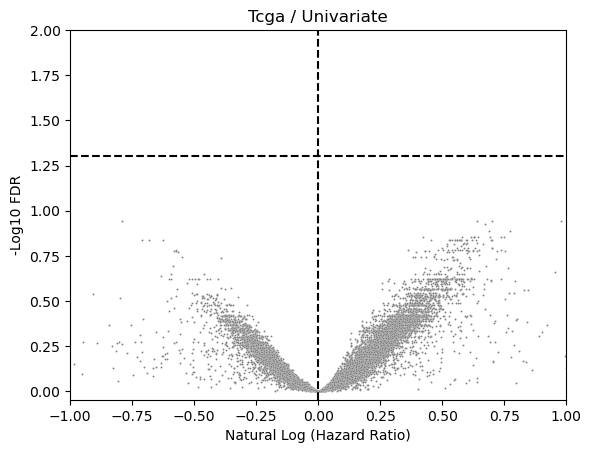

225  de genes


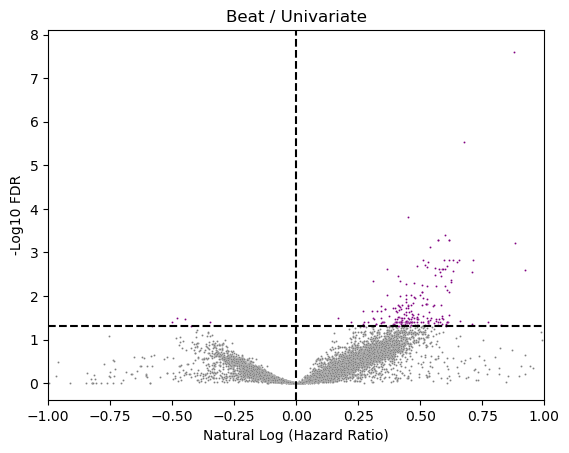

217  de genes


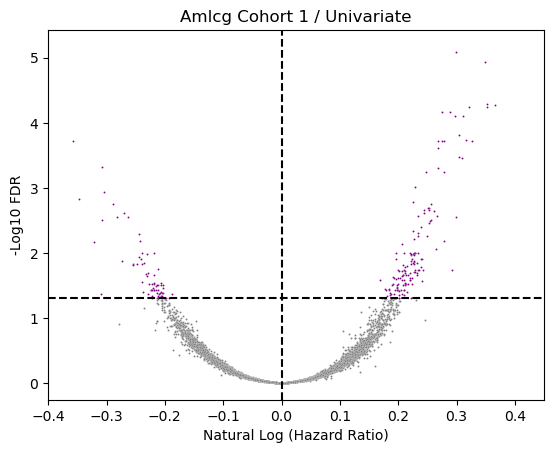

91  de genes


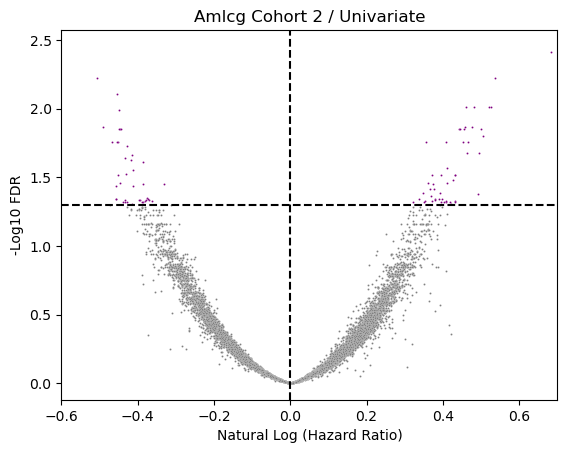

In [63]:
cohort_keys = ['TCGA / Univariate','Beat / Univariate','AMLCG Cohort 1 / Univariate','AMLCG Cohort 2 / Univariate']
for cohort in cohort_keys:
    df = cox_ph_fit_dict[cohort]['combined_results_df(single-index)(fdr_corrected_all_genes)'].copy()
    df['-log10pval_bh_corrected'] = df['pval_bh_corrected'].apply(lambda x: -np.log10(x+1e-300))
    max_y_value = df['-log10pval_bh_corrected'].max()
    df['hgnc'] = df.index
    df['hgnc'] = df['hgnc'].apply(lambda x: ensembl_to_hgnc_non_unique_dict.get(x,x))
    
    df_pos = df.copy()
    df_pos = df_pos[(df_pos['coef']>0)&(df_pos['pval_bh_corrected']<.05)]
    df_neg = df.copy()
    df_neg = df_neg[(df_neg['coef']<0)&(df_neg['pval_bh_corrected']<.05)]
    df_not_de = df.copy()
    df_not_de = df_not_de[(df_not_de['coef']==.7)|~(df_not_de['pval_bh_corrected']<.05)]
    df_de = df.copy()
    df_de = df_de[(df_de['coef'].abs()>0)&(df_de['pval_bh_corrected']<.05)]
    print(len(df_de),' de genes')

    top_pos = df_pos.sort_values(by=['pval_bh_corrected', 'coef'], ascending=[True, False]).head(15)
    top_neg = df_neg.sort_values(by=['pval_bh_corrected', 'coef'], ascending=[True, True]).head(15)
    
    s=2 #point size
    
    sns.scatterplot(df_pos,x='coef',y='-log10pval_bh_corrected',s=s,color = 'purple', rasterized = True)
    sns.scatterplot(df_neg,x='coef',y='-log10pval_bh_corrected',s=s,color = 'purple',rasterized = True)
    sns.scatterplot(df_not_de,x='coef',y='-log10pval_bh_corrected',s=s,color = 'grey',rasterized = True)
    plt.xlim(-1,1)
    plt.ylim(None, max_y_value+(max_y_value/15))
    plt.title(cohort.split('(')[0].title())

    #makes the lack of DE easier to see for reader
    if 'TCGA' in cohort:
        plt.ylim(None,2)
    
    if 'AMLCG Cohort 1' in cohort:
        plt.xlim(-.4,.45)
    if 'AMLCG Cohort 2' in cohort:
        plt.xlim(-.6,.7)
    

    
    # Remove axis labels
    plt.xlabel('Natural Log (Hazard Ratio)')
    plt.ylabel('-Log10 FDR')


    plt.axhline(1.3010,linestyle='--',color='black')
    plt.axvline(0,linestyle='--',color='black')

    # Show the plot
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()

9851  de genes


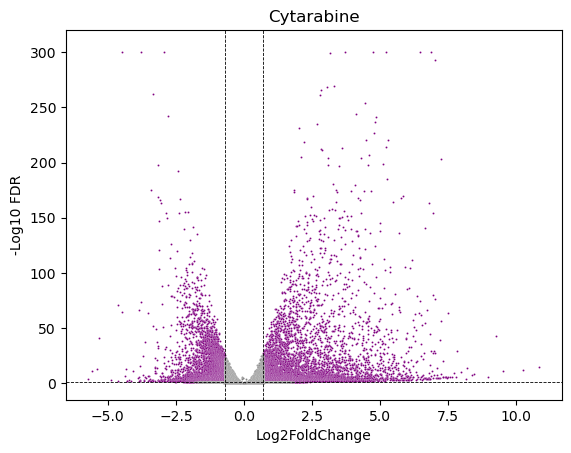

1510  de genes


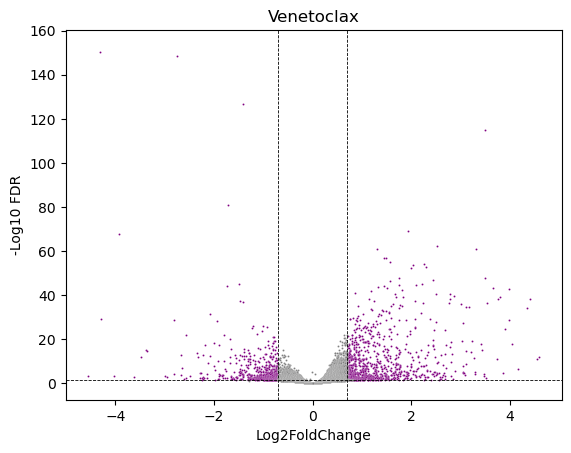

1182  de genes


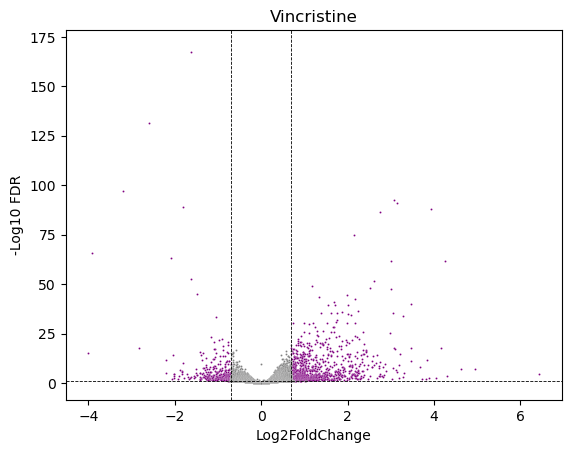

In [64]:
for drug in ['cytarabine','venetoclax','vincristine']:
    df = bulk_de_tables_dict[drug].copy()
    df['-log10pval_bh_corrected'] = df['pval_bh_corrected'].apply(lambda x: -np.log10(x+1e-300))
    df['hgnc'] = df.index
    df['hgnc'] = df['hgnc'].apply(lambda x: ensembl_to_hgnc_non_unique_dict.get(x,x))
    max_y_value = df['-log10pval_bh_corrected'].max()

    df_pos = df.copy()
    df_pos = df_pos[(df_pos['l2fc']>.7)&(df_pos['pval_bh_corrected']<.05)]
    df_neg = df.copy()
    df_neg = df_neg[(df_neg['l2fc']<-.7)&(df_neg['pval_bh_corrected']<.05)]
    df_not_de = df.copy()
    df_not_de = df_not_de[(df_not_de['l2fc'].abs()<.7)|~(df_not_de['pval_bh_corrected']<.05)]
    df_de = df.copy()
    df_de = df_de[(df_de['l2fc'].abs()>.7)&(df_de['pval_bh_corrected']<.05)]
    print(len(df_de),' de genes')
    
    top_pos = df_pos.sort_values(by=['pval_bh_corrected', 'l2fc'], ascending=[True, False]).head(15)
    top_neg = df_neg.sort_values(by=['pval_bh_corrected', 'l2fc'], ascending=[True, True]).head(15)
    
    s=2 #point size
    
    sns.scatterplot(df_pos,x='l2fc',y='-log10pval_bh_corrected',s=s,color = 'purple',rasterized = True)
    sns.scatterplot(df_neg,x='l2fc',y='-log10pval_bh_corrected',s=s,color = 'purple',rasterized = True)
    sns.scatterplot(df_not_de,x='l2fc',y='-log10pval_bh_corrected',s=s,color = 'grey',rasterized = True)
    plt.title(drug.title())


    # Remove axis labels
    plt.xlabel('Log2FoldChange')
    plt.ylabel('-Log10 FDR')
    # Remove the box (spines)
    
    # Set axis limits if needed
    #plt.xlim(-2,2)
    plt.ylim(None, max_y_value+(max_y_value/15))
    plt.axhline(1.3010,linestyle='--',color='black',linewidth=.6)
    plt.axvline(.7,linestyle='--',color='black',linewidth=.6)
    plt.axvline(-.7,linestyle='--',color='black',linewidth=.6)
    # Show the plot
    plt.savefig(r'..\results\figure_outputs_poor_prog_upreg' + '\\' + str(time.time()) + '_figure.svg', format="svg")
    plt.show()